In [1]:
import os
import json

import matplotlib.pyplot as plt

In [2]:
# T20

# TODO: при увеличении числа тем когерентность Ньюмана увеличилась, а интратекст -- уменьшилась

DATASET_BAD_COHERENCE_THRESHOLDS_20 = {
    'postnauka': 0.5568860704432789,  # 1.7938763485672071 (intra 10%) 1.890894097939173 (intra 20%)
    '20newsgroups': 0.8497888357888863,  # 1.953001866389115 (intra 10%)
    'ruwikigood': 0.4889507901131518,
    'rtlwikiperson': 0.44461773745585326,
    'mkb10': 0.48898656658973,  # 1.7434408568528794 (intra 10%) 1.8676456834336237 (intra 20%)
}
DATASET_GOOD_COHERENCE_THRESHOLDS_20 = {
    'postnauka': 0.9154723765333351,  # 2.3394925682940233 (intra 70%) 2.5432101128006273 (intra 80%)
    '20newsgroups': 1.6095355359760972,  # 2.7242325146624466 (intra 70%)
    'ruwikigood': 0.8632394176407866,
    'rtlwikiperson': 0.7010941774163096,
    'mkb10': 0.7372573006249383,  # 2.344754594835432 (intra 70%) 2.5358203425535235 (intra 80%)
}


# T50

DATASET_BAD_COHERENCE_THRESHOLDS_50 = {
    'postnauka': 0.6300154717967157,  # 1.2736409984877761 (intra 10%)  # TODO: значения уменьшились при увеличении числа тем
    '20newsgroups': 1.034617754777075,  # 1.3760632784442917 (intra 10%)
    'ruwikigood': 0.5677332839669632,
    'rtlwikiperson': 0.4818845486539586,
    'mkb10': 0.5504721115444576,  # 1.2499085596596853 (intra 70%)
}
DATASET_GOOD_COHERENCE_THRESHOLDS_50 = {
    'postnauka': 1.0703095408390997,  # 1.4869940008121474 (intra 70%)
    '20newsgroups': 1.8128360841394622,  # 1.7456368947464058 (intra 70%)
    'ruwikigood': 0.9918260892662304,
    'rtlwikiperson': 0.7938587462014927,
    'mkb10': 0.8997333820973618,  # 1.5041606723306686 (intra 70%)
}


DATASET_BAD_COHERENCE_THRESHOLDS = {
    20: DATASET_BAD_COHERENCE_THRESHOLDS_20,
    50: DATASET_BAD_COHERENCE_THRESHOLDS_50
}

DATASET_GOOD_COHERENCE_THRESHOLDS = {
    20: DATASET_GOOD_COHERENCE_THRESHOLDS_20,
    50: DATASET_GOOD_COHERENCE_THRESHOLDS_50
}





DATASET_BEST_ITER_TAUS = {
    'postnauka':     100000,
    '20newsgroups':  100000,
    'ruwikigood':    1000000,
    'rtlwikiperson': 1000000,
    'mkb10':         100000,
}
DATASET_BEST_ITER2_TAUS = {
    'postnauka':     100000000,
    '20newsgroups':  100000000,
    'ruwikigood':    10000000000,
    'rtlwikiperson': 1000000000,
    'mkb10':         100000000,
}

In [3]:
! ls /data_mil/shared/CompressaAI/iterative/results/newman/results/

20newsgroups  mkb10  postnauka	rtlwikiperson  ruwikigood


In [4]:
! ls /data_mil/shared/CompressaAI/iterative/results/newman/results50/

20newsgroups  mkb10  postnauka	rtlwikiperson  ruwikigood


In [5]:
! ls /data_mil/shared/CompressaAI/iterative/results/newman/results/postnauka

ablation_study		      iterative_100000.json	 plsa.json
bertopic		      iterative_10000.json	 plsa_with_cohs.json
bertopic.json		      iterative2_100000000.json  sparse.json
decorrelation.json	      iterative2_10000000.json	 sparse_with_cohs.json
decorrelation_with_cohs.json  lda.json			 tless.json
_iterative_100000.json	      lda_with_cohs.json	 tless_with_cohs.json


In [6]:
! ls /data_mil/shared/CompressaAI/iterative/results/newman/results50/postnauka

ablation_study		      _iterative_100000.json	  lda_with_cohs.json
bertopic		      iterative_100000.json	  plsa.json
bertopic.json		      _iterative2_100000000	  plsa_with_cohs.json
decorrelation.json	      iterative2_100000000	  sparse.json
decorrelation_with_cohs.json  _iterative2_100000000.json  sparse_with_cohs.json
_iterative_100000	      iterative2_100000000.json   tless.json
iterative_100000	      lda.json			  tless_with_cohs.json


In [7]:
! ls /data_mil/shared/CompressaAI/iterative/results/newman/results50/postnauka | grep iterative | grep json

_iterative_100000.json
iterative_100000.json
_iterative2_100000000.json
iterative2_100000000.json


In [8]:
! ls /data_mil/shared/CompressaAI/iterative/results/newman/results50/20newsgroups | grep iterative | grep json

iterative_100000.json
iterative2_100000000.json


In [9]:
! ls /data_mil/shared/CompressaAI/iterative/results/newman/results50/ruwikigood | grep iterative | grep json

iterative_1000000.json
iterative2_10000000000.json


In [10]:
! ls /data_mil/shared/CompressaAI/iterative/results/newman/results50/rtlwikiperson | grep iterative | grep json

iterative_1000000.json
iterative2_1000000000.json


In [13]:
! ls /data_mil/shared/CompressaAI/iterative/results/newman/results50/mkb10 | grep iterative | grep json

iterative_100000.json
iterative2_100000000.json


In [14]:
! ls /data_mil/shared/CompressaAI/iterative/results/newman/results/postnauka | grep iterative | grep json

_iterative_100000.json
iterative_100000.json
iterative_10000.json
iterative2_100000000.json
iterative2_10000000.json


In [15]:
! ls /data_mil/shared/CompressaAI/iterative/results/newman/results/20newsgroups | grep iterative | grep json

iterative_1000000.json
iterative_100000.json
iterative_1000.json
iterative_100.json
iterative2_1000000000.json
iterative2_100000000.json
iterative2_10000000.json
iterative2_1000000.json
iterative2_100000.json


In [16]:
! ls /data_mil/shared/CompressaAI/iterative/results/newman/results50/ruwikigood | grep iterative | grep json

iterative_1000000.json
iterative2_10000000000.json


In [17]:
! ls /data_mil/shared/CompressaAI/iterative/results/newman/results/rtlwikiperson | grep iterative | grep json

iterative_10000000_unfinished.json
iterative_1000000.json
iterative_100000.json
iterative2_10000000000.json
iterative2_1000000000.json
iterative2_100000000.json


In [18]:
! ls /data_mil/shared/CompressaAI/iterative/results/newman/results/mkb10 | grep iterative | grep json

iterative_1000000.json
iterative_100000.json
iterative2_1000000000.json
iterative2_100000000.json


In [19]:
! ls /data_mil/shared/CompressaAI/iterative/results/newman/results/postnauka | grep iterative | grep json

_iterative_100000.json
iterative_100000.json
iterative_10000.json
iterative2_100000000.json
iterative2_10000000.json


In [11]:
! ls | grep '__internals'

20_Newsgroups__internals
Good_RU_Wiki__internals
MKB_10__internals
Post_Science__internals
RTL_Wiki_Person__internals


In [12]:
! ls Post_Science__internals

batches    _result  _result2  result2_50  result_unfiltered_dict
dict.dict  result   result2   result_50   vw.txt


In [13]:
! ls Post_Science__internals/result/search_result__0.json

Post_Science__internals/result/search_result__0.json


In [14]:
! cat Post_Science__internals/result/search_result__0.json

{"optimum": 8, "optimum_std": 5.0, "bank_scores": [{"perplexity_score": 27600.54296875, "coherence_20": 1.1177666958123678, "diversity_euclidean": 0.04971374671297815, "diversity_jensenshannon": 0.5967539527734701, "diversity_hellinger": 0.6922578888429283, "diversity_cosine": 0.746649317119927, "perplexity": 27600.54296875, "ppl_fair": 27600.54296875, "ppl_cheatty": 4970.97119140625}, {"perplexity_score": 12274.9267578125, "coherence_20": 1.0511303118773, "diversity_euclidean": 0.045677036265274085, "diversity_jensenshannon": 0.6265346154678154, "diversity_hellinger": 0.7277956636084046, "diversity_cosine": 0.763120532644456, "perplexity": 12274.9267578125, "ppl_fair": 12274.9267578125, "ppl_cheatty": 4744.744140625}, {"perplexity_score": 10446.2529296875, "coherence_20": 0.9918173215187528, "diversity_euclidean": 0.046234306391336584, "diversity_jensenshannon": 0.6043805692629273, "diversity_hellinger": 0.699363325018506, "diversity_cosine": 0.7323395858081453, "perplexity": 10446.25

In [25]:
! ls /data_mil/shared/CompressaAI/iterative/results/newman/results/postnauka/ablation_study

iterative_100000_0-0-1.json  iterative2_100000000_0-0-1.json
iterative_100000_0-1-0.json  iterative2_100000000_0-1-0.json
iterative_100000_0-1-1.json  iterative2_100000000_0-1-1.json
iterative_100000_1-0-0.json  iterative2_100000000_1-0-0.json
iterative_100000_1-0-1.json  iterative2_100000000_1-0-1.json
iterative_100000_1-1-0.json  iterative2_100000000_1-1-0.json


In [15]:
_topic_bank_results = json.loads(
    open('Post_Science__internals/result/search_result__0.json').read()
)

In [16]:
_topic_bank_results.keys()

dict_keys(['optimum', 'optimum_std', 'bank_scores', 'bank_topic_scores', 'model_scores', 'model_topic_scores', 'num_bank_topics', 'num_model_topics'])

In [17]:
_topic_bank_results['bank_scores'][0]

{'perplexity_score': 27600.54296875,
 'coherence_20': 1.1177666958123678,
 'diversity_euclidean': 0.04971374671297815,
 'diversity_jensenshannon': 0.5967539527734701,
 'diversity_hellinger': 0.6922578888429283,
 'diversity_cosine': 0.746649317119927,
 'perplexity': 27600.54296875,
 'ppl_fair': 27600.54296875,
 'ppl_cheatty': 4970.97119140625}

In [18]:
_topic_bank_results['bank_topic_scores'][5]

[{'kernel_size': 2856,
  'coherence_20': 1.1812929265405114,
  'distance_to_nearest': 0.79025919077267},
 {'kernel_size': 3455,
  'coherence_20': 0.9178575440071646,
  'distance_to_nearest': 0.8382437670066345},
 {'kernel_size': 2425,
  'coherence_20': 0.9409436630681554,
  'distance_to_nearest': 0.6617147426494687},
 {'kernel_size': 2598,
  'coherence_20': 0.9271751524591798,
  'distance_to_nearest': 0.7094405645172381},
 {'kernel_size': 3172,
  'coherence_20': 0.8813308166660884,
  'distance_to_nearest': 0.7961549458942572},
 {'kernel_size': 3092,
  'coherence_20': 0.8584457956942841,
  'distance_to_nearest': 0.7939027411916018}]

In [19]:
_topic_bank_results['num_bank_topics'][5]

6

In [20]:
_topic_bank_results['num_bank_topics']

[2, 3, 4, 4, 4, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 8, 8, 8]

In [21]:
DATASET_INTERNALS = {
    'postnauka':     'Post_Science__internals',
    '20newsgroups':  '20_Newsgroups__internals',
    'ruwikigood':    'Good_RU_Wiki__internals',
    'rtlwikiperson': 'RTL_Wiki_Person__internals',
    'mkb10':         'MKB_10__internals',
}

## Results

```
RESULTS:
    20:
        dataset:
            model:
                best_iter
                iters:
                    0:
                        ppl
                        coh
                        div
                        num_good
                        percent_good
                        num_bad
                        num_not_good
```

In [22]:
! ls /data_mil/shared/CompressaAI/iterative/results/newman/results50/postnauka | grep json

bertopic.json
decorrelation.json
decorrelation_with_cohs.json
_iterative_100000.json
iterative_100000.json
_iterative2_100000000.json
iterative2_100000000.json
lda.json
lda_with_cohs.json
plsa.json
plsa_with_cohs.json
sparse.json
sparse_with_cohs.json
tless.json
tless_with_cohs.json


In [23]:
DATASETS = ['postnauka', '20newsgroups', 'ruwikigood', 'rtlwikiperson', 'mkb10']
MODELS = [
    'plsa', 'sparse', 'decorrelation', 'tless', 'lda',
    'iterative', 'iterative2',
    'topic_bank', 'topic_bank2',
    'bertopic',
]

In [24]:
NUM_TOPICS = [20, 50]
RESULTS = dict()

In [25]:
RESULTS_FOLDER_PREFIX = 'results'

In [26]:
# Load

for num_topics in NUM_TOPICS:
    RESULTS[num_topics] = dict()

    if num_topics == 20:
        results_folder = RESULTS_FOLDER_PREFIX
    else:
        results_folder = f'{RESULTS_FOLDER_PREFIX}{num_topics}'

    results_folder = f'/data_mil/shared/CompressaAI/iterative/results/newman/{results_folder}'

    for dataset in DATASETS:
        RESULTS[num_topics][dataset] = dict()
        dataset_folder = os.path.join(results_folder, dataset)

        for model in MODELS:
            RESULTS[num_topics][dataset][model] = dict()

            if model == 'iterative':
                tau = DATASET_BEST_ITER_TAUS[dataset]
                model_file_name = f'{model}_{tau}.json'
            elif model == 'iterative2':
                tau = DATASET_BEST_ITER2_TAUS[dataset]
                model_file_name = f'{model}_{tau}.json'
            elif model == 'bertopic':
                model_file_name = f'{model}.json'
            elif 'topic_bank' in model:
                internals_folder = DATASET_INTERNALS[dataset]
                suffix1 = model.split('topic_bank')[-1]
                suffix2 = '' if num_topics == 20 else f'_{num_topics}'
                bank_folder = os.path.join(internals_folder, 'result' + suffix1 + suffix2)
                bank_file_path = os.path.join(bank_folder, 'search_result__0.json')
            else:
                # model_file_name = f'{model}.json'
                
                _model_file_name = f'{model}_with_cohs.json'
                _model_file_path = os.path.join(dataset_folder, _model_file_name)
                
                # if os.path.isfile(_model_file_path):
                #     print(f'with cohs here: {_model_file_path}')

                assert os.path.isfile(_model_file_path)

                model_file_name = _model_file_name

            if 'topic_bank' in model:
                model_file_path = bank_file_path
            else:
                model_file_path = os.path.join(dataset_folder, model_file_name)
            
            assert os.path.isfile(model_file_path), (model, model_file_path)

            model_results = json.loads(
                open(model_file_path).read()
            )

            if 'topic_bank' in model:
                topic_coherences = list()

                for j, bts in enumerate(model_results['bank_topic_scores']):
                    cur_topic_coherences = dict()

                    for i, t in enumerate(bts):
                        cur_topic_coherences[str(i)] = t['coherence_20']

                    assert model_results['num_bank_topics'][j] == len(cur_topic_coherences)

                    topic_coherences.append(cur_topic_coherences)

                # _model_results = list(zip(
                #     'scores': model_results['bank_scores'],
                #     'topic_coherences': topic_coherences,
                #     'num_topics': model_results['num_bank_topics']
                # ))

                _model_results = list()

                for i in range(len(model_results['bank_scores'])):
                    _model_results.append({
                        'scores': model_results['bank_scores'][i],
                        'topic_coherences': topic_coherences[i],
                        'num_topics': model_results['num_bank_topics'][i],
                    })

                model_results = _model_results

            RESULTS[num_topics][dataset][model]['iters'] = model_results

In [27]:
RESULTS.keys()

dict_keys([20, 50])

In [28]:
RESULTS[20].keys()

dict_keys(['postnauka', '20newsgroups', 'ruwikigood', 'rtlwikiperson', 'mkb10'])

In [29]:
RESULTS[20]['postnauka'].keys()

dict_keys(['plsa', 'sparse', 'decorrelation', 'tless', 'lda', 'iterative', 'iterative2', 'topic_bank', 'topic_bank2', 'bertopic'])

In [30]:
RESULTS[20]['postnauka']['plsa'].keys()

dict_keys(['iters'])

In [31]:
RESULTS[20]['postnauka']['plsa']['iters'][0]

{'scores': {'perplexity': 2983.59326171875,
  'coherence_20': 0.7317631980109902,
  'diversity_euclidean': 0.046569950337302046,
  'diversity_jensenshannon': 0.5982341406218086,
  'diversity_hellinger': 0.6850917967989407,
  'diversity_cosine': 0.7077267838062731},
 'topic_coherences': {'0': 0.47477441486776983,
  '1': 0.7118635781130683,
  '2': 0.6385750582879668,
  '3': 0.8588277998967593,
  '4': 0.9654644411924509,
  '5': 0.8495723280901767,
  '6': 0.6893087965800643,
  '7': 0.5284507369116072,
  '8': 0.7653851628128981,
  '9': 0.922791744160493,
  '10': 1.054240465084224,
  '11': 0.4860267452007648,
  '12': 0.6992695861295757,
  '13': 0.5400582500678222,
  '14': 0.45272666279209955,
  '15': 0.8221831016907979,
  '16': 1.1812929265405114,
  '17': 0.6510241808664233,
  '18': 0.7806403172775794,
  '19': 0.5627876636567517}}

In [32]:
RESULTS[20]['postnauka']['iterative']['iters'][0]

{'scores': {'perplexity': 3354.180419921875,
  'coherence_20': 0.8420570833071205,
  'diversity_euclidean': 0.06129860264725082,
  'diversity_jensenshannon': 0.6645977672745326,
  'diversity_hellinger': 0.7761088194026712,
  'diversity_cosine': 0.8047550714089029},
 'topic_coherences': {'0': 0.46009400566644193,
  '1': 0.7254412703733862,
  '2': 1.302009849349046,
  '3': 0.8628769522261815,
  '4': 1.0884573939452766,
  '5': 1.0168754020127426,
  '6': 0.6980303292285863,
  '7': 0.6043601813882423,
  '8': 0.7483147931845104,
  '9': 0.8593462866245763,
  '10': 1.1562135471080357,
  '11': 0.5766904713676815,
  '12': 0.855558785556189,
  '13': 0.535900886907171,
  '14': 0.6612973036352092,
  '15': 0.8817214328684023,
  '16': 1.2898827651571152,
  '17': 0.7824472372398469,
  '18': 0.9053072935924146,
  '19': 0.8303154787113531},
 'num_topics': {'good': 5, 'bad': 2, 'not_good': 15, 'total_bad': 2}}

In [33]:
RESULTS[20]['postnauka']['topic_bank']['iters'][0]

{'scores': {'perplexity_score': 27600.54296875,
  'coherence_20': 1.1177666958123678,
  'diversity_euclidean': 0.04971374671297815,
  'diversity_jensenshannon': 0.5967539527734701,
  'diversity_hellinger': 0.6922578888429283,
  'diversity_cosine': 0.746649317119927,
  'perplexity': 27600.54296875,
  'ppl_fair': 27600.54296875,
  'ppl_cheatty': 4970.97119140625},
 'topic_coherences': {'0': 1.054240465084224, '1': 1.1812929265405114},
 'num_topics': 2}

In [34]:
RESULTS[20]['postnauka']['topic_bank2']['iters'][0]

{'scores': {'perplexity_score': 22275.740234375,
  'coherence_20': 1.1706877915144434,
  'diversity_euclidean': 0.06451603629970425,
  'diversity_jensenshannon': 0.6715327678443475,
  'diversity_hellinger': 0.7877355716829133,
  'diversity_cosine': 0.8494056234565296,
  'perplexity': 22275.740234375,
  'ppl_fair': 22275.740234375,
  'ppl_cheatty': 4683.75537109375},
 'topic_coherences': {'0': 1.302009849349046,
  '1': 1.0884573939452766,
  '2': 1.0168754020127426,
  '3': 1.1562135471080357,
  '4': 1.2898827651571152},
 'num_topics': 5}

In [35]:
RESULTS[20]['postnauka']['bertopic']['iters'][0]

{'scores': {'perplexity': 5831.353515625,
  'coherence_20': 1.1895922630550457,
  'diversity_euclidean': 0.05643315561647891,
  'diversity_jensenshannon': 0.6586868390442192,
  'diversity_hellinger': 0.7723483311822211,
  'diversity_cosine': 0.7665362134060419,
  'fair_ppl_free': 4104.3720703125,
  'fair_ppl_fix': 5732.21533203125,
  'unfair_ppl_banklike': 5831.353515625},
 'topic_coherences': {'0': 0.2569302406409139,
  '1': 0.3773557156995919,
  '2': 0.4151826271267152,
  '3': 0.869048069861531,
  '4': 0.34707651257947725,
  '5': 1.1344835564004891,
  '6': 0.7381468059844702,
  '7': 1.868370712245547,
  '8': 2.2936935649937964,
  '9': 0.8091636348624217,
  '10': 2.7444844015225542,
  '11': 1.5617199764971843,
  '12': 1.7821392306432786,
  '13': 1.0615351667879558,
  '14': 0.9731558747867508,
  '15': 0.9624011546092153,
  '16': 1.27555822215827,
  '17': 1.7640648985938334,
  '18': 1.0001747009957196,
  '19': 1.5571601941111977},
 'stats': {'num_topics': 21,
  'num_common_words': 82061

In [36]:
def get_best_iter(num_topics, dataset, model):
    model_results = RESULTS[num_topics][dataset][model]
    model_iters = model_results['iters']
    good_coherence_threshold = DATASET_GOOD_COHERENCE_THRESHOLDS[num_topics][dataset]
    # bad_coherence_threshold = DATASET_BAD_COHERENCE_THRESHOLDS[num_topics][dataset]
    
    best_iter = None
    best_num_good_topics = None
    best_average_coherence = None

    for i, iter in enumerate(model_iters):
        cur_num_good_topics = sum([
            1 if c >= good_coherence_threshold else 0
            for _, c in iter['topic_coherences'].items()
        ])

        if 'iterative' in model:
            assert cur_num_good_topics == iter['num_topics']['good'], (cur_num_good_topics, model_results['num_topics']['good'])

        cur_average_coherence = iter['scores']['coherence_20']

        if (best_iter is None) or (cur_num_good_topics > best_num_good_topics) or (
                cur_num_good_topics == best_num_good_topics and cur_average_coherence > best_average_coherence):
            best_iter = i
            best_num_good_topics = cur_num_good_topics
            best_average_coherence = cur_average_coherence

    return best_iter

In [37]:
get_best_iter(20, 'postnauka', 'plsa')

10

In [38]:
def get_best_iter_fair_itar(num_topics, dataset, model):
    if 'iterative' not in model and 'topic_bank' not in model:
        return get_best_iter(num_topics, dataset, model)

    model_results = RESULTS[num_topics][dataset][model]
    model_iters = model_results['iters']
    good_coherence_threshold = DATASET_GOOD_COHERENCE_THRESHOLDS[num_topics][dataset]
    # bad_coherence_threshold = DATASET_BAD_COHERENCE_THRESHOLDS[num_topics][dataset]
    
    best_iter = None
    best_num_good_topics = None
    best_average_coherence = None

    for i, iter in enumerate(model_iters):
        cur_num_good_topics = sum([
            1 if c >= good_coherence_threshold else 0
            for _, c in iter['topic_coherences'].items()
        ])

        if 'iterative' in model:
            assert cur_num_good_topics == iter['num_topics']['good'], (cur_num_good_topics, model_results['num_topics']['good'])

        cur_average_coherence = iter['scores']['coherence_20']

        # if (best_iter is None) or (cur_num_good_topics > best_num_good_topics) or (
        #         cur_num_good_topics == best_num_good_topics and cur_average_coherence > best_average_coherence):
        best_iter = i
        best_num_good_topics = cur_num_good_topics
        best_average_coherence = cur_average_coherence

    assert best_iter == len(model_iters) - 1

    return best_iter

In [39]:
def get_perplexities(num_topics, dataset, model, key='perplexity'):
    # TODO: DRY (get coherences)
    model_results = RESULTS[num_topics][dataset][model]
    model_iters = model_results['iters']

    iters = []
    perplexities = []

    for i, iter in enumerate(model_iters):
        cur_perplexity = iter['scores'][key]
        perplexities.append(cur_perplexity)
        iters.append(i)

    return iters, perplexities


def get_coherences(num_topics, dataset, model):
    model_results = RESULTS[num_topics][dataset][model]
    model_iters = model_results['iters']

    iters = []
    coherences = []

    for i, iter in enumerate(model_iters):
        cur_average_coherence = iter['scores']['coherence_20']
        coherences.append(cur_average_coherence)
        iters.append(i)

    return iters, coherences


def get_nums_good_topics(num_topics, dataset, model):
    model_results = RESULTS[num_topics][dataset][model]
    model_iters = model_results['iters']
    good_coherence_threshold = DATASET_GOOD_COHERENCE_THRESHOLDS[num_topics][dataset]

    iters = []
    nums_good_topics = []

    for i, iter in enumerate(model_iters):
        cur_num_good_topics = sum([
            1 if c >= good_coherence_threshold else 0
            for _, c in iter['topic_coherences'].items()
        ])

        if 'iterative' in model:
            assert cur_num_good_topics == iter['num_topics']['good'], (cur_num_good_topics, model_results['num_topics']['good'])

        nums_good_topics.append(cur_num_good_topics)
        iters.append(i)

    return iters, nums_good_topics


def get_num_good_topics_percents(num_topics, dataset, model):
    iters, nums_good_topics = get_nums_good_topics(num_topics, dataset, model)

    return iters, [
        n / num_topics * 100 for n in nums_good_topics
    ]


def get_nums_bad_topics(num_topics, dataset, model):
    # TODO: DRY (get nums good)
    model_results = RESULTS[num_topics][dataset][model]
    model_iters = model_results['iters']
    bad_coherence_threshold = DATASET_BAD_COHERENCE_THRESHOLDS[num_topics][dataset]

    iters = []
    nums_bad_topics = []

    for i, iter in enumerate(model_iters):
        cur_num_bad_topics = sum([
            1 if c <= bad_coherence_threshold else 0
            for _, c in iter['topic_coherences'].items()
        ])

        if 'iterative' in model:
            assert cur_num_bad_topics == iter['num_topics']['bad'], (cur_num_good_topics, model_results['num_topics']['good'])

        nums_bad_topics.append(cur_num_bad_topics)
        iters.append(i)

    return iters, nums_bad_topics


def get_num_bad_topics_percents(num_topics, dataset, model):
    iters, nums_bad_topics = get_nums_bad_topics(num_topics, dataset, model)

    return iters, [
        n / num_topics * 100 for n in nums_bad_topics
    ]


def get_diversities_js(num_topics, dataset, model):
    # TODO: DRY (get coherences)
    model_results = RESULTS[num_topics][dataset][model]
    model_iters = model_results['iters']

    iters = []
    diversities = []

    for i, iter in enumerate(model_iters):
        cur_diversity = iter['scores']['diversity_jensenshannon']
        diversities.append(cur_diversity)
        iters.append(i)

    return iters, diversities


def get_diversities_cos(num_topics, dataset, model):
    # TODO: DRY (get coherences)
    model_results = RESULTS[num_topics][dataset][model]
    model_iters = model_results['iters']

    iters = []
    diversities = []

    for i, iter in enumerate(model_iters):
        cur_diversity = iter['scores']['diversity_cosine']
        diversities.append(cur_diversity)
        iters.append(i)

    return iters, diversities

In [40]:
get_best_iter(20, 'postnauka', 'plsa')

10

In [41]:
get_perplexities(20, 'postnauka', 'plsa')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [2983.59326171875,
  2949.43017578125,
  2966.064697265625,
  2958.653076171875,
  2984.134521484375,
  3014.21142578125,
  2978.85107421875,
  2995.494873046875,
  2996.61376953125,
  2977.179443359375,
  2988.05126953125,
  2985.51416015625,
  2957.9091796875,
  2975.52978515625,
  2989.38525390625,
  2944.6376953125,
  2996.0478515625,
  2979.764404296875,
  2978.07080078125,
  2949.338623046875])

In [42]:
get_nums_good_topics(20, 'postnauka', 'plsa')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [4, 3, 2, 3, 2, 0, 3, 3, 2, 1, 4, 3, 3, 0, 1, 2, 4, 1, 2, 4])

In [43]:
get_coherences(20, 'postnauka', 'plsa')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [0.7317631980109902,
  0.7405018041851279,
  0.708181422304847,
  0.7090280938371003,
  0.6896293891663173,
  0.6878483762513145,
  0.7380256975624945,
  0.7137795547035889,
  0.6997682118085503,
  0.7055892225428471,
  0.7408603471731607,
  0.7157266801217581,
  0.7124563746195334,
  0.705308006454304,
  0.7062659845411456,
  0.7135984536694571,
  0.7190963298915024,
  0.6933119412582956,
  0.7165247621544193,
  0.7345596331642312])

In [44]:
get_perplexities(20, 'postnauka', 'plsa')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [2983.59326171875,
  2949.43017578125,
  2966.064697265625,
  2958.653076171875,
  2984.134521484375,
  3014.21142578125,
  2978.85107421875,
  2995.494873046875,
  2996.61376953125,
  2977.179443359375,
  2988.05126953125,
  2985.51416015625,
  2957.9091796875,
  2975.52978515625,
  2989.38525390625,
  2944.6376953125,
  2996.0478515625,
  2979.764404296875,
  2978.07080078125,
  2949.338623046875])

In [45]:
get_perplexities(20, 'postnauka', 'bertopic')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [5831.353515625,
  5685.1552734375,
  5974.0439453125,
  5621.34130859375,
  5668.0283203125,
  5910.8203125,
  5709.57763671875,
  5979.59033203125,
  5895.83251953125,
  5438.2412109375,
  6035.0,
  5820.611328125,
  5868.0888671875,
  5683.3359375,
  6060.69091796875,
  5864.00439453125,
  5917.9140625,
  5778.27587890625,
  5788.3251953125,
  5821.53173828125])

In [46]:
get_best_iter(20, 'postnauka', 'topic_bank')

16

In [47]:
get_perplexities(20, 'postnauka', 'topic_bank')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [27600.54296875,
  12274.9267578125,
  10446.2529296875,
  10446.2529296875,
  10446.2529296875,
  6843.10986328125,
  6843.10986328125,
  8327.701171875,
  8327.701171875,
  8327.701171875,
  8327.701171875,
  8327.701171875,
  6708.66259765625,
  6708.66259765625,
  6708.66259765625,
  6708.66259765625,
  6798.5283203125,
  6107.216796875,
  6107.216796875,
  6107.216796875])

In [48]:
get_coherences(20, 'postnauka', 'topic_bank')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [1.1177666958123678,
  1.0511303118773,
  0.9918173215187528,
  0.9918173215187528,
  0.9918173215187528,
  0.9511743164058972,
  0.9511743164058972,
  0.9582381512773772,
  0.9582381512773772,
  0.9582381512773772,
  0.9582381512773772,
  0.9582381512773772,
  0.9559598111518087,
  0.9559598111518087,
  0.9559598111518087,
  0.9559598111518087,
  0.9935164476710492,
  0.98081432765508,
  0.98081432765508,
  0.98081432765508])

In [49]:
get_nums_good_topics(20, 'postnauka', 'topic_bank')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [2, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 6, 6, 6, 6])

In [50]:
DATASETS

['postnauka', '20newsgroups', 'ruwikigood', 'rtlwikiperson', 'mkb10']

In [51]:
MODELS

['plsa',
 'sparse',
 'decorrelation',
 'tless',
 'lda',
 'iterative',
 'iterative2',
 'topic_bank',
 'topic_bank2',
 'bertopic']

In [52]:
[p for p in plt.rcParams if 'font' in p]

['font.cursive',
 'font.family',
 'font.fantasy',
 'font.monospace',
 'font.sans-serif',
 'font.serif',
 'font.size',
 'font.stretch',
 'font.style',
 'font.variant',
 'font.weight',
 'legend.fontsize',
 'legend.title_fontsize',
 'mathtext.fontset',
 'pdf.fonttype',
 'pdf.use14corefonts',
 'pgf.rcfonts',
 'ps.fonttype',
 'svg.fonttype']

In [53]:
plt.rcParams['font.size']

10.0

In [54]:
plt.rcParams['font.size'] = 18

In [55]:
FIGSIZE = (20, 10)
LINEWIDTH = 2
MARKERSIZE = 20

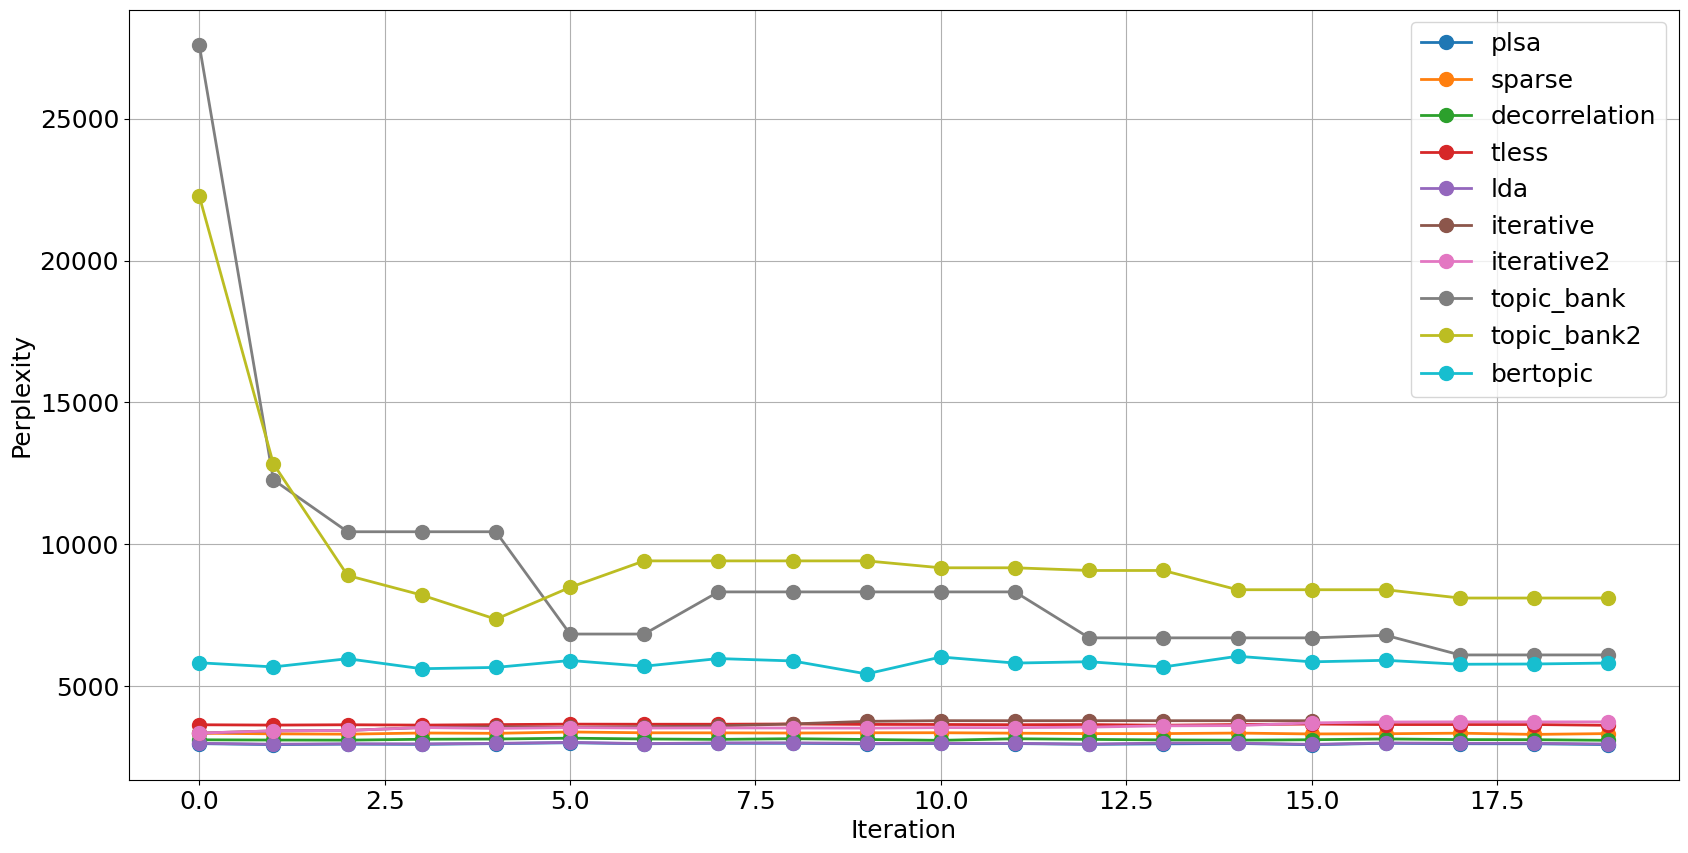

In [56]:
dataset = 'postnauka'
num_topics = 20
getter = get_perplexities


fig, ax = plt.subplots(figsize=FIGSIZE)


for model in MODELS:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=LINEWIDTH, marker='.', ms=MARKERSIZE, label=model)

plt.xlabel('Iteration')
plt.ylabel('Perplexity')

plt.grid()
plt.legend()

plt.show()

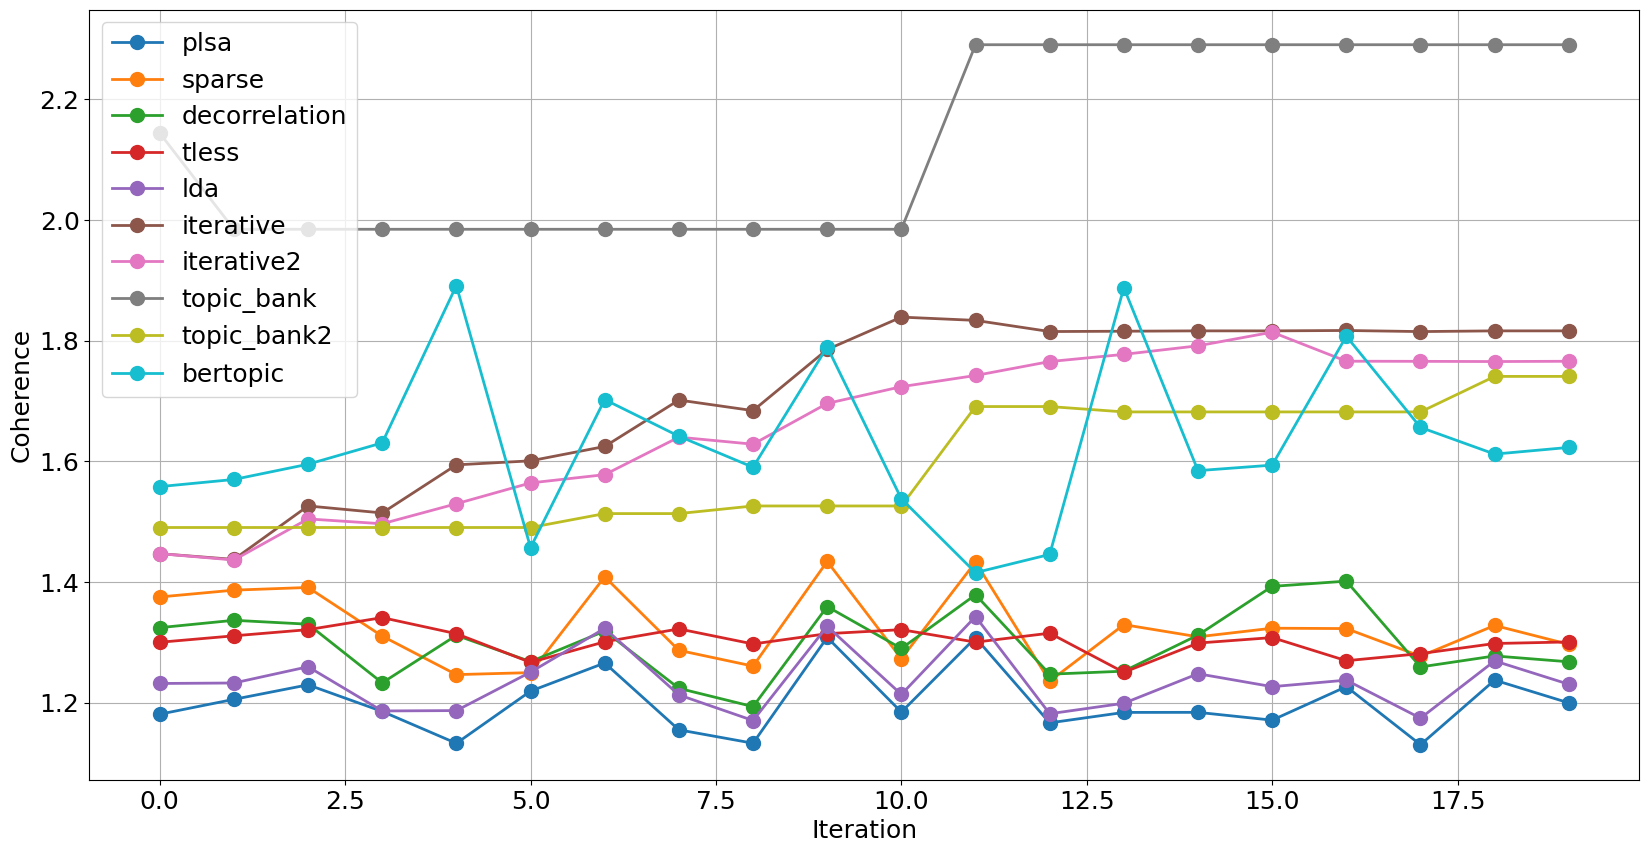

In [372]:
dataset = '20newsgroups'
num_topics = 20
getter = get_coherences
ylabel = 'Coherence'

fig, ax = plt.subplots(figsize=FIGSIZE)


for model in MODELS:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=LINEWIDTH, marker='.', ms=MARKERSIZE, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

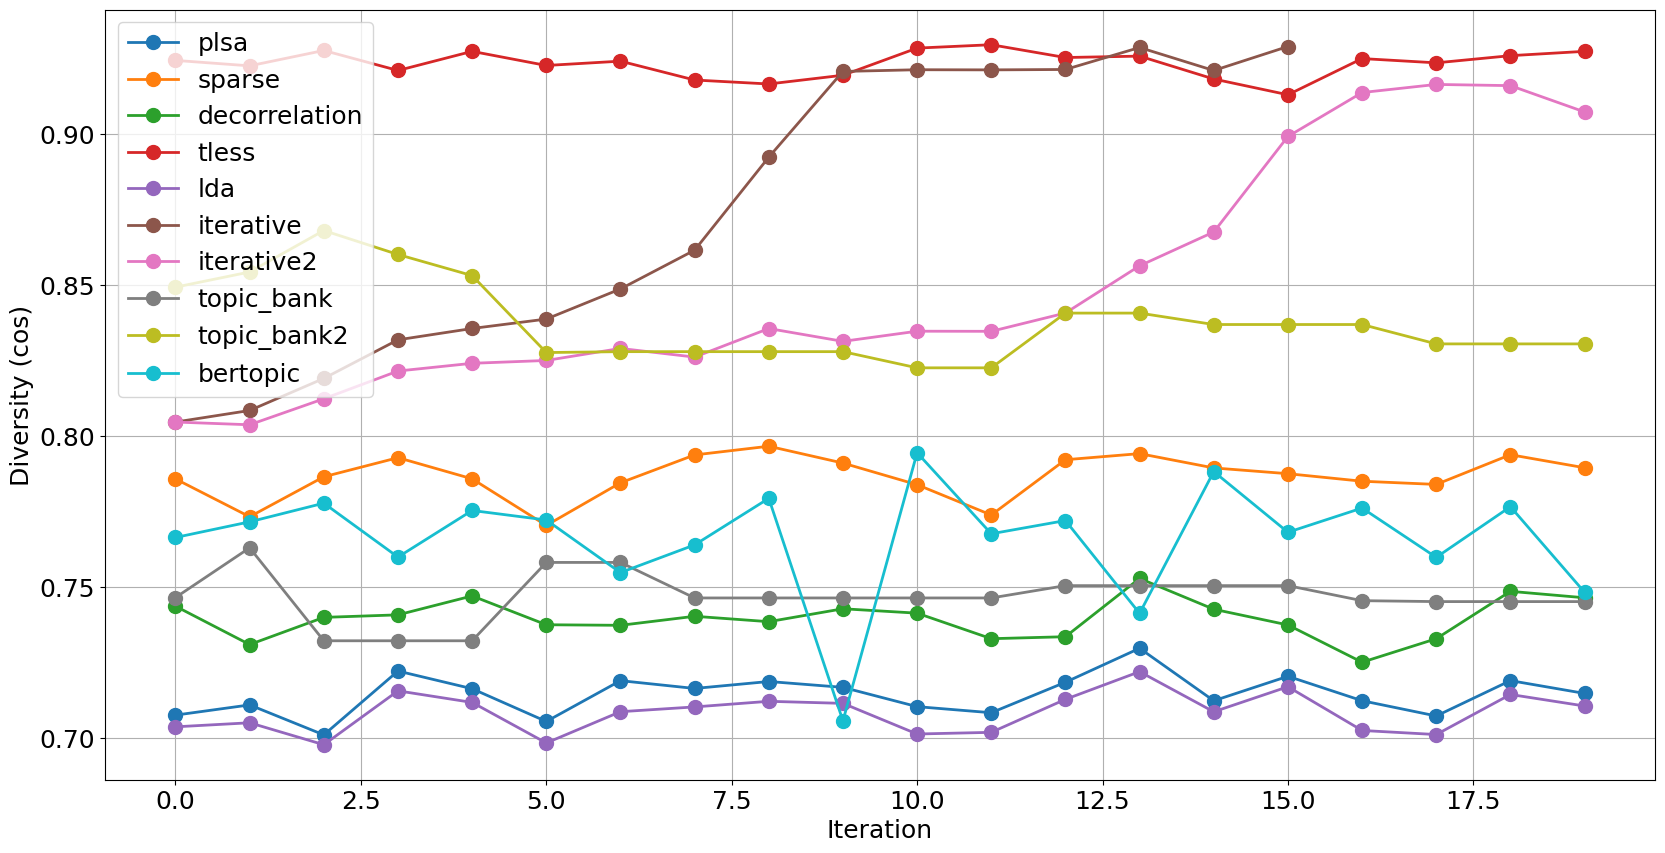

In [374]:
dataset = 'postnauka'
num_topics = 20
getter = get_diversities_cos
ylabel = 'Diversity (cos)'

fig, ax = plt.subplots(figsize=FIGSIZE)


for model in MODELS:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=LINEWIDTH, marker='.', ms=MARKERSIZE, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

In [68]:
MODELS_FOR_PLOTS = [
    'decorrelation', 'tless', 'lda', 'bertopic', 'topic_bank', 'topic_bank2', 'iterative', 'iterative2',
]
MODELS_FOR_PLOTS2 = [
    'decorrelation', 'tless', 'lda', 'bertopic', 'topic_bank2', 'iterative2',
]

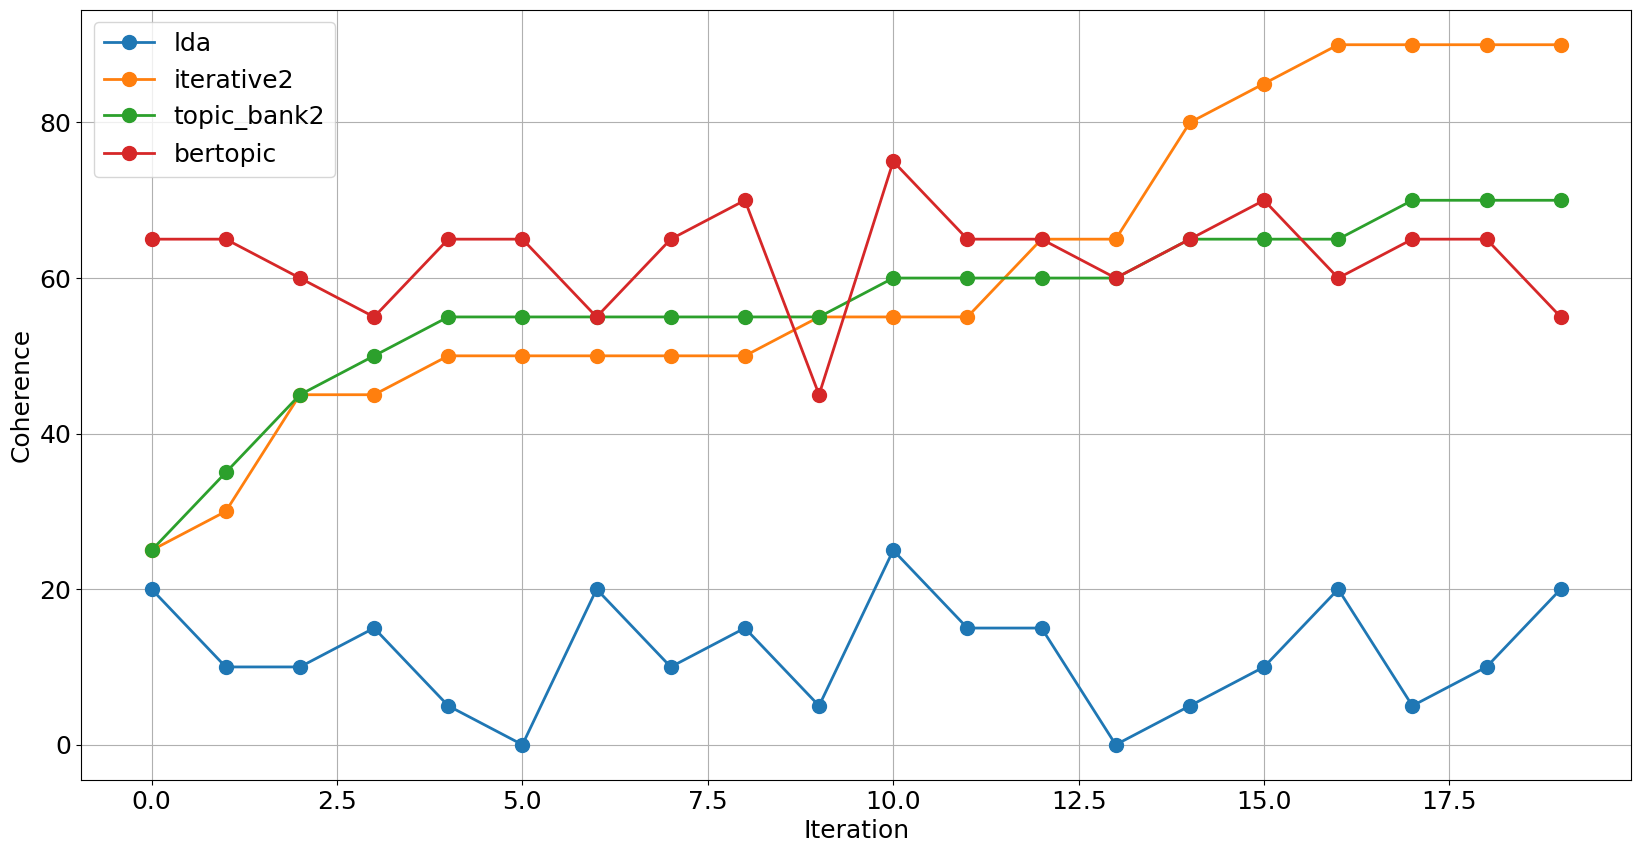

In [376]:
dataset = 'postnauka'
num_topics = 20
getter = get_num_good_topics_percents
ylabel = 'Coherence'

fig, ax = plt.subplots(figsize=(20, 10))


for model in ['lda', 'iterative2', 'topic_bank2', 'bertopic']:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

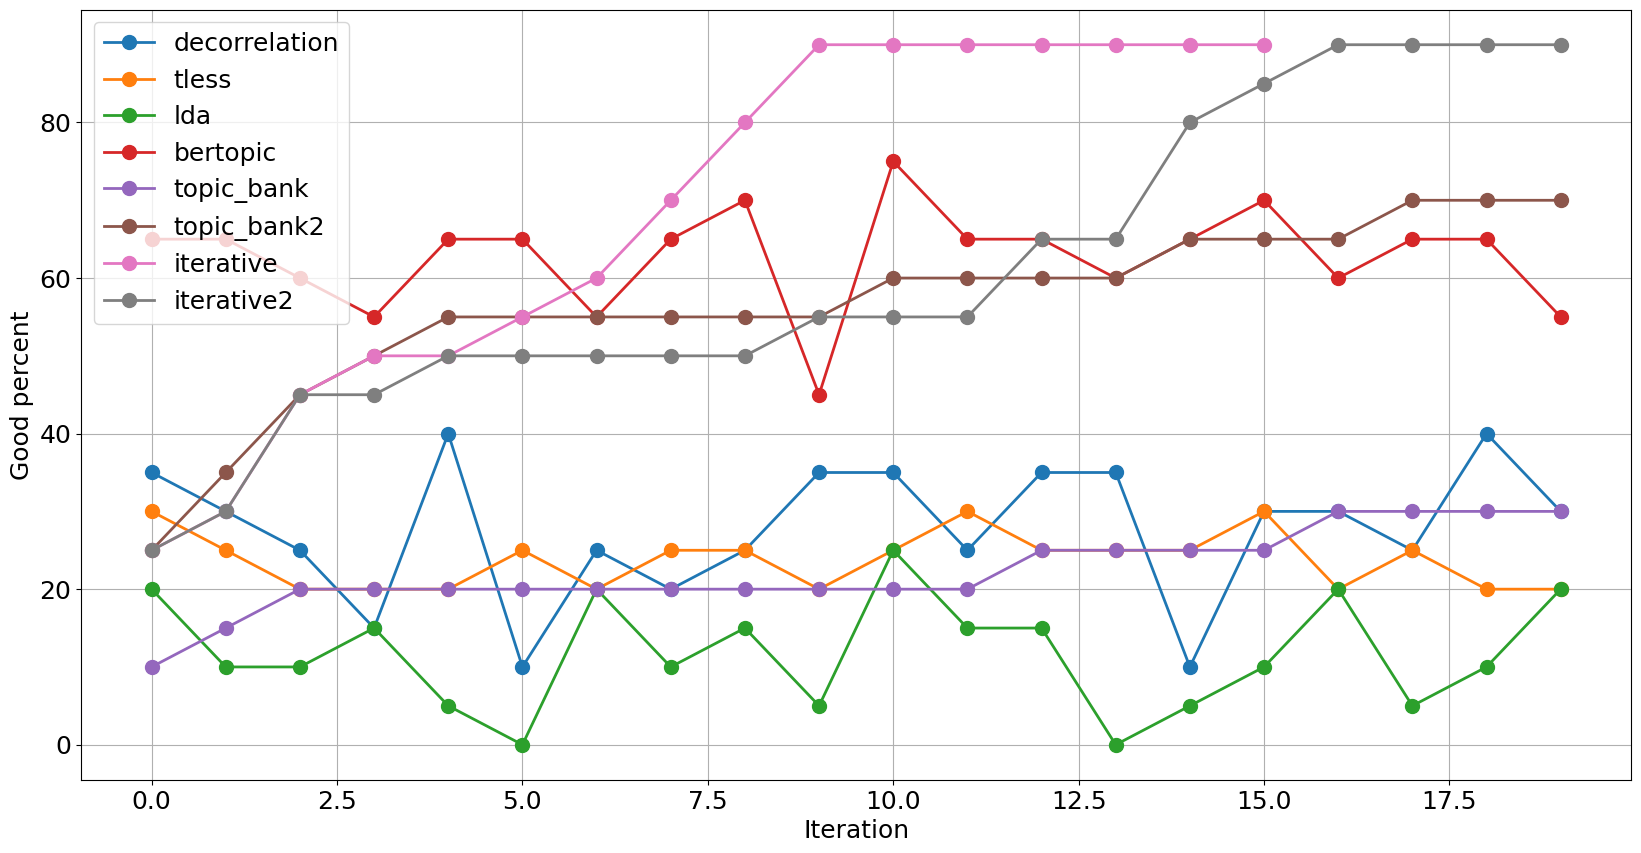

In [379]:
# Not bad

dataset = 'postnauka'
num_topics = 20
getter = get_num_good_topics_percents
ylabel = 'Good percent'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

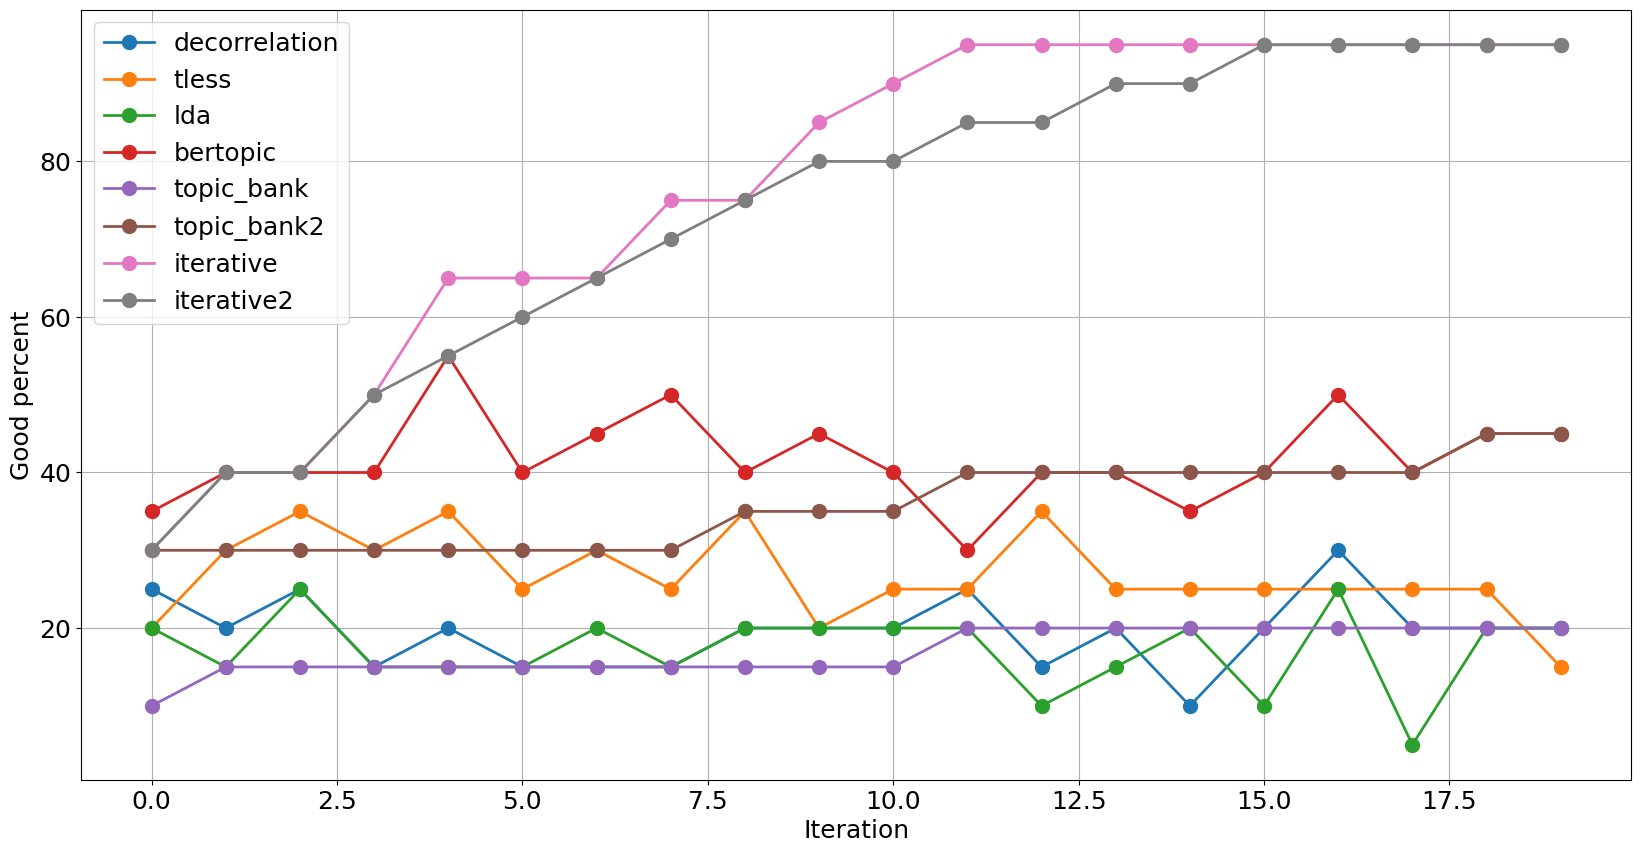

In [381]:
dataset = '20newsgroups'
num_topics = 20
getter = get_num_good_topics_percents
ylabel = 'Good percent'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

In [346]:
DATASETS

['postnauka', '20newsgroups', 'ruwikigood', 'rtlwikiperson', 'mkb10']

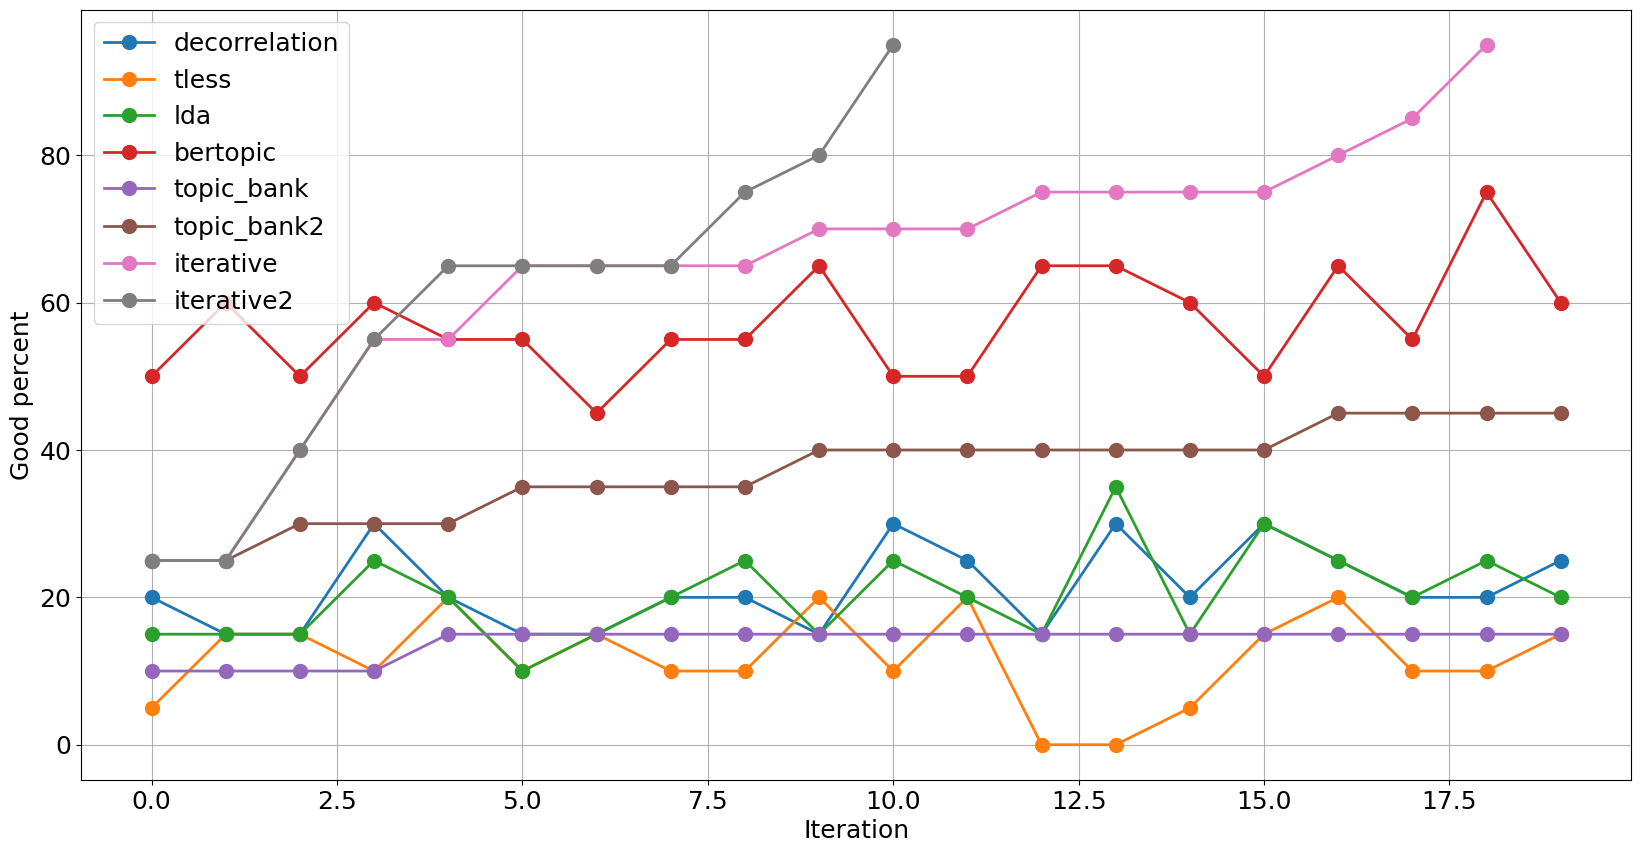

In [383]:
# Good

dataset = 'ruwikigood'
num_topics = 20
getter = get_num_good_topics_percents
ylabel = 'Good percent'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

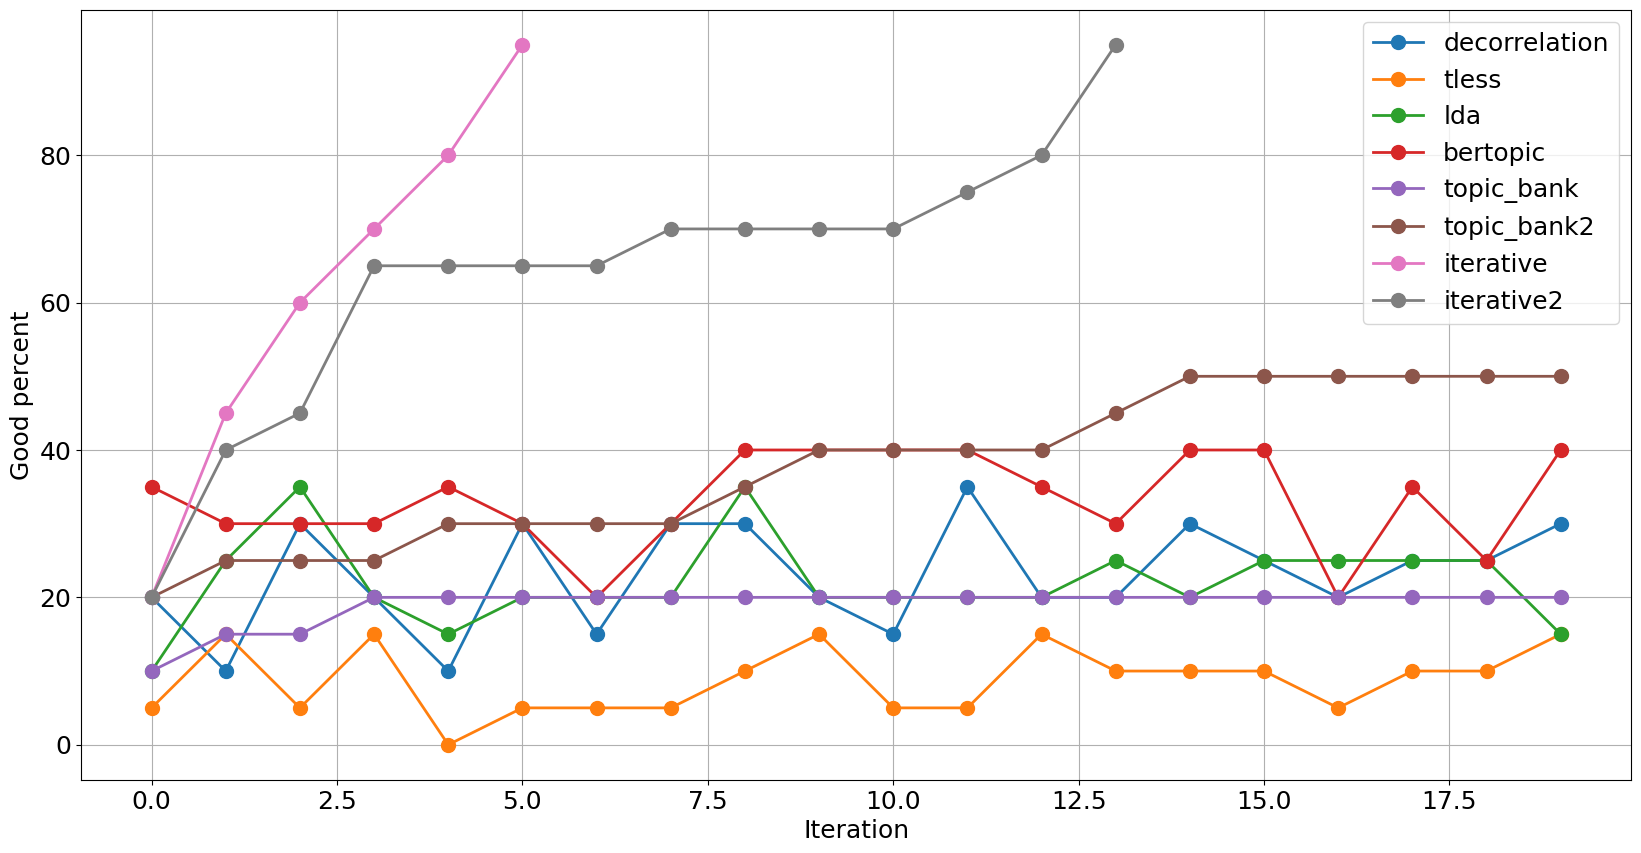

In [385]:
dataset = 'rtlwikiperson'
num_topics = 20
getter = get_num_good_topics_percents
ylabel = 'Good percent'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

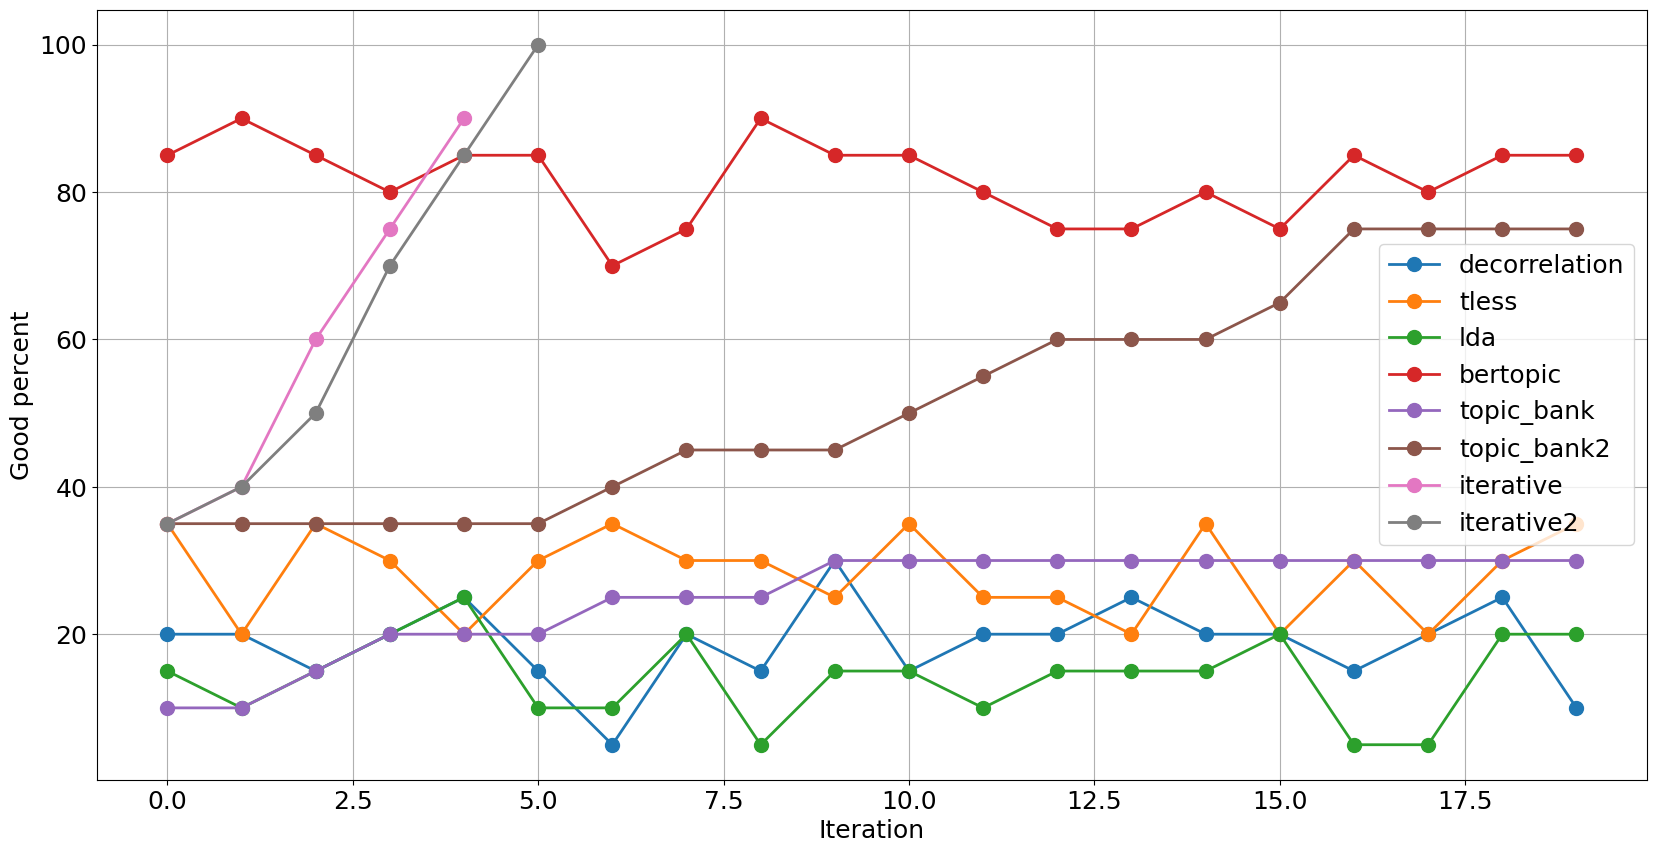

In [386]:
dataset = 'mkb10'
num_topics = 20
getter = get_num_good_topics_percents
ylabel = 'Good percent'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

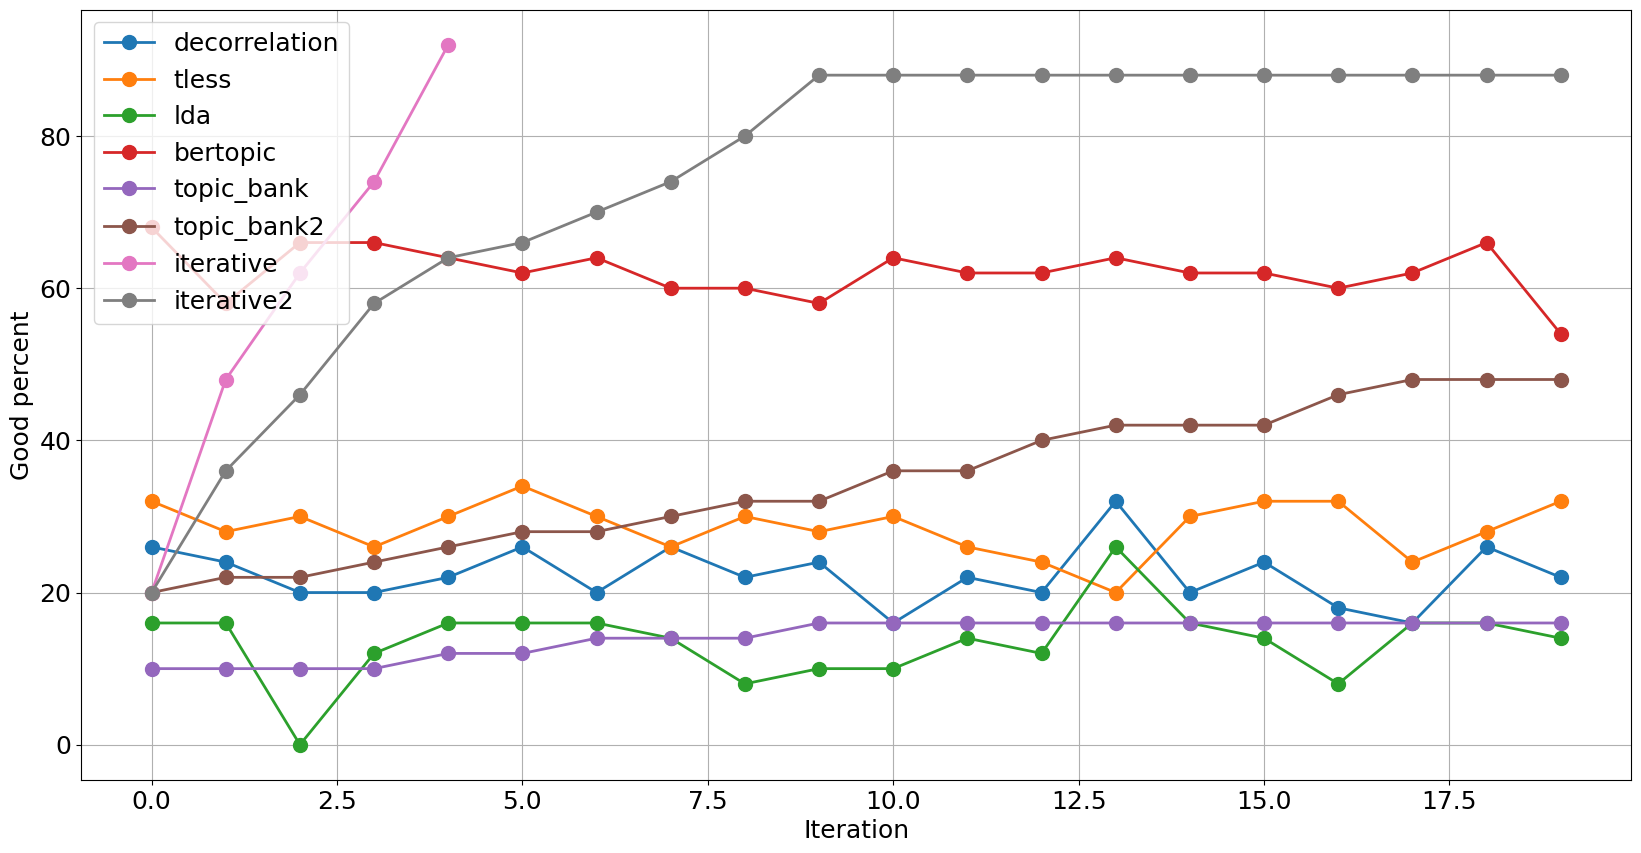

In [388]:
# Good plot (after update -- not so good)

dataset = 'postnauka'
num_topics = 50
getter = get_num_good_topics_percents
ylabel = 'Good percent'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS:  # ['iterative'] +  MODELS_FOR_PLOTS2:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

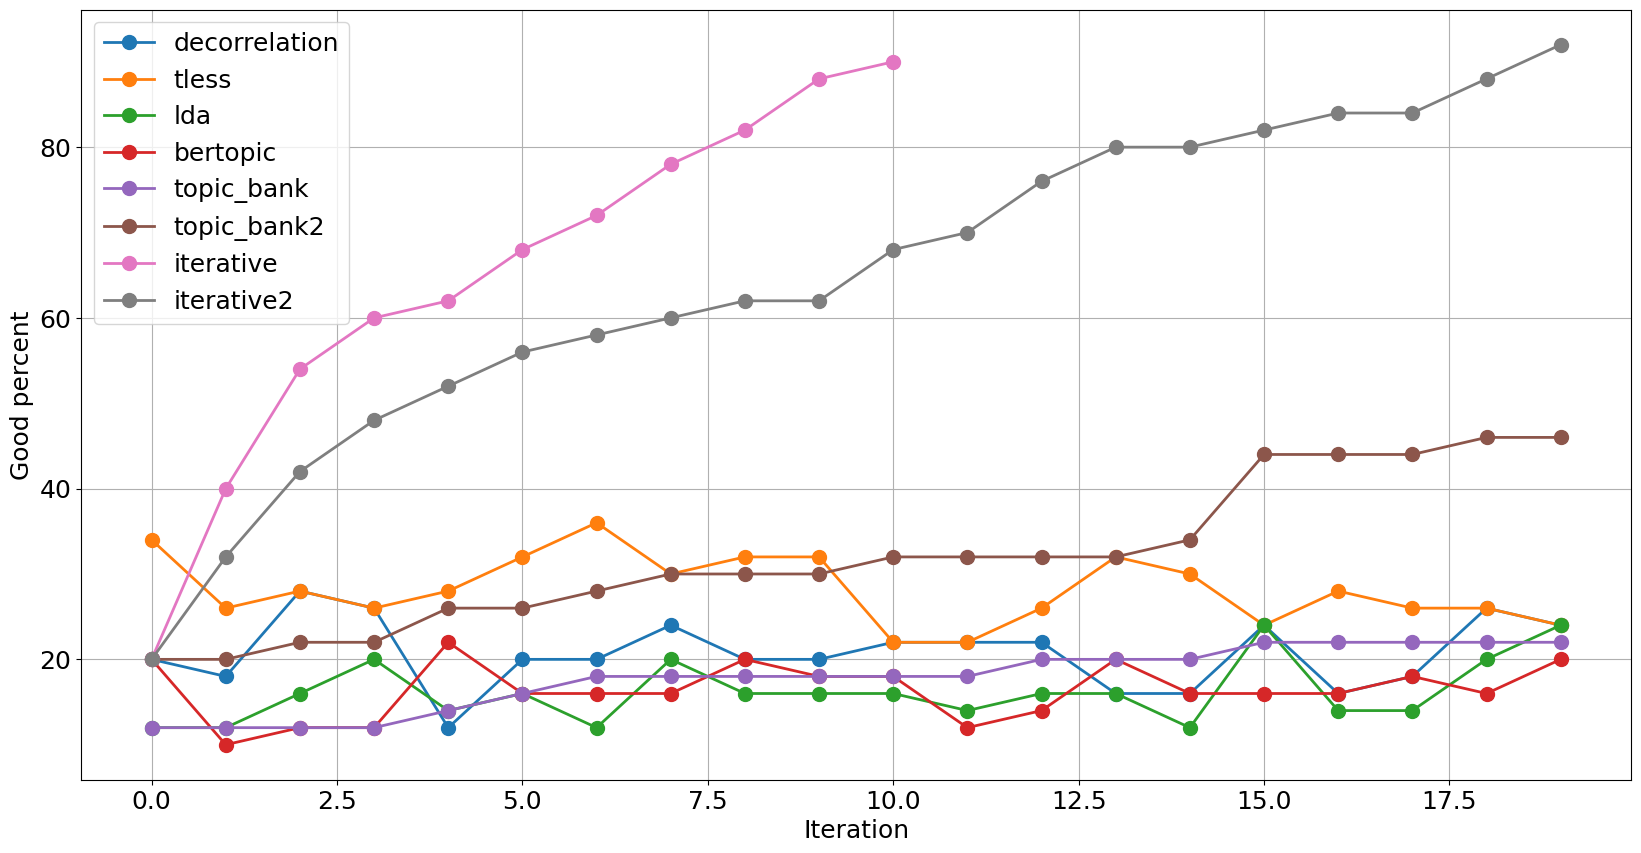

In [390]:
# Not bad plot

dataset = '20newsgroups'
num_topics = 50
getter = get_num_good_topics_percents
ylabel = 'Good percent'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS:  #['iterative'] +  MODELS_FOR_PLOTS2:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

In [352]:
DATASETS

['postnauka', '20newsgroups', 'ruwikigood', 'rtlwikiperson', 'mkb10']

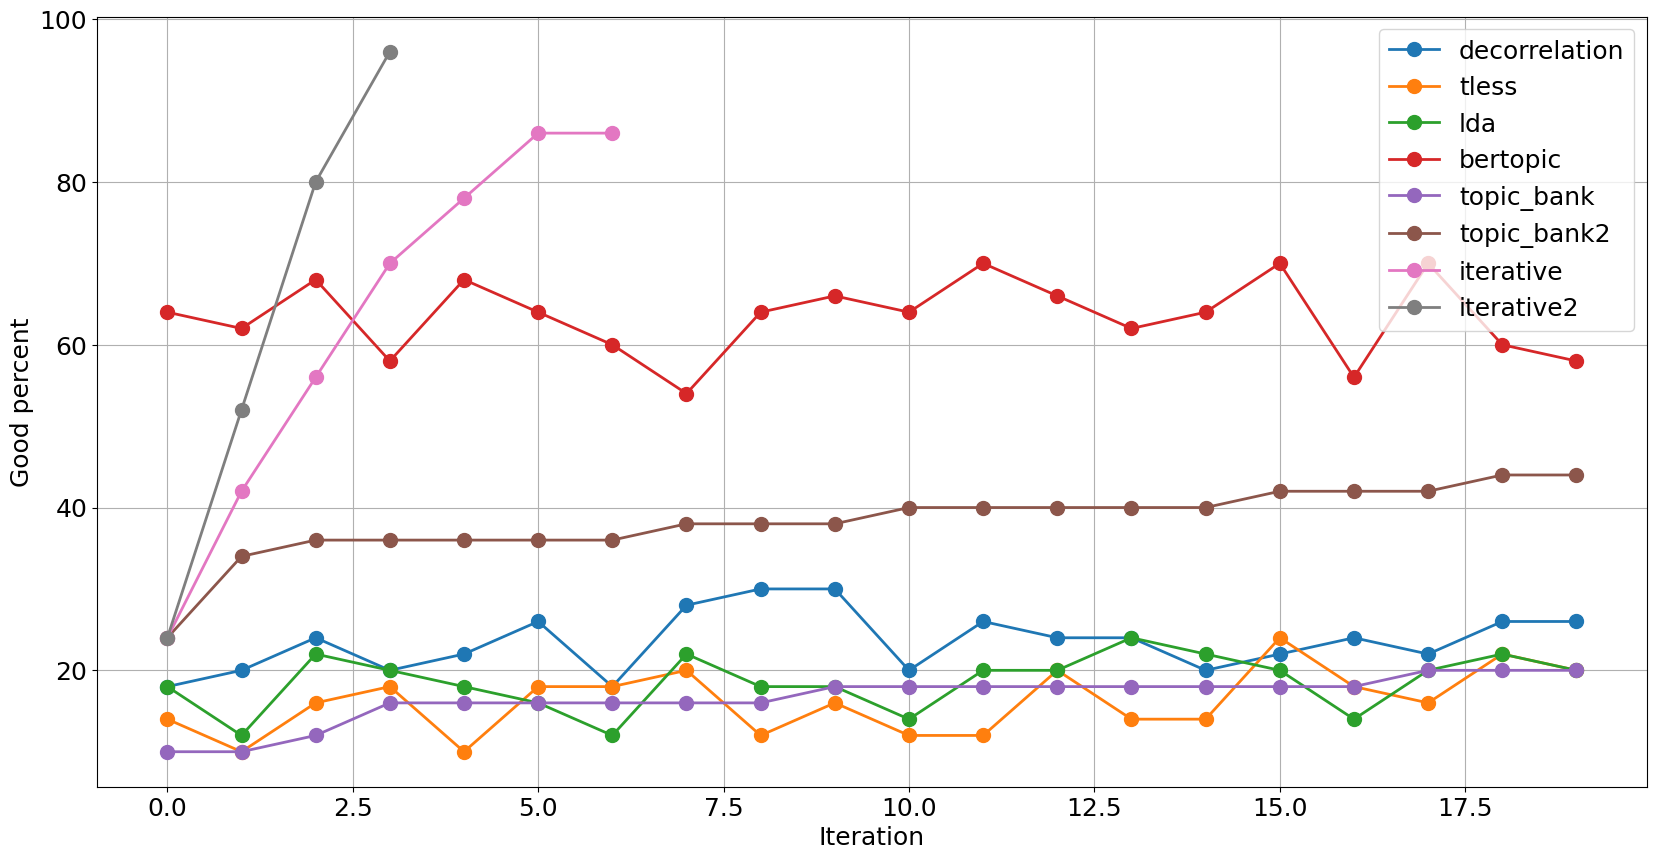

In [391]:
dataset = 'ruwikigood'
num_topics = 50
getter = get_num_good_topics_percents
ylabel = 'Good percent'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS:  # ['iterative'] + MODELS_FOR_PLOTS2:  # + ['iterative']:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

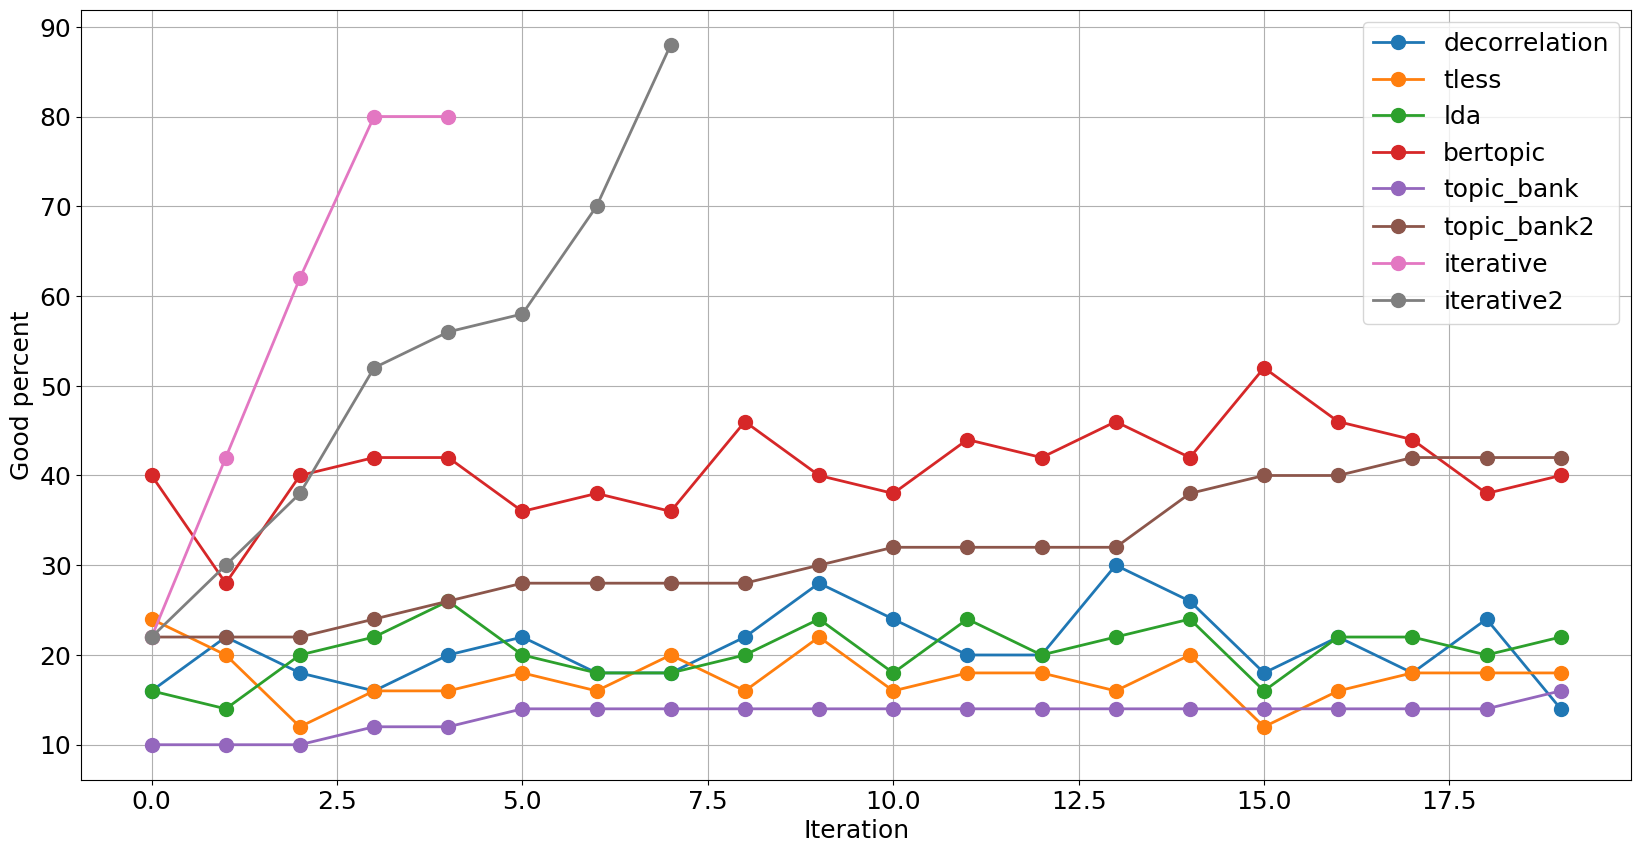

In [393]:
# Not bad plot

dataset = 'rtlwikiperson'
num_topics = 50
getter = get_num_good_topics_percents
ylabel = 'Good percent'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

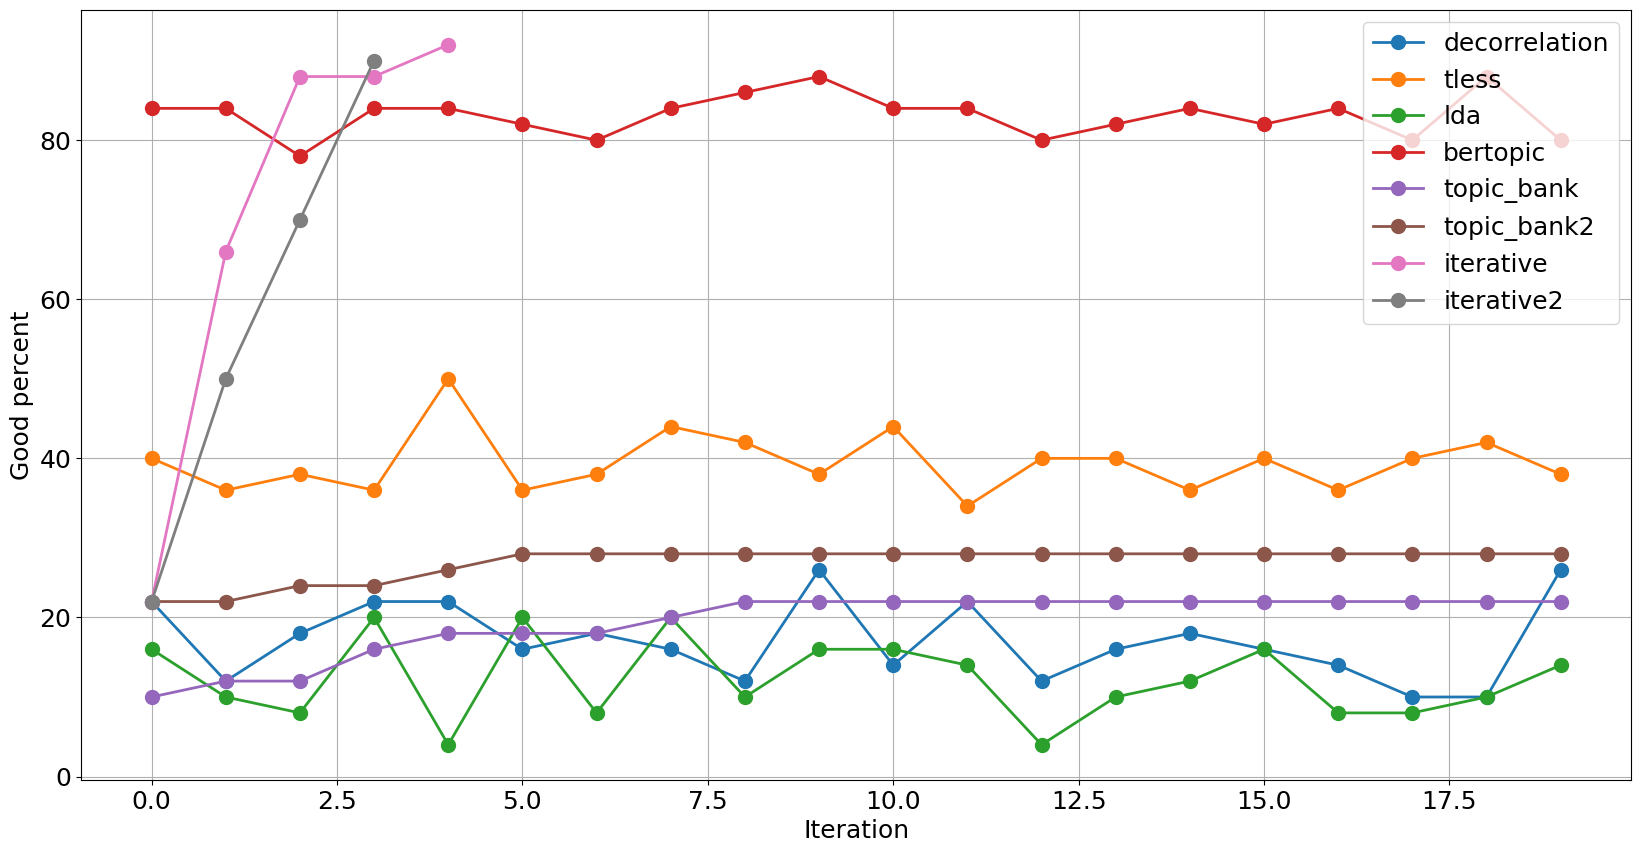

In [396]:
dataset = 'mkb10'
num_topics = 50
getter = get_num_good_topics_percents
ylabel = 'Good percent'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

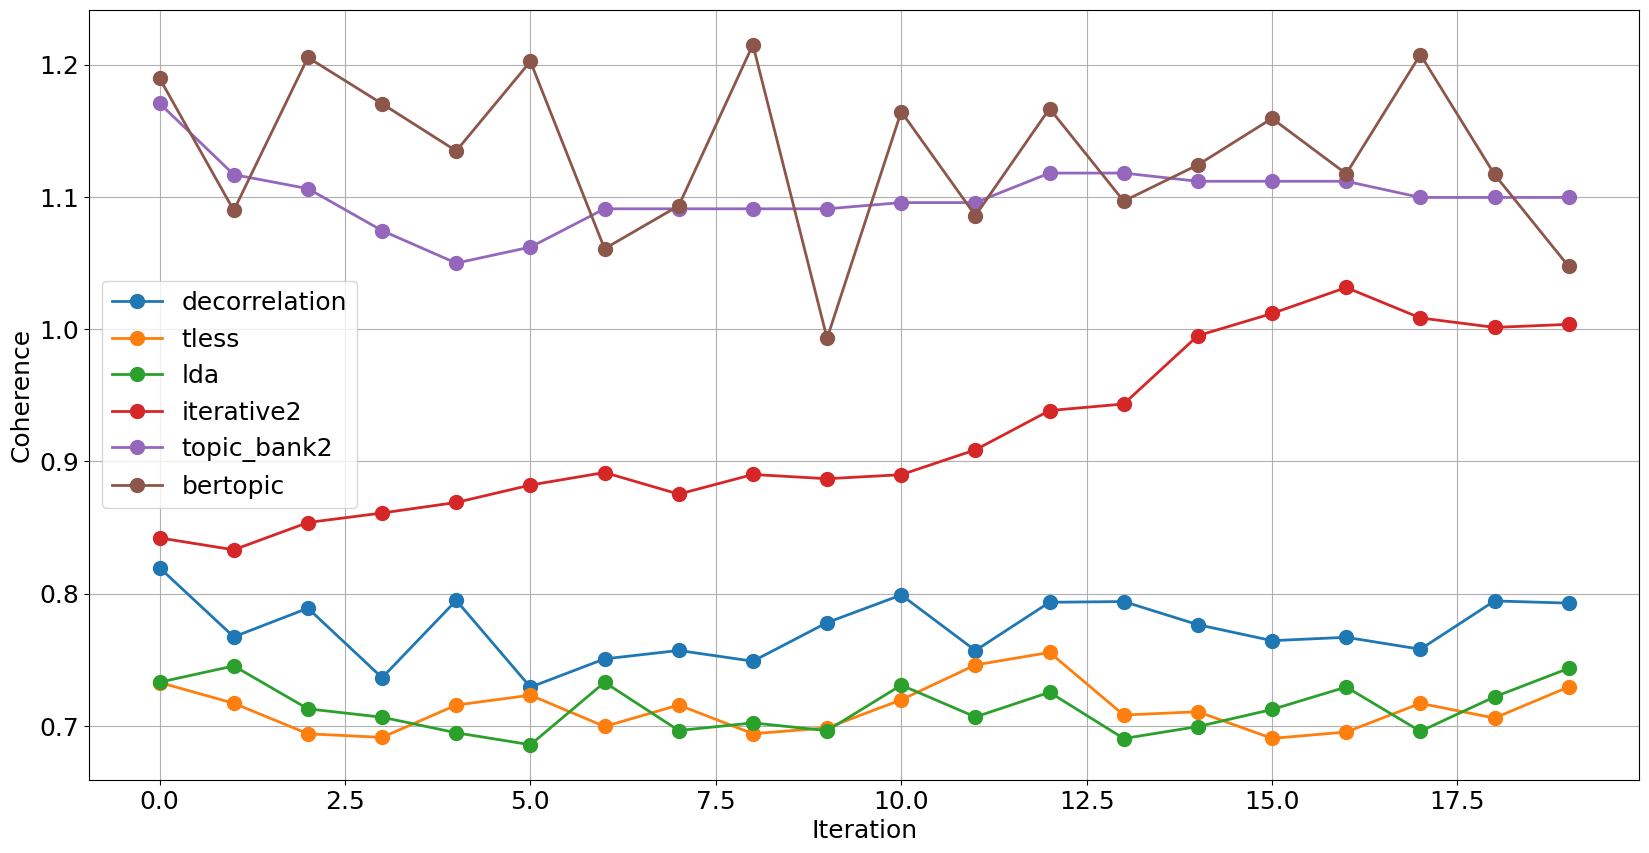

In [356]:
# Not bad

dataset = 'postnauka'
num_topics = 20
getter = get_coherences
ylabel = 'Coherence'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS2:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

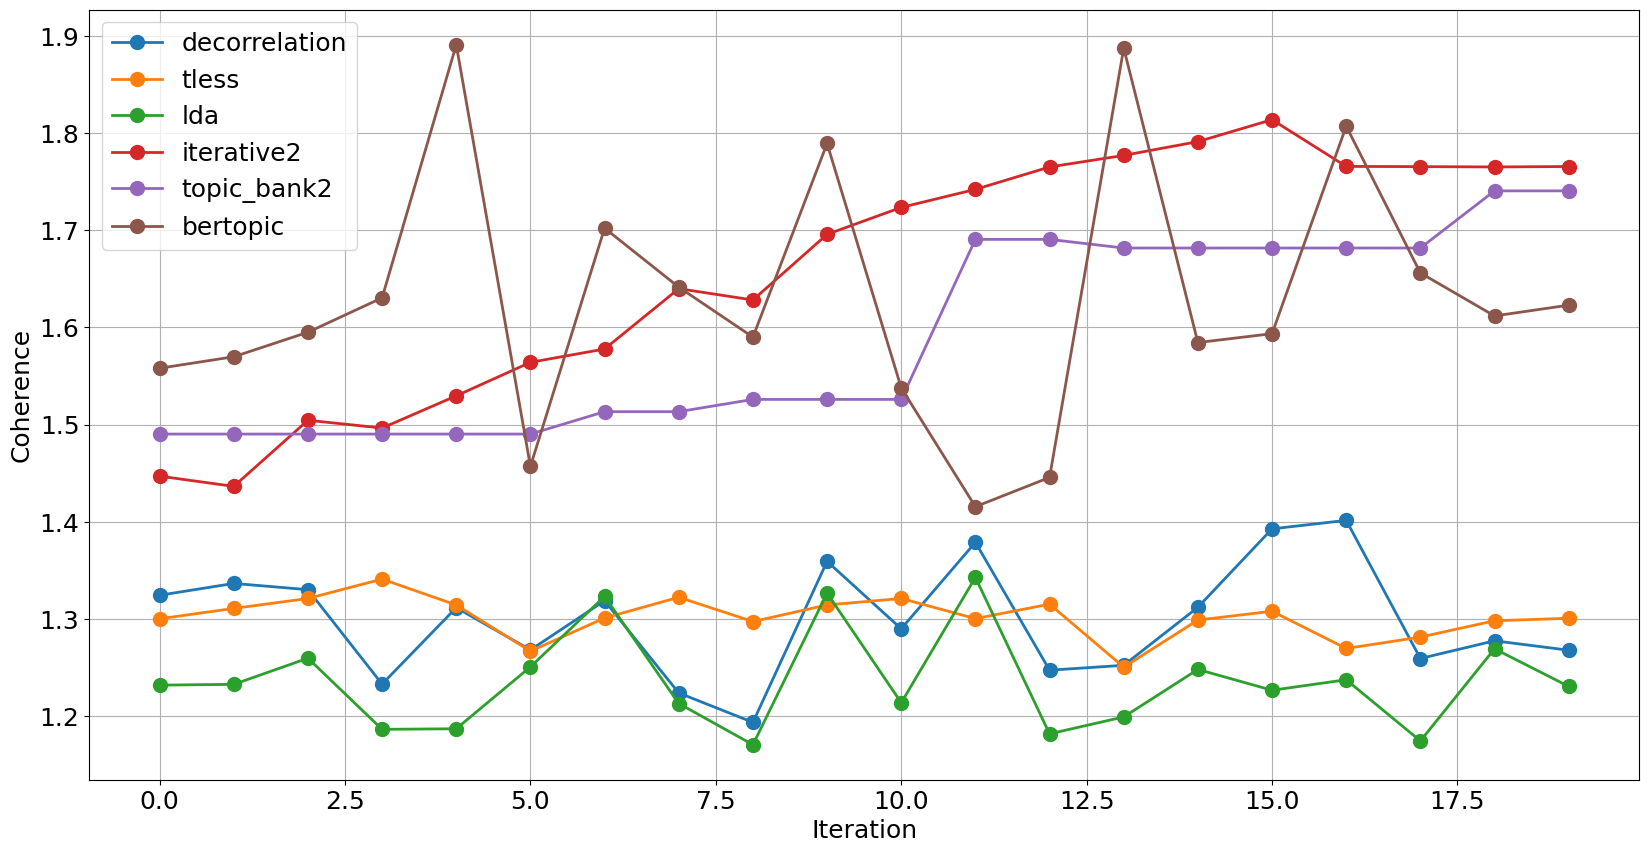

In [357]:
dataset = '20newsgroups'
num_topics = 20
getter = get_coherences
ylabel = 'Coherence'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS2:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

In [246]:
DATASETS

['postnauka', '20newsgroups', 'ruwikigood', 'rtlwikiperson', 'mkb10']

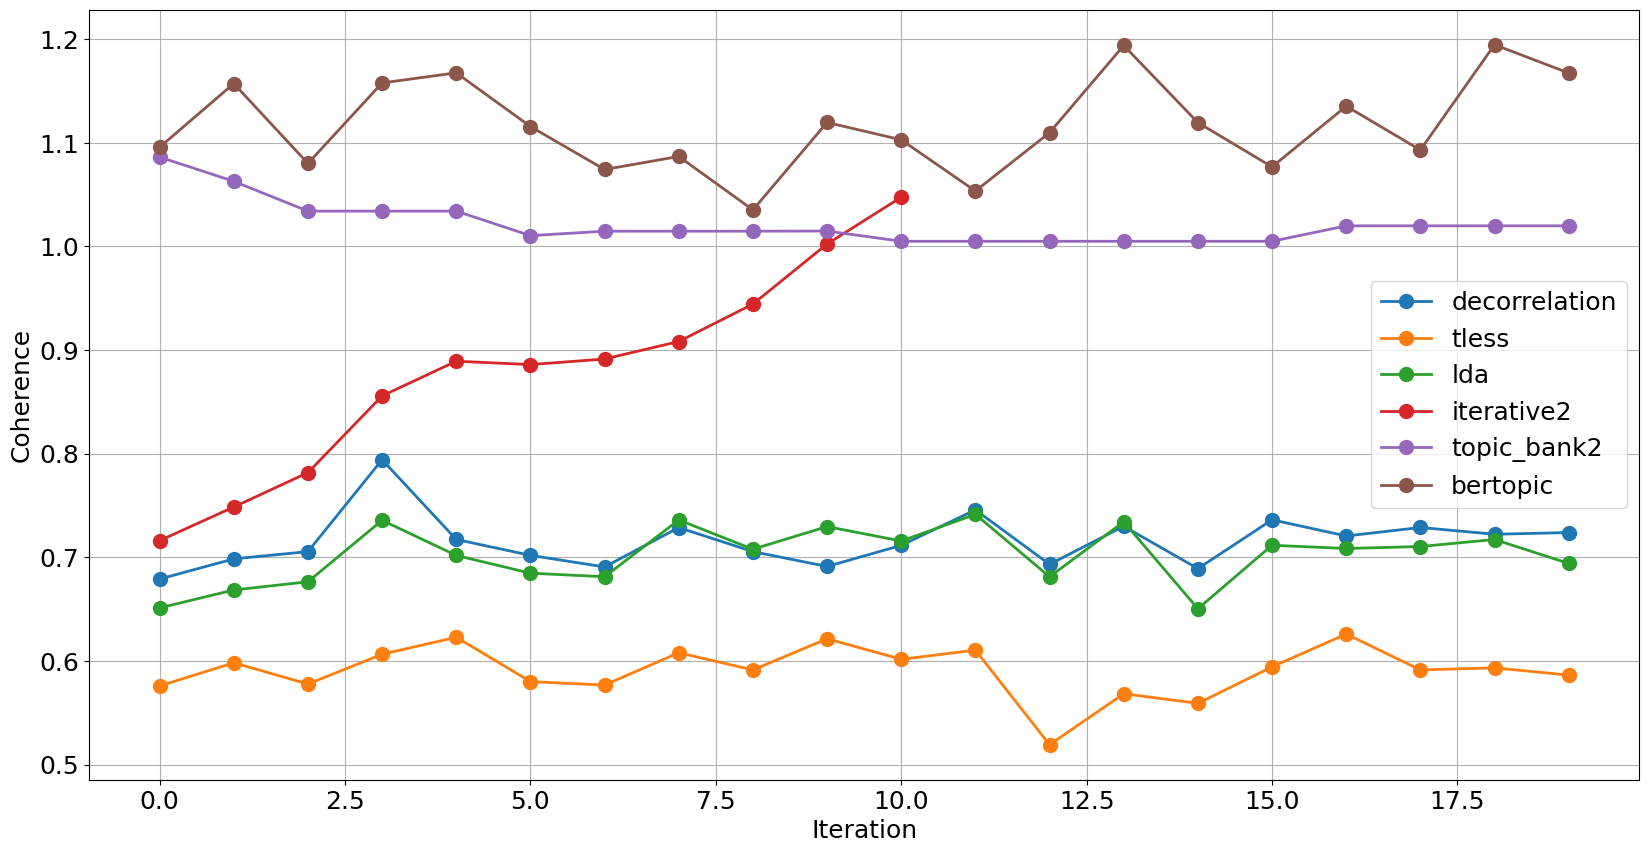

In [358]:
dataset = 'ruwikigood'
num_topics = 20
getter = get_coherences
ylabel = 'Coherence'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS2:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

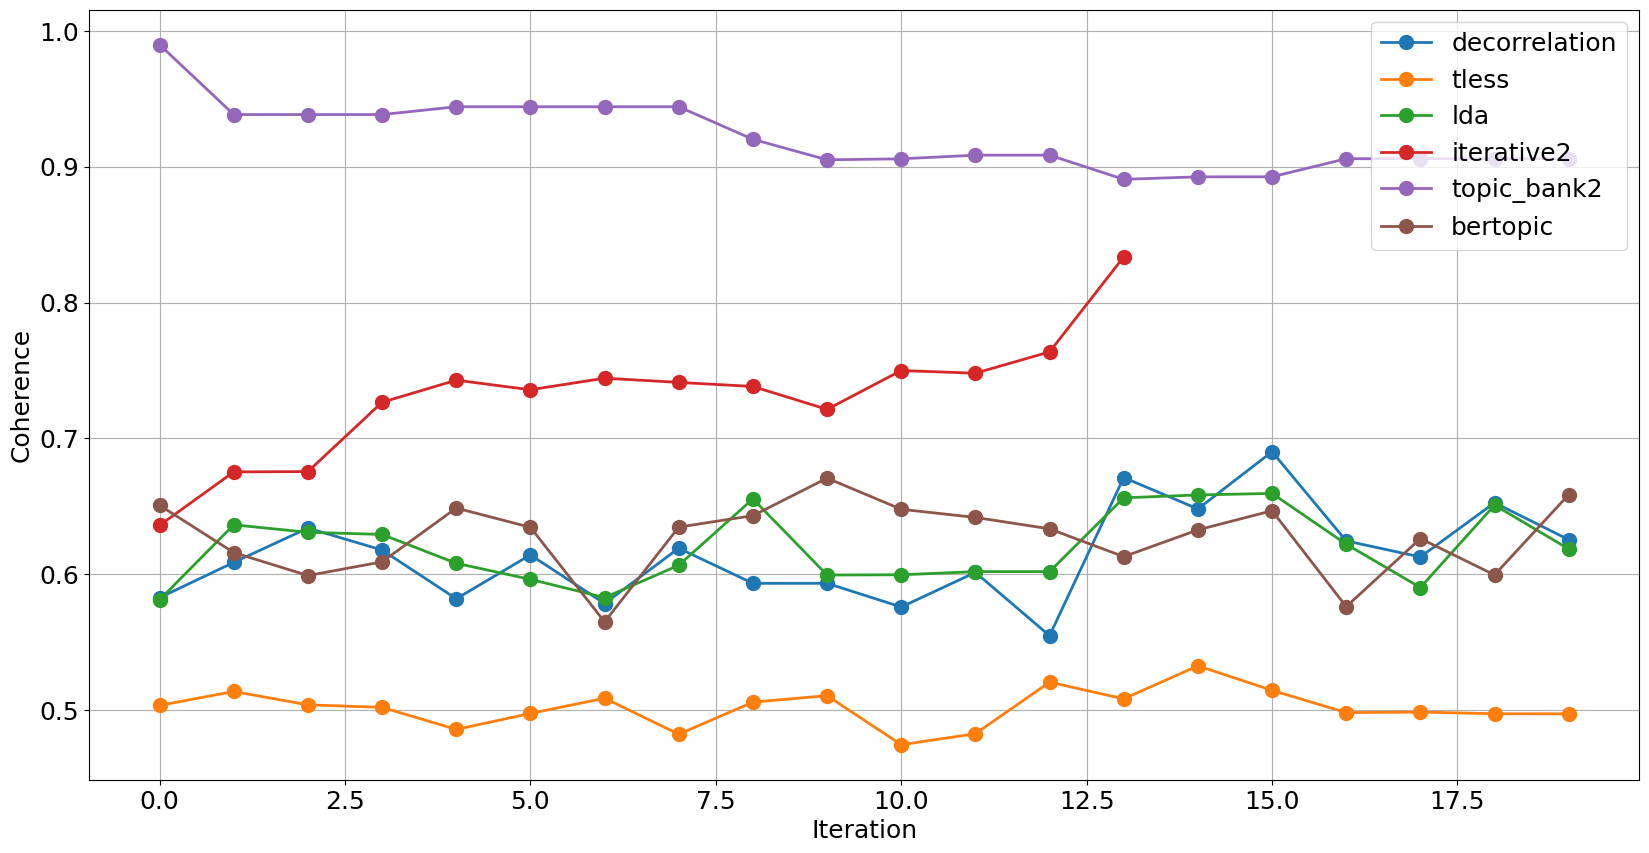

In [359]:
dataset = 'rtlwikiperson'
num_topics = 20
getter = get_coherences
ylabel = 'Coherence'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS2:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

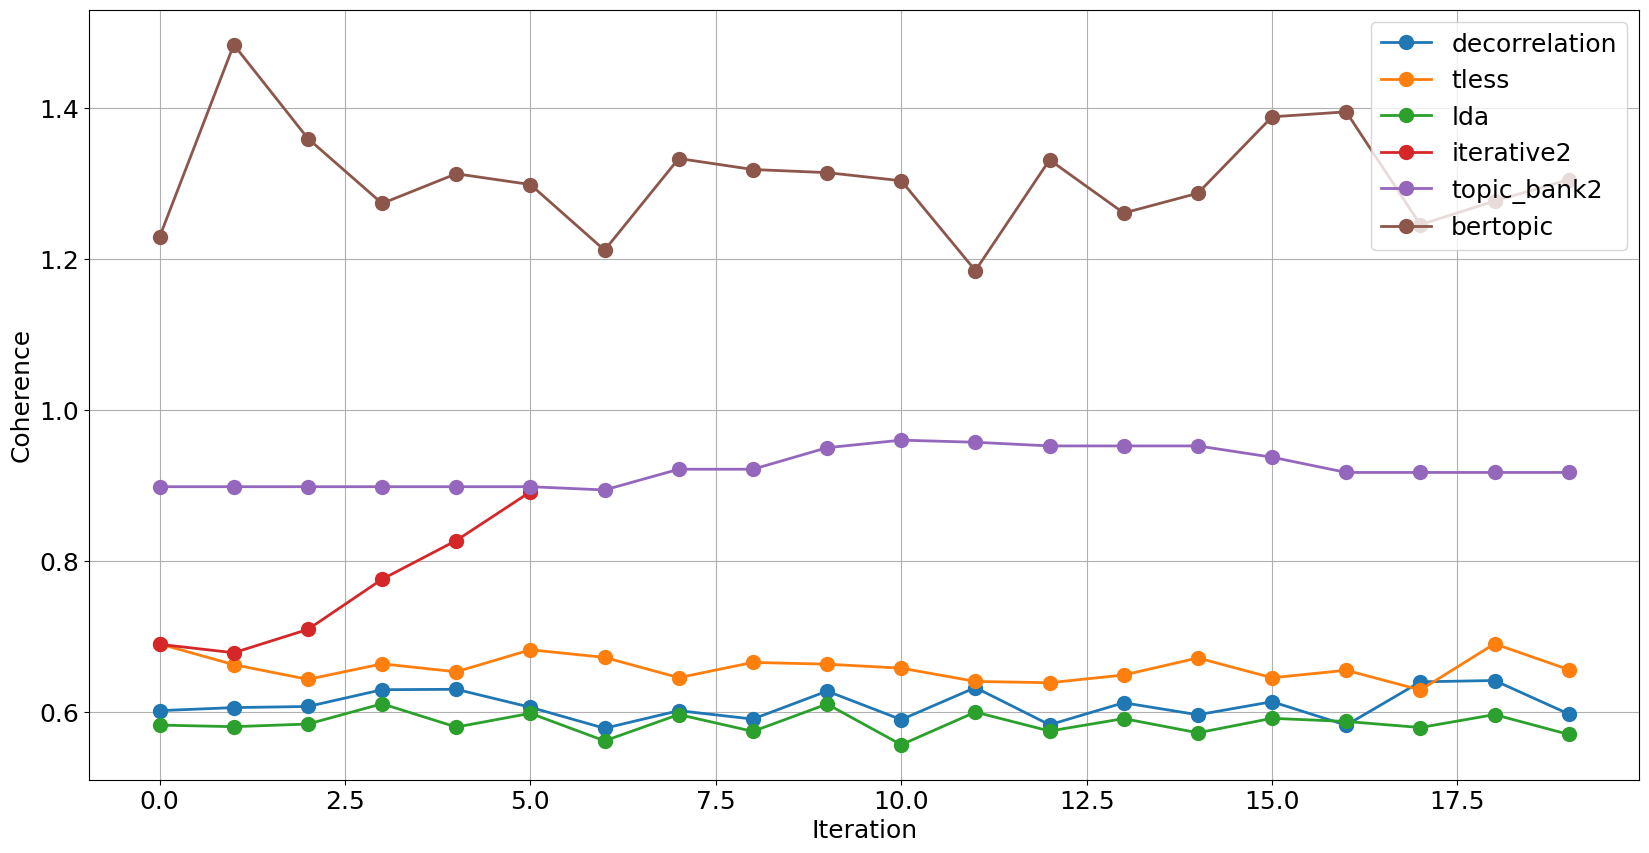

In [360]:
dataset = 'mkb10'
num_topics = 20
getter = get_coherences
ylabel = 'Coherence'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS2:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

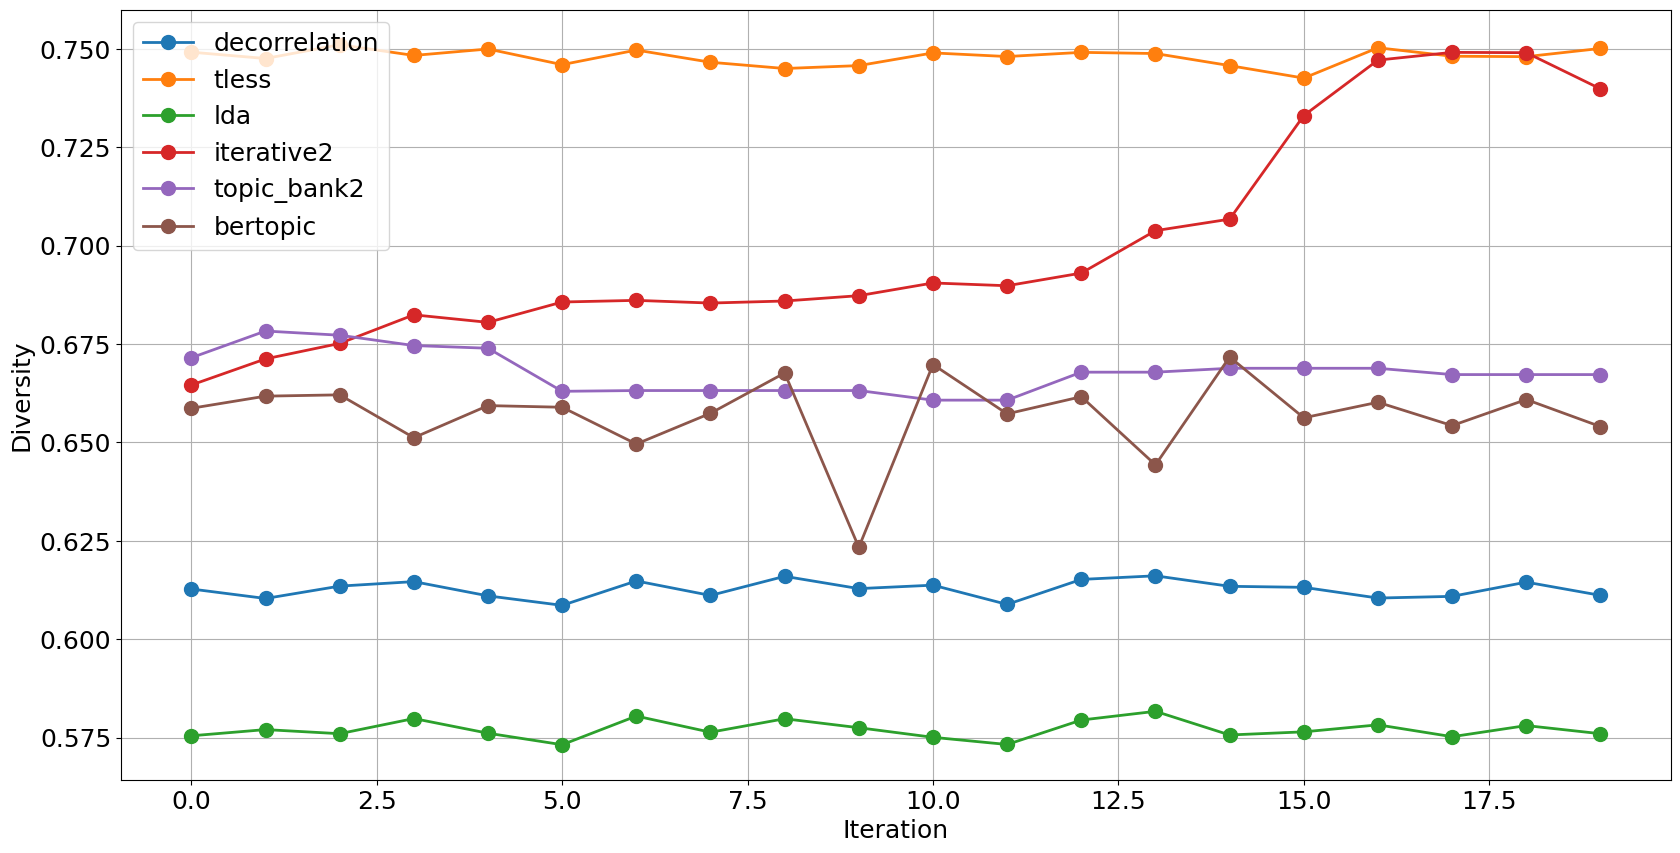

In [263]:
dataset = 'postnauka'
num_topics = 20
getter = get_diversities_js
ylabel = 'Diversity'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS2:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

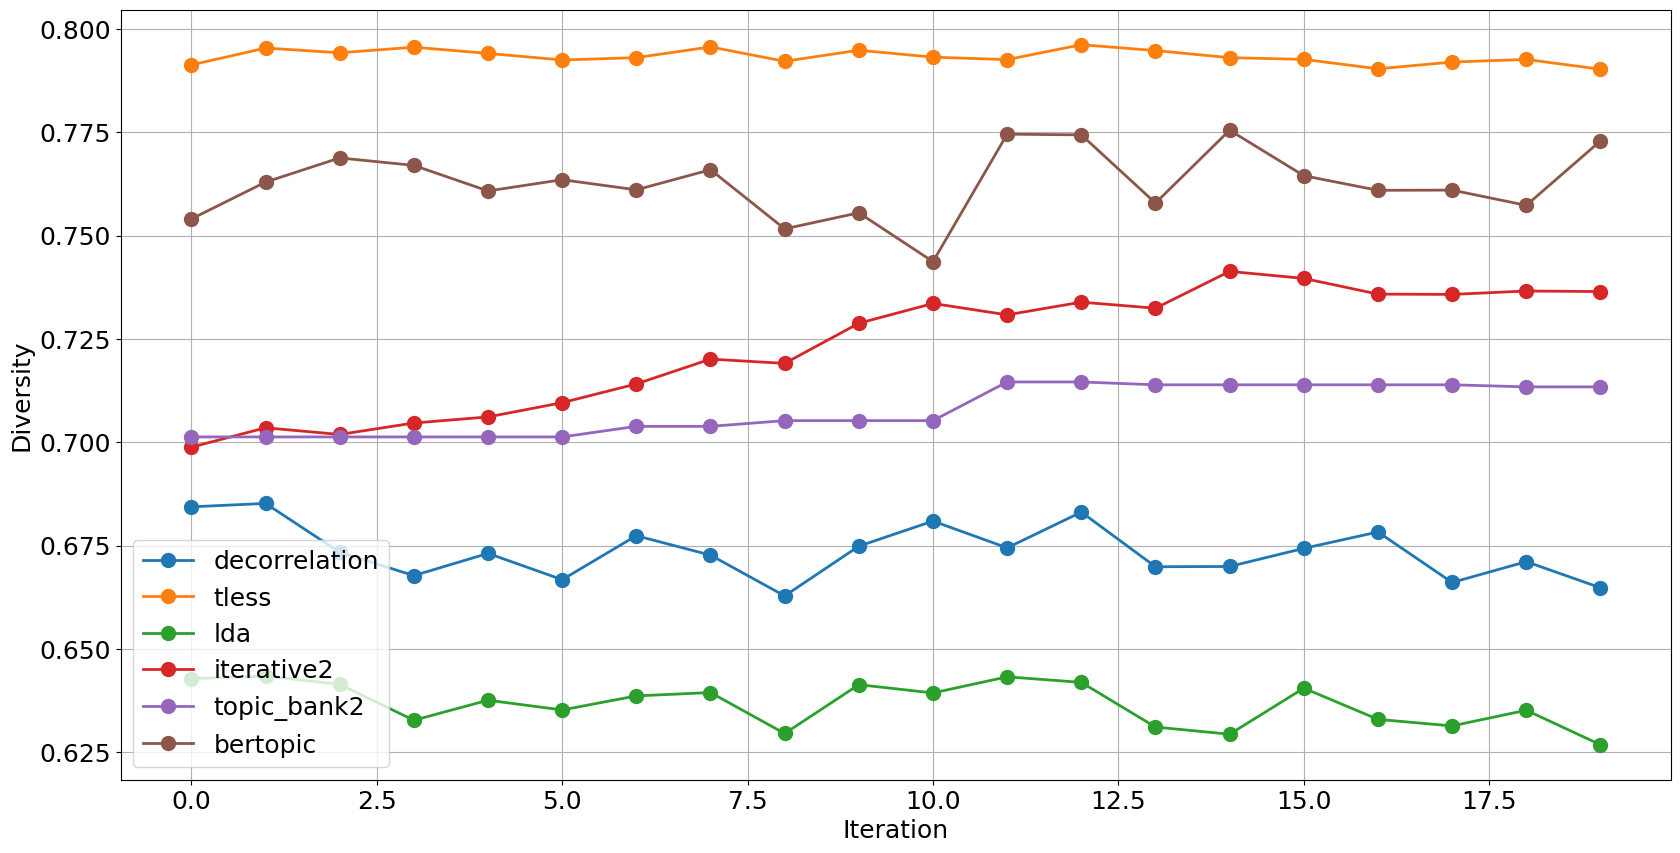

In [264]:
dataset = '20newsgroups'
num_topics = 20
getter = get_diversities_js
ylabel = 'Diversity'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS2:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

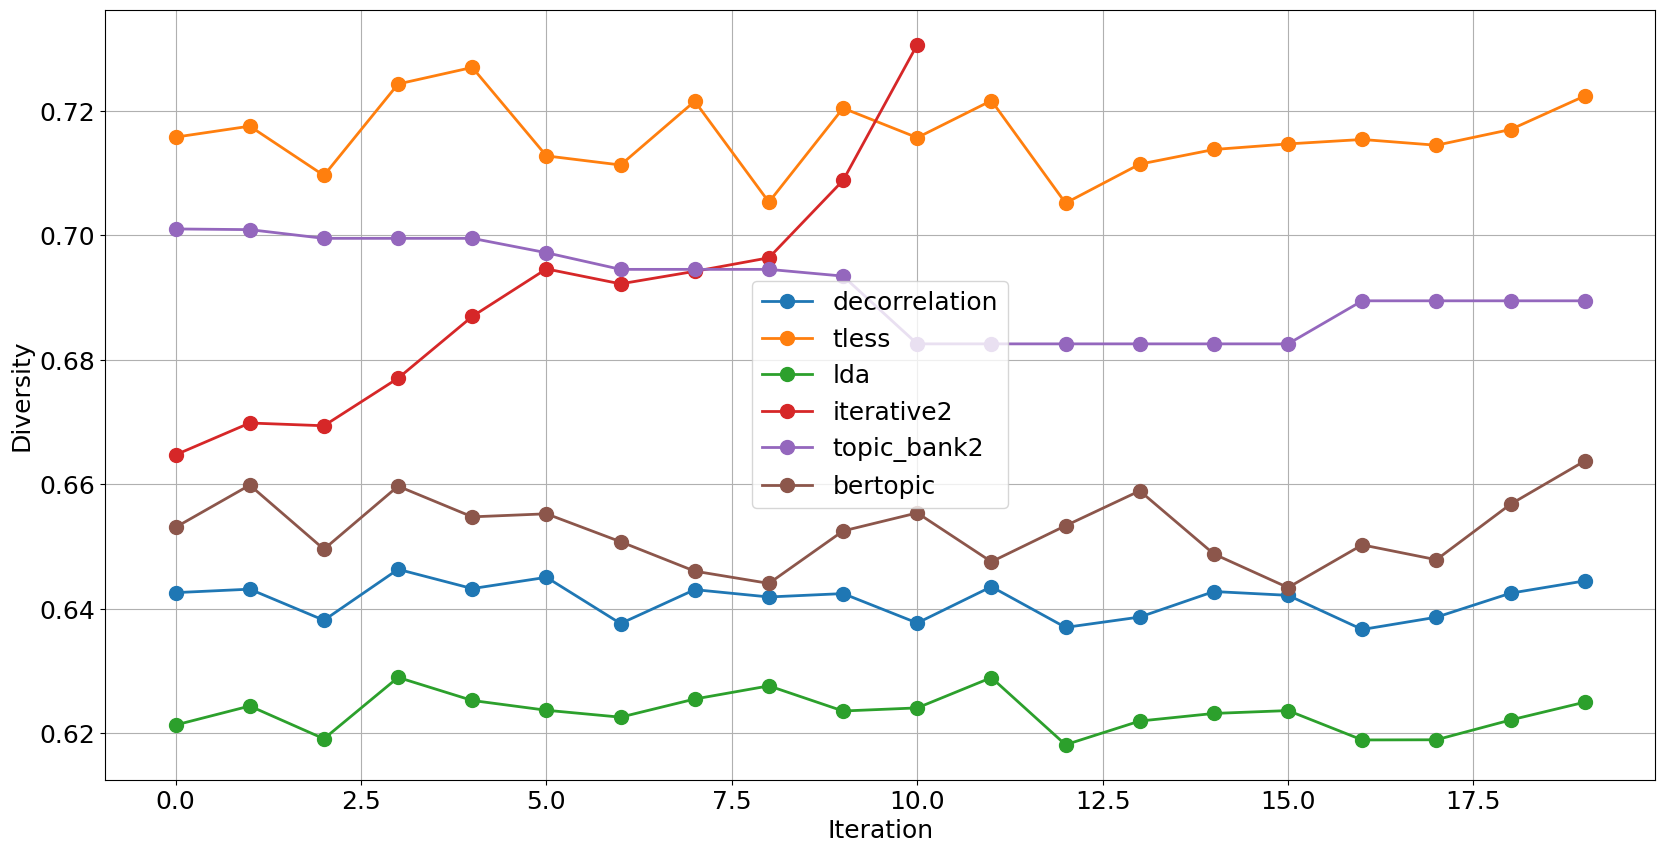

In [265]:
dataset = 'ruwikigood'
num_topics = 20
getter = get_diversities_js
ylabel = 'Diversity'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS2:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

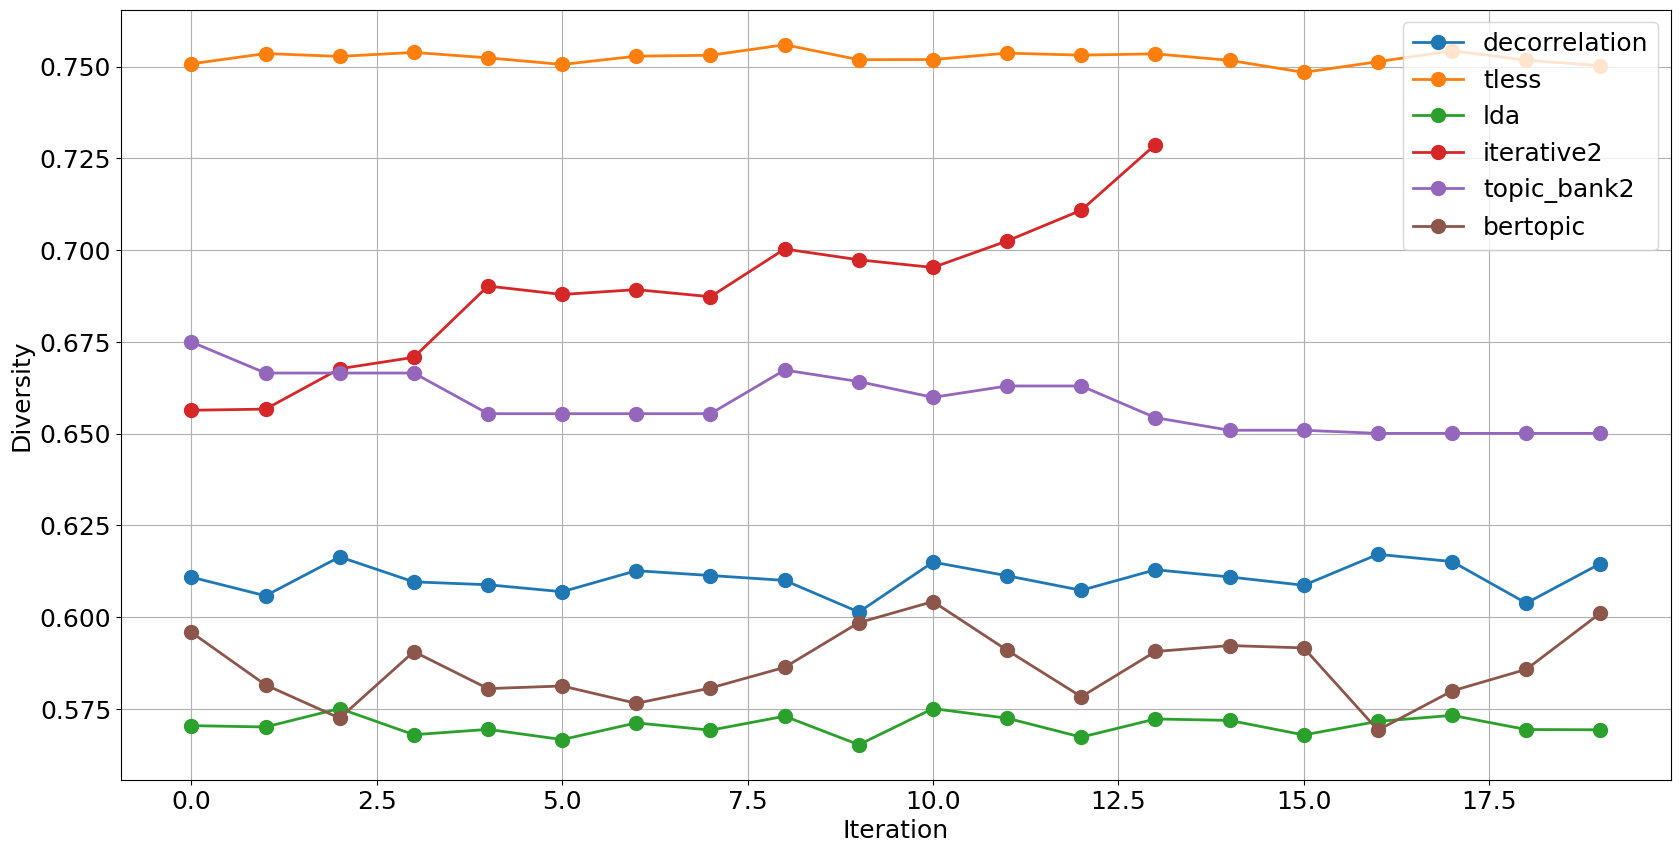

In [266]:
dataset = 'rtlwikiperson'
num_topics = 20
getter = get_diversities_js
ylabel = 'Diversity'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS2:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

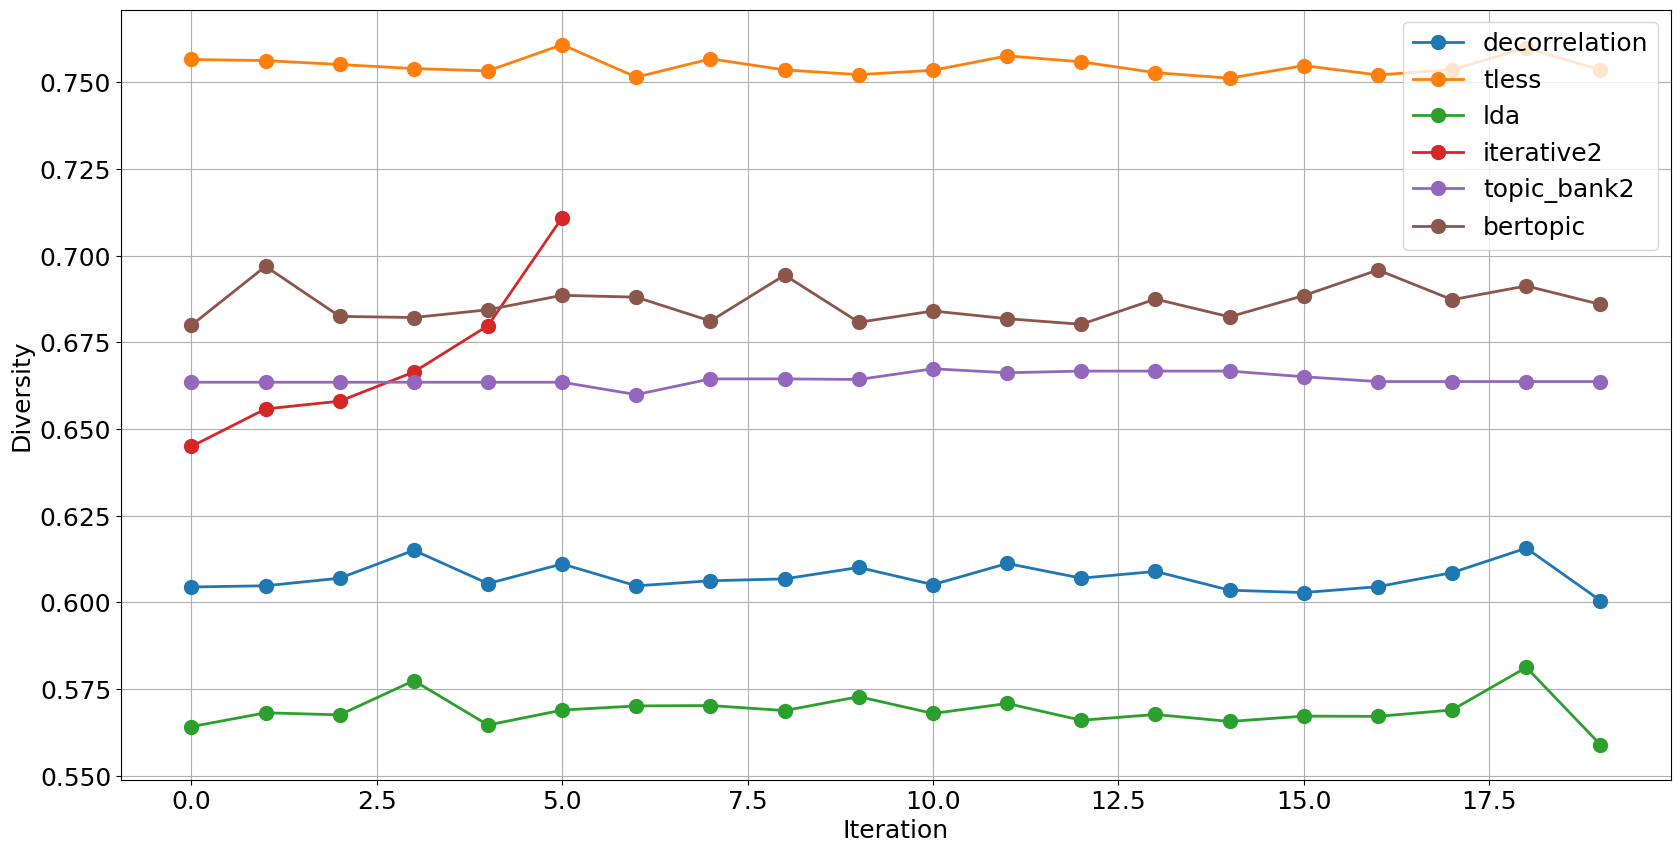

In [267]:
dataset = 'mkb10'
num_topics = 20
getter = get_diversities_js
ylabel = 'Diversity'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS2:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

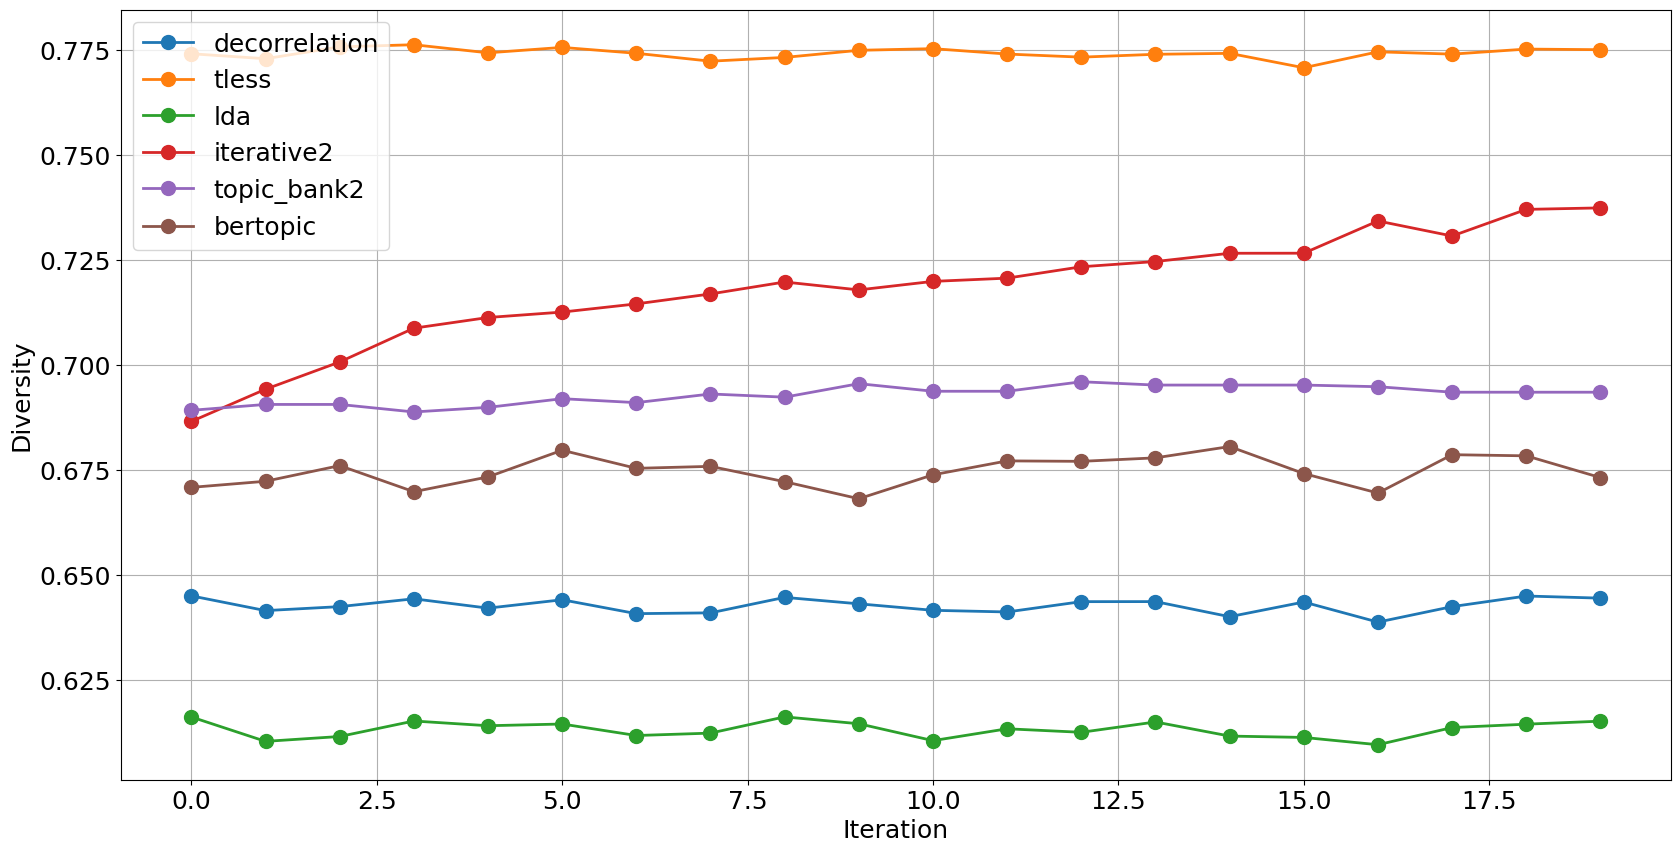

In [268]:
dataset = 'postnauka'
num_topics = 50
getter = get_diversities_js
ylabel = 'Diversity'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS2:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

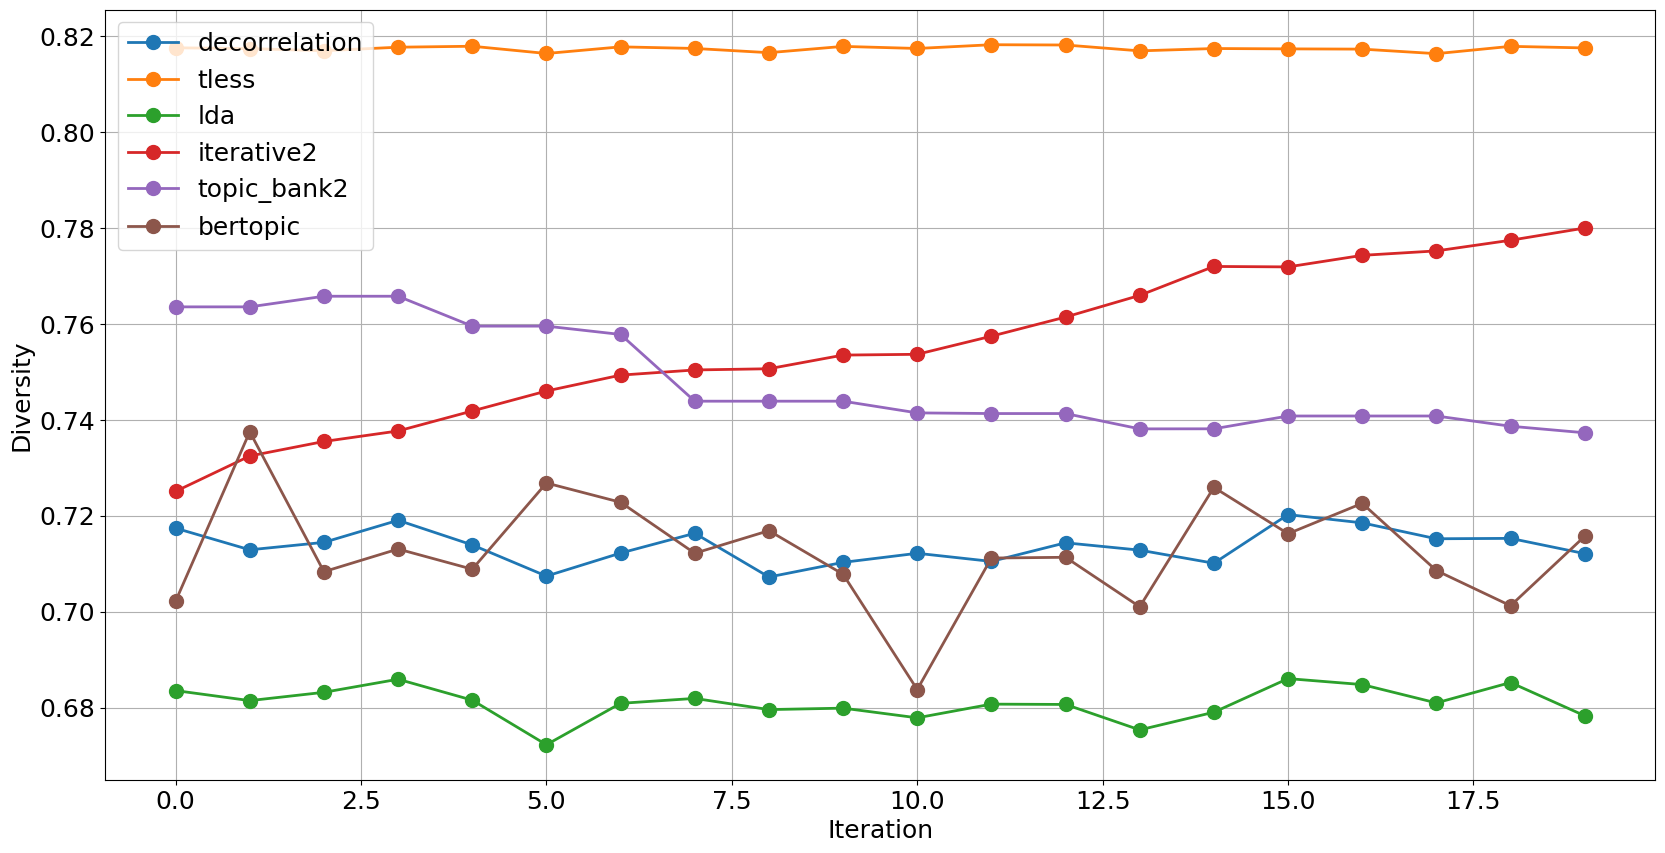

In [269]:
dataset = '20newsgroups'
num_topics = 50
getter = get_diversities_js
ylabel = 'Diversity'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS2:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

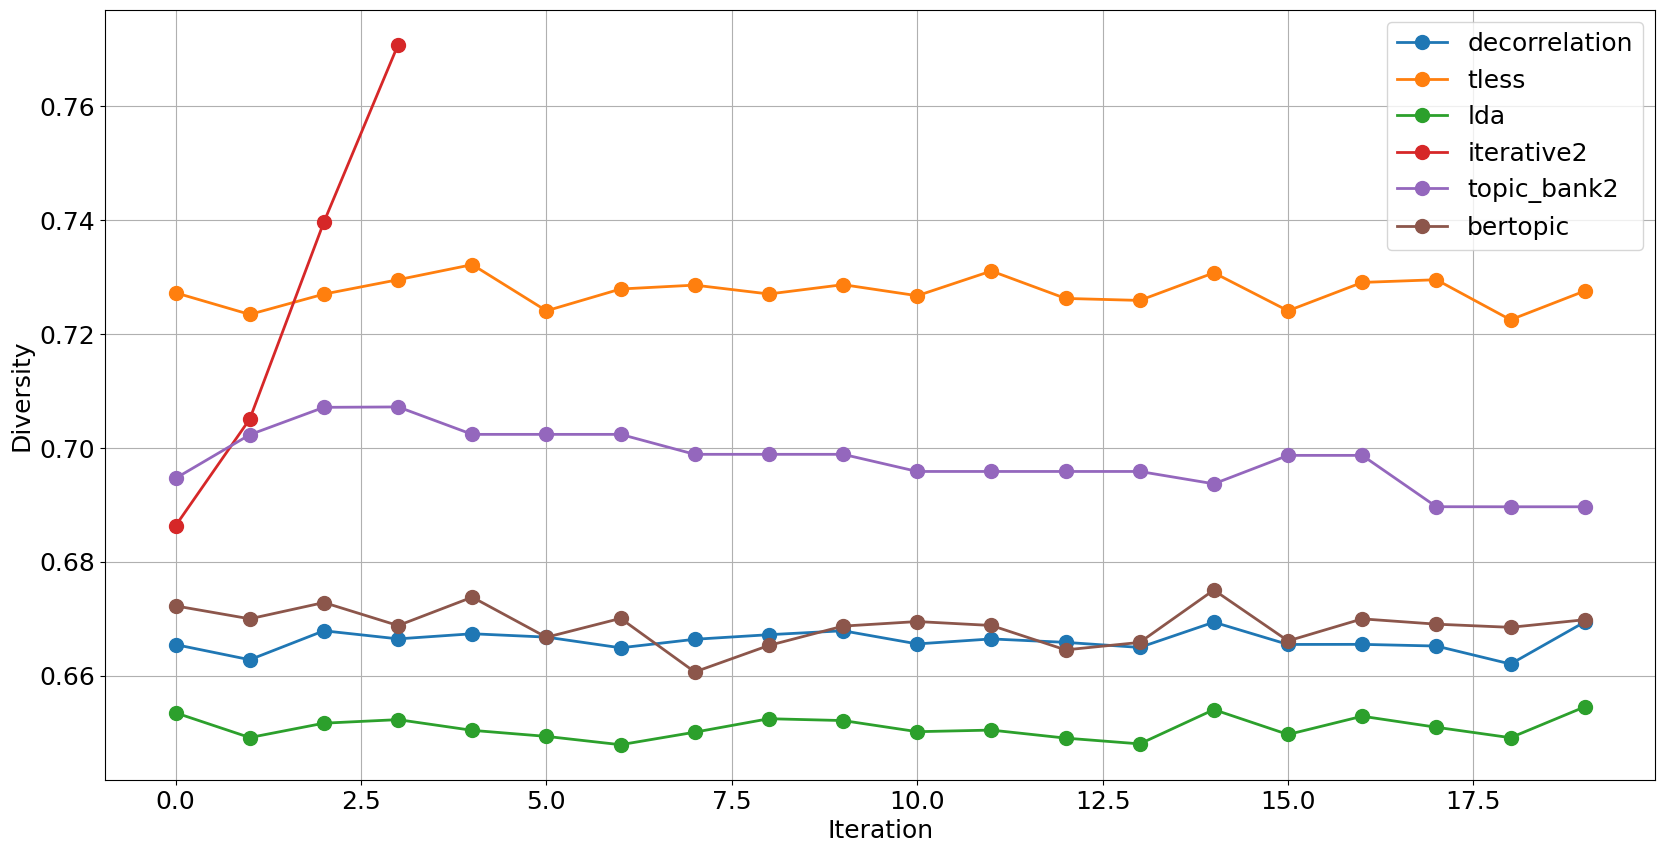

In [270]:
dataset = 'ruwikigood'
num_topics = 50
getter = get_diversities_js
ylabel = 'Diversity'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS2:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

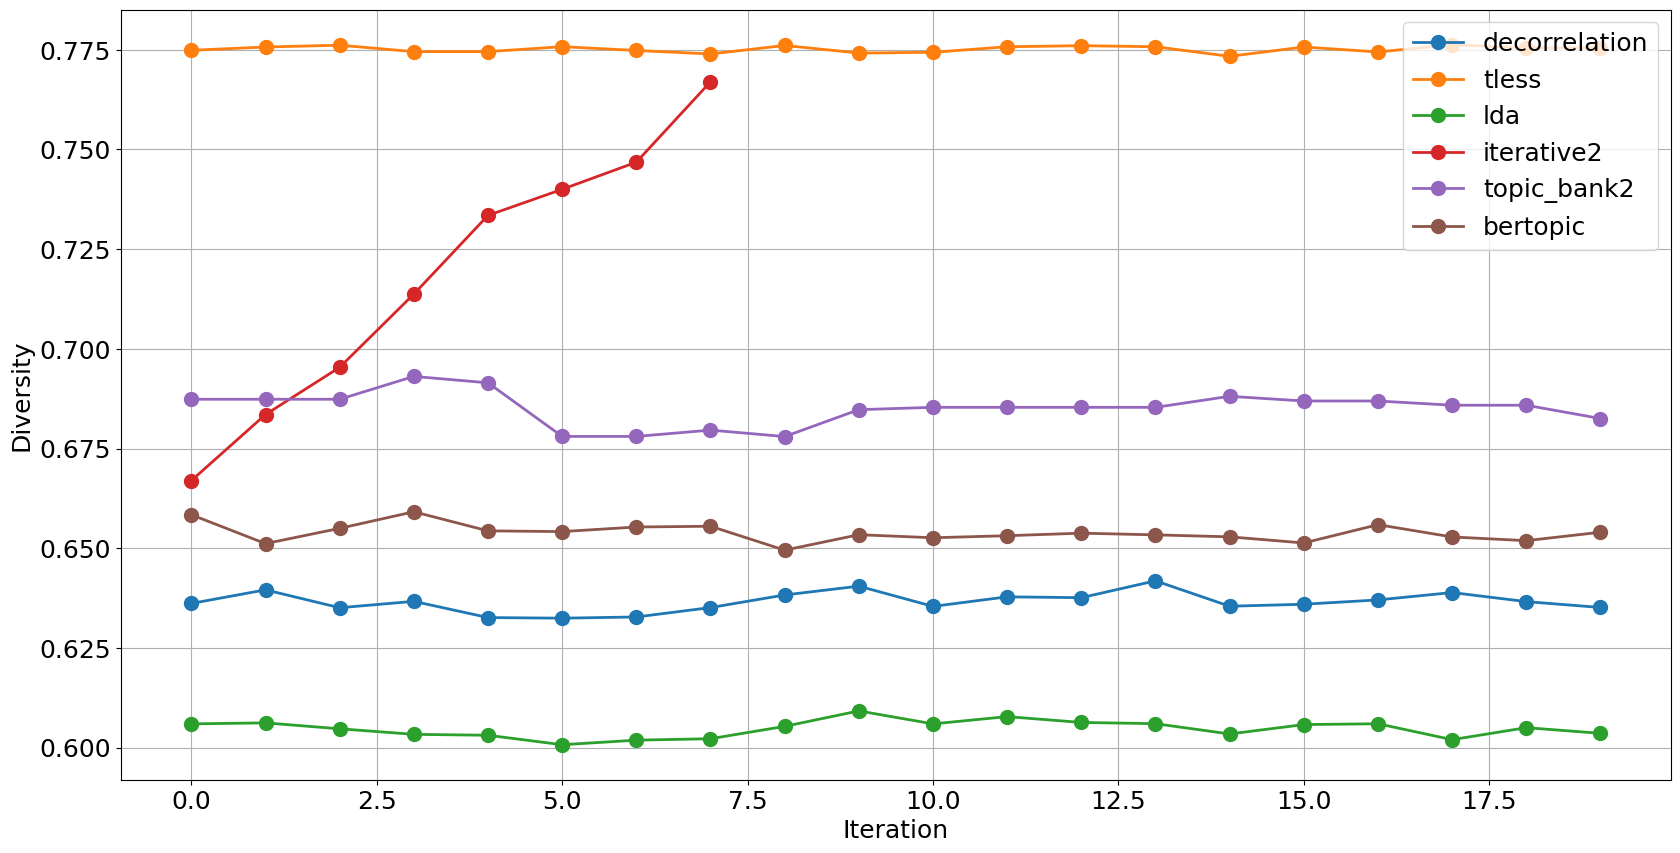

In [272]:
dataset = 'rtlwikiperson'
num_topics = 50
getter = get_diversities_js
ylabel = 'Diversity'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS2:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

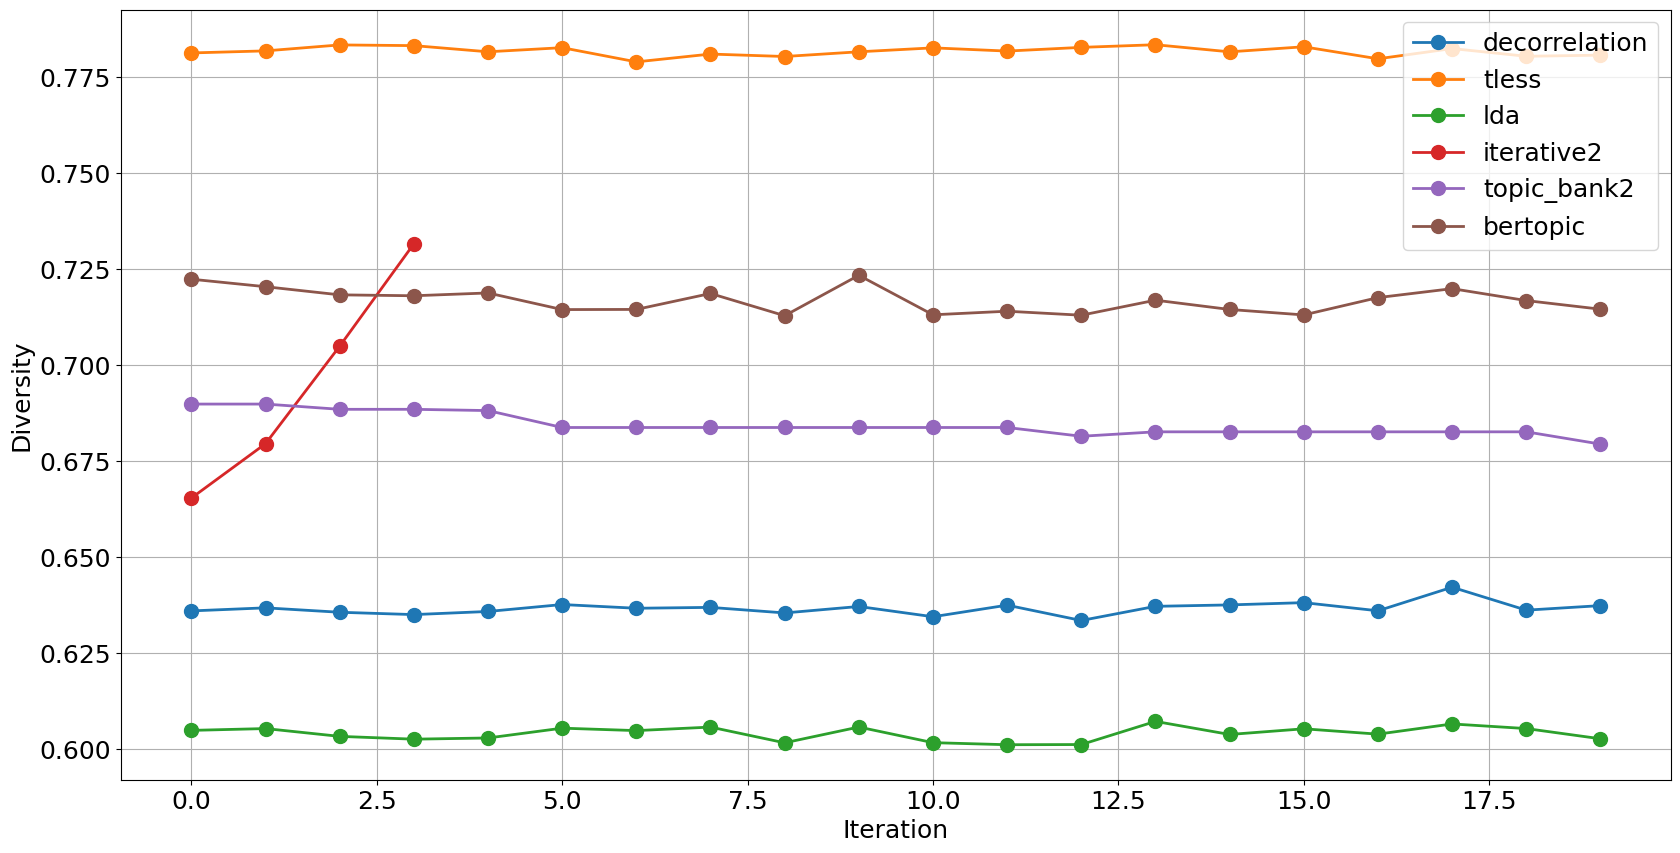

In [273]:
dataset = 'mkb10'
num_topics = 50
getter = get_diversities_js
ylabel = 'Diversity'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS2:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

In [57]:
MAX_NUM_ITERS = 20


def plot_one(
        num_topics, dataset, model, ax,
        getter=get_num_good_topics_percents,
        ylabel='Percentage of good topics',
        xlabel='Iteration',
        label=None,
        color=None,
        dx=None
        ):
    x, y = getter(num_topics, dataset, model)

    if label is None:
        label = model

    if 'iterative' in model or 'topic_bank' in model:
        ax.plot(x, y, lw=LINEWIDTH, marker='.', ms=MARKERSIZE, color=color, label=label)
    else:
        assert dx is not None

        x = [xi + dx for xi in x]

        for i, (xi, yi) in enumerate(zip(x, y)):
            if i == 0:
                cur_label = label
            else:
                cur_label = None

            ax.vlines(xi, ymin=0, ymax=yi, lw=LINEWIDTH, color=color, label=cur_label)
            ax.plot([xi], [yi], marker='.', ms=MARKERSIZE, color=color)
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    xticks = [xi for xi in range(MAX_NUM_ITERS) if xi % 2 == 0]
    ax.set_xticks(xticks)

    # ax.grid()
    # ax.legend()

In [58]:
MODELS

['plsa',
 'sparse',
 'decorrelation',
 'tless',
 'lda',
 'iterative',
 'iterative2',
 'topic_bank',
 'topic_bank2',
 'bertopic']

In [59]:
# Iterative additive regularization
# itera
# itaru
# itade
# itaddive
# itadive
# itadive
# itarla
# iterla
# itadiz
# itadra
# itaila
# itera
# itadra

# iterative -> iteradive
# additive -> itaddive

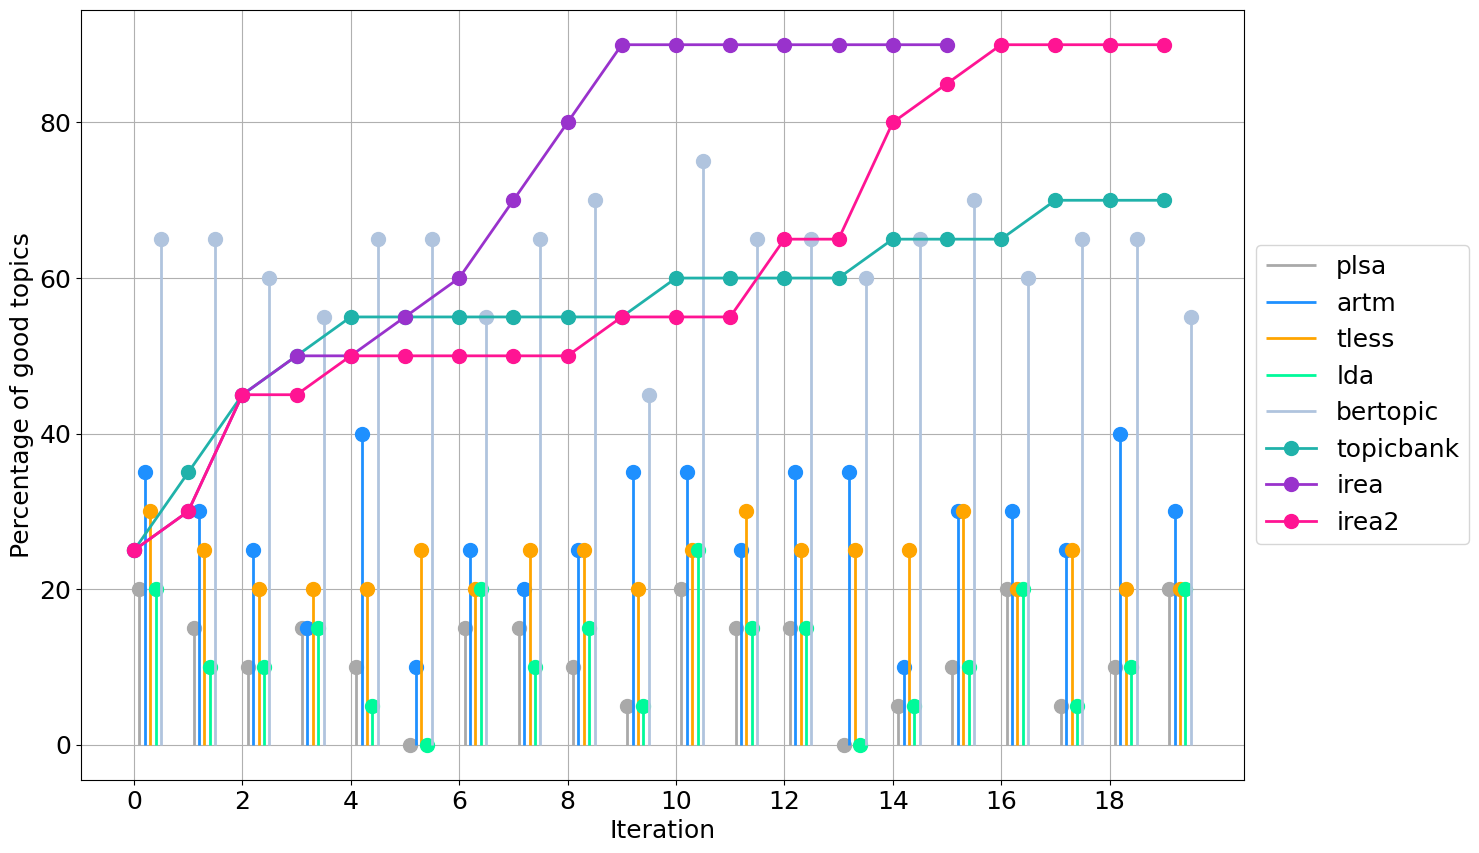

In [60]:
fig, ax = plt.subplots(figsize=(15, 10))

num_topics = 20
dataset = 'postnauka'

plot_one(num_topics, dataset, 'plsa', ax, dx=0.1, color='darkgrey')
plot_one(num_topics, dataset, 'decorrelation', ax, dx=0.2, color='dodgerblue', label='artm')
plot_one(num_topics, dataset, 'tless', ax, color='orange', dx=0.3)
plot_one(num_topics, dataset, 'lda', ax, color='mediumspringgreen', dx=0.4)
plot_one(num_topics, dataset, 'bertopic', ax, dx=0.5, color='lightsteelblue')

plot_one(num_topics, dataset, 'topic_bank2', ax, color='lightseagreen', label='topicbank')

plot_one(num_topics, dataset, 'iterative', ax, color='darkorchid', label='irea')
plot_one(num_topics, dataset, 'iterative2', ax, color='deeppink', label='irea2')

ax.grid()
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))  # https://stackoverflow.com/questions/4700614/how-to-put-the-legend-outside-the-plot

plt.show()

In [78]:
def plot_many(num_topics, dataset, ax):
    plot_one(num_topics, dataset, 'plsa',
             ax, dx=0.1, color='darkgrey')
    plot_one(num_topics, dataset, 'decorrelation',
             ax, dx=0.2, color='dodgerblue', label='decorr')  # label='artm')  # TODO: this is fuck-up
    # plot_one(num_topics, dataset, 'sparse',
    #          ax, dx=0.2, color='dodgerblue', label='sparse')  # label='artm')
    plot_one(num_topics, dataset, 'tless',
             ax, dx=0.3, color='orange')
    plot_one(num_topics, dataset, 'lda',
             ax, dx=0.4, color='mediumspringgreen')
    plot_one(num_topics, dataset, 'bertopic', 
             ax, dx=0.5, color='lightsteelblue')

    # plot_one(num_topics, dataset, 'topic_bank',
    #          ax, color='lightseagreen', label='topicbank1')
    plot_one(num_topics, dataset, 'topic_bank2',
             ax, color='lightseagreen', label='topicbank2')
    
    plot_one(num_topics, dataset, 'iterative',
             ax, color='darkorchid', label='itar')  # 'irea')
    plot_one(num_topics, dataset, 'iterative2',
             ax, color='deeppink', label='itar2')

    ax.grid()
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))  # https://stackoverflow.com/questions/4700614/how-to-put-the-legend-outside-the-plot

In [121]:
# With sparse
def plot_many(num_topics, dataset, ax):
    plot_one(num_topics, dataset, 'plsa',
             ax, dx=0.0, color='darkgrey')
    
    # plot_one(num_topics, dataset, 'decorrelation',  # pink lightcoral aquamarine mintcream mistyrose lightsalmon
    #          ax, dx=0.1, color='plum', label='decorr')  # label='artm')  # TODO: this is fuck-up
    # plot_one(num_topics, dataset, 'sparse',
    #          ax, dx=0.2, color='dodgerblue', label='sparse')  # label='artm')

    plot_one(num_topics, dataset, 'sparse',  # pink lightcoral aquamarine mintcream mistyrose lightsalmon
             ax, dx=0.1, color='plum', label='sparse')  # label='artm')  # TODO: this is fuck-up
    plot_one(num_topics, dataset, 'decorrelation',
             ax, dx=0.2, color='dodgerblue', label='decorr')  # label='artm')

    plot_one(num_topics, dataset, 'tless',
             ax, dx=0.3, color='orange')
    plot_one(num_topics, dataset, 'lda',
             ax, dx=0.4, color='mediumspringgreen')
    plot_one(num_topics, dataset, 'bertopic', 
             ax, dx=0.5, color='lightsteelblue')

    # plot_one(num_topics, dataset, 'topic_bank',
    #          ax, color='lightseagreen', label='topicbank1')
    plot_one(num_topics, dataset, 'topic_bank2',
             ax, color='lightseagreen', label='topicbank2')
    
    plot_one(num_topics, dataset, 'iterative',
             ax, color='darkorchid', label='itar')  # 'irea')
    plot_one(num_topics, dataset, 'iterative2',
             ax, color='deeppink', label='itar2')

    ax.grid()
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))  # https://stackoverflow.com/questions/4700614/how-to-put-the-legend-outside-the-plot

In [62]:
FIGSIZE = (15, 10)

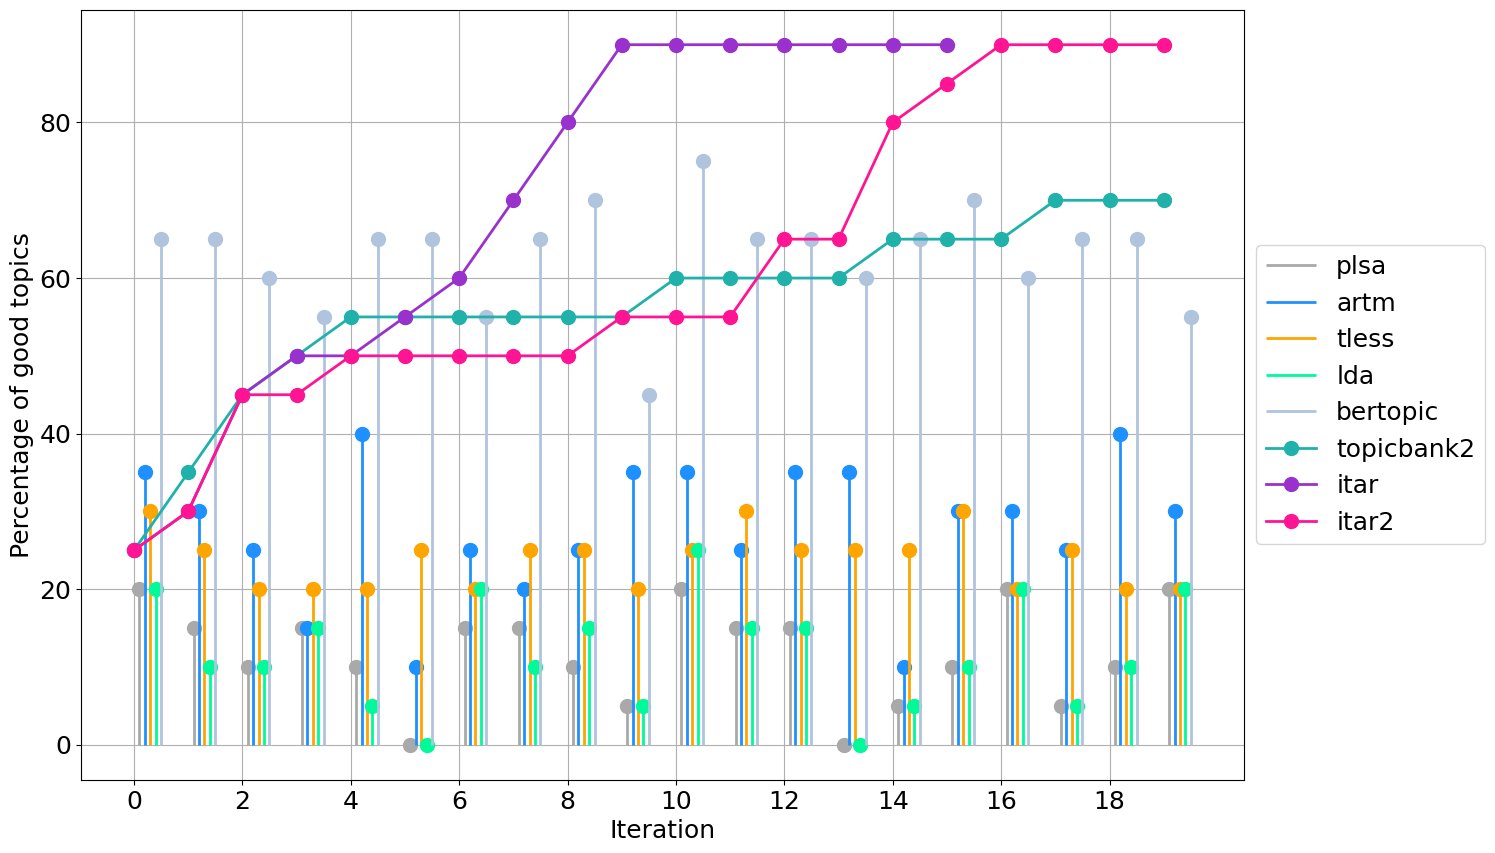

In [63]:
fig, ax = plt.subplots(figsize=FIGSIZE)

num_topics = 20
dataset = 'postnauka'

plot_many(num_topics, dataset, ax)

plt.show()

In [64]:
get_nums_good_topics(20, 'postnauka', 'topic_bank2')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [5, 7, 9, 10, 11, 11, 11, 11, 11, 11, 12, 12, 12, 12, 13, 13, 13, 14, 14, 14])

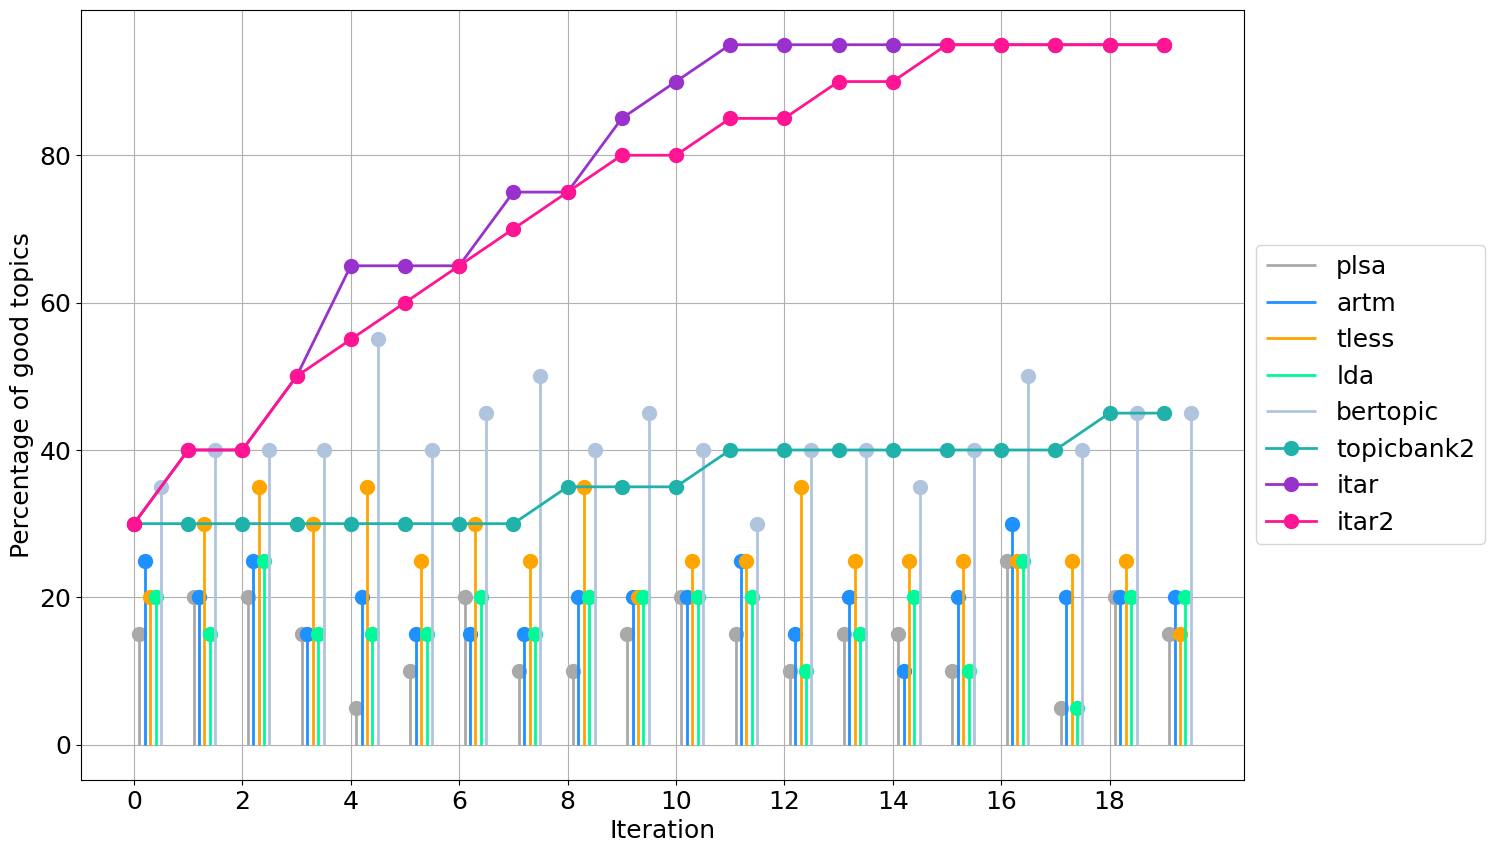

In [65]:
fig, ax = plt.subplots(figsize=FIGSIZE)

num_topics = 20
dataset = '20newsgroups'

plot_many(num_topics, dataset, ax)

plt.show()

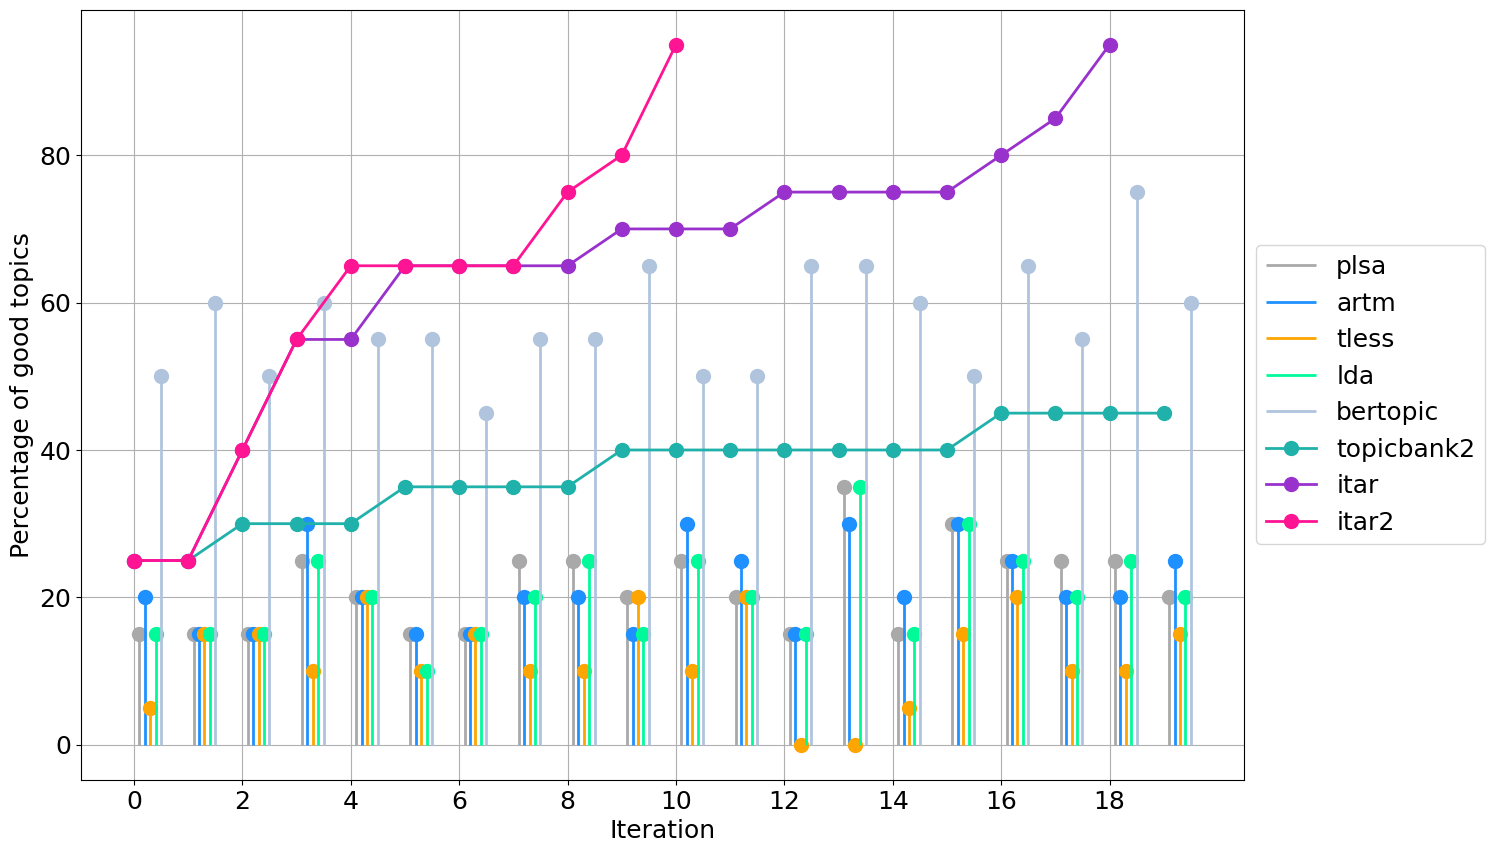

In [66]:
fig, ax = plt.subplots(figsize=FIGSIZE)

num_topics = 20
dataset = 'ruwikigood'

plot_many(num_topics, dataset, ax)

plt.show()

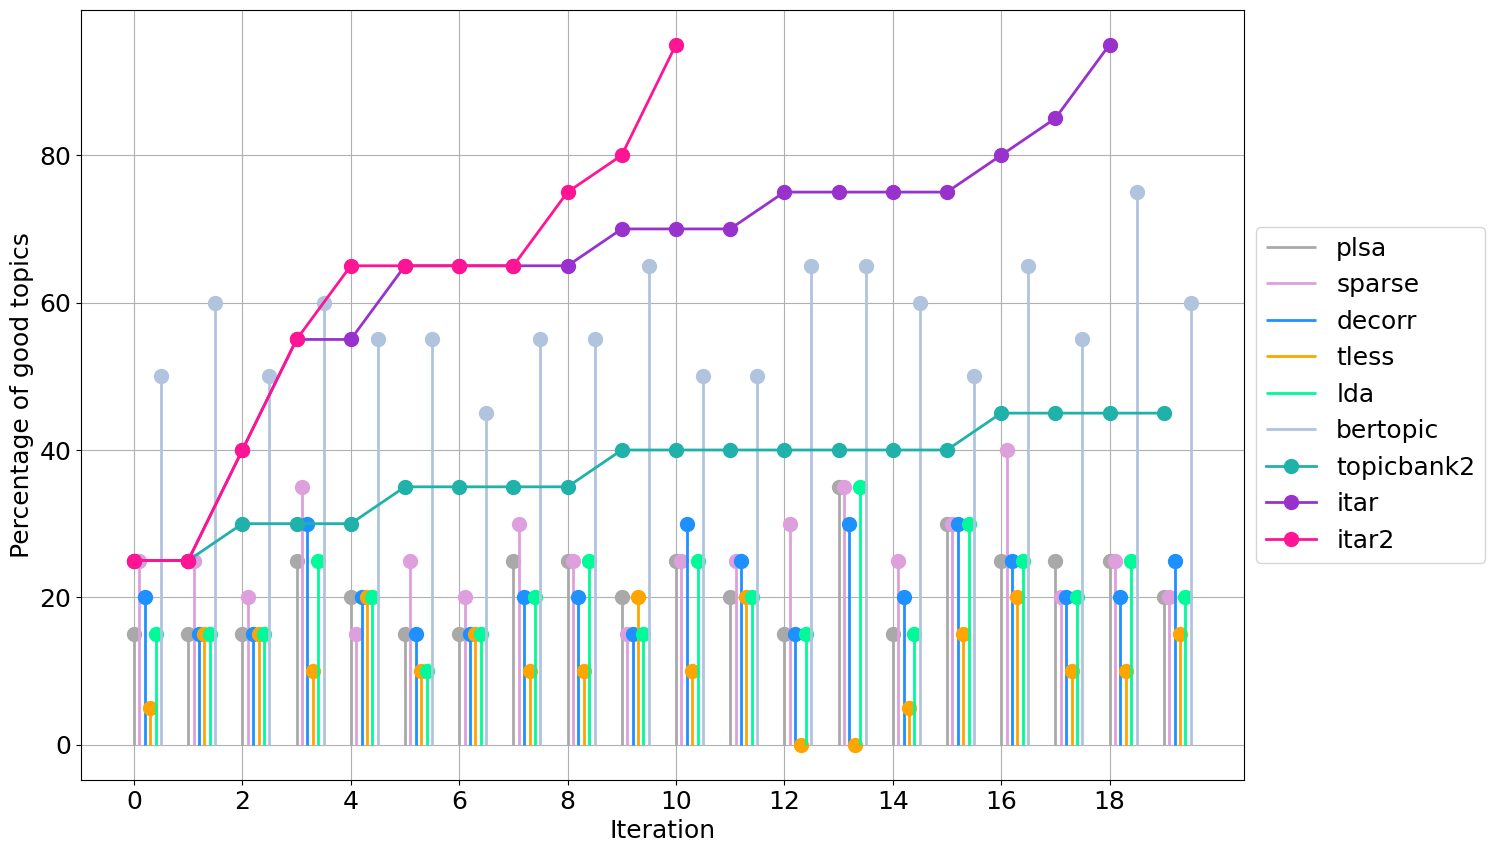

In [117]:
fig, ax = plt.subplots(figsize=FIGSIZE)

num_topics = 20
dataset = 'ruwikigood'

plot_many(num_topics, dataset, ax)

# https://stackoverflow.com/a/24535532/8094251
# plt.axis('off')
# plt.gca().set_position([0, 0, 1, 1])

# https://stackoverflow.com/a/13707849/8094251
plt.savefig('ruwikigood-tt-t20.svg', bbox_inches='tight', pad_inches=0)

plt.show()

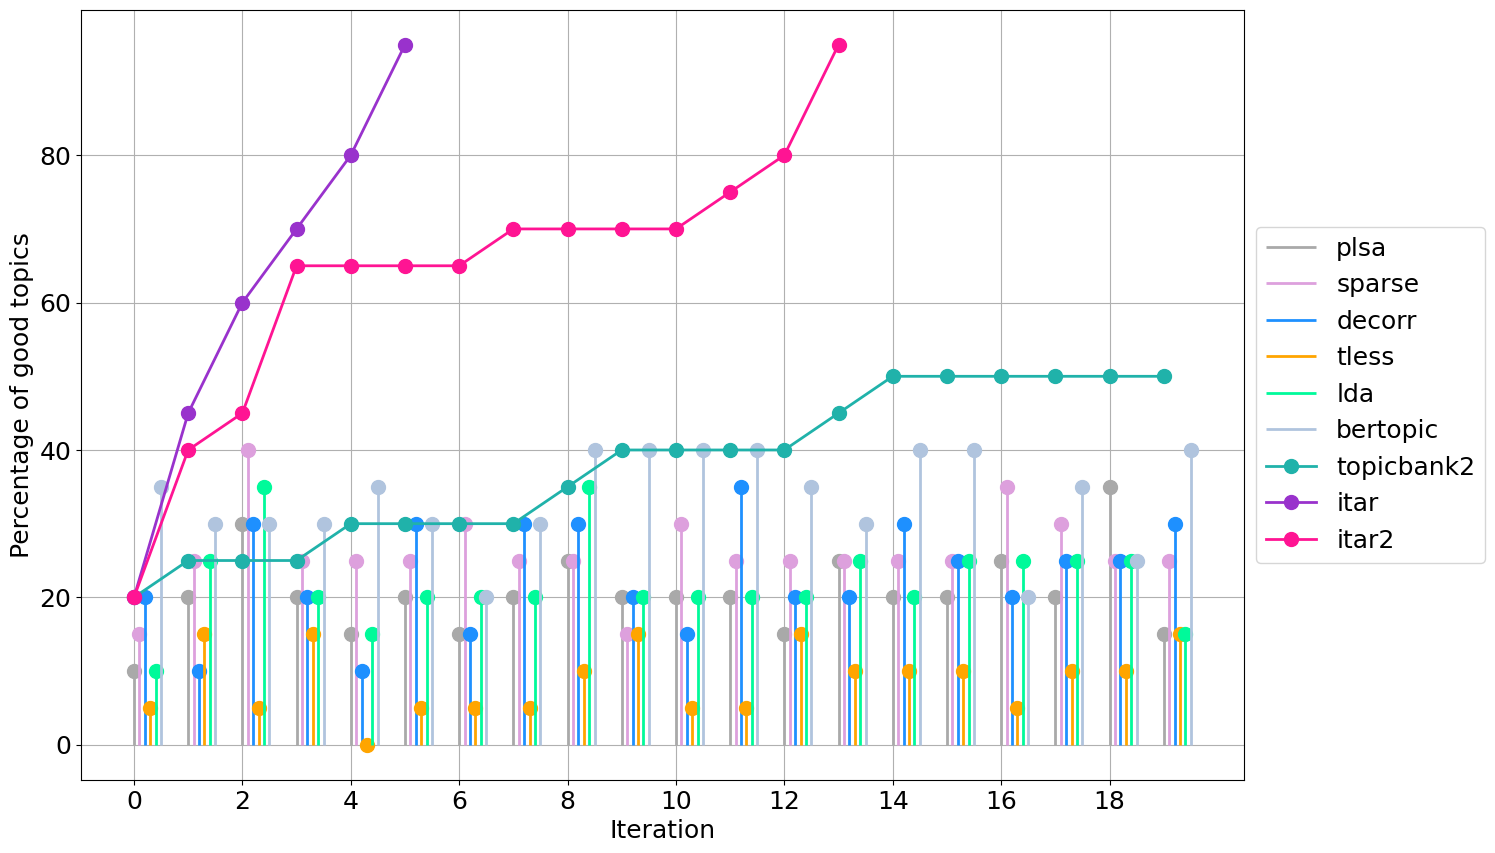

In [118]:
fig, ax = plt.subplots(figsize=FIGSIZE)

num_topics = 20
dataset = 'rtlwikiperson'

plot_many(num_topics, dataset, ax)

plt.savefig('rtlwikiperson-tt-t20.svg', bbox_inches='tight', pad_inches=0)

plt.show()

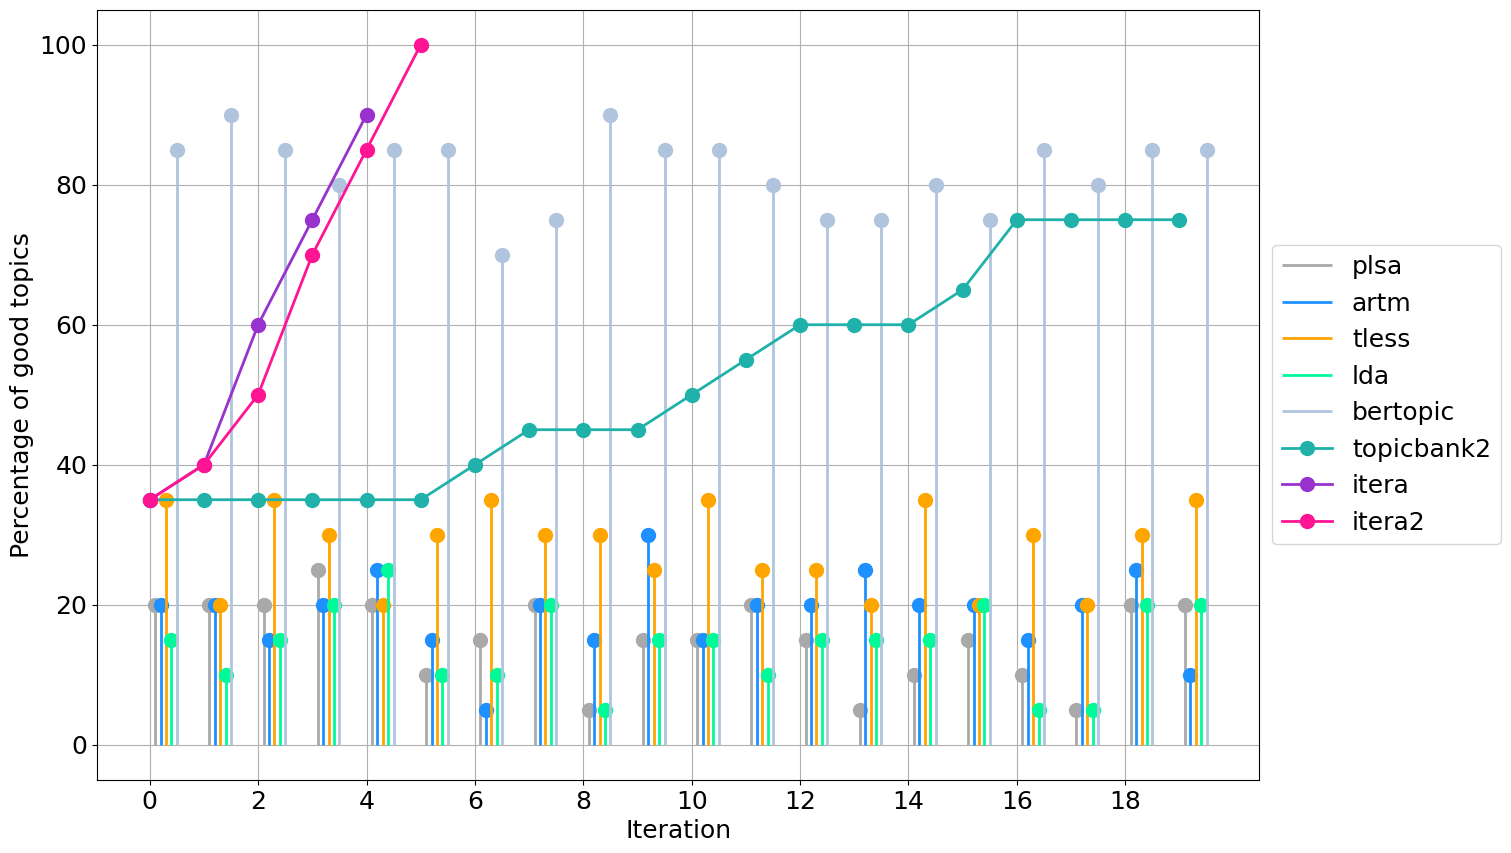

In [546]:
fig, ax = plt.subplots(figsize=FIGSIZE)

num_topics = 20
dataset = 'mkb10'

plot_many(num_topics, dataset, ax)

plt.show()

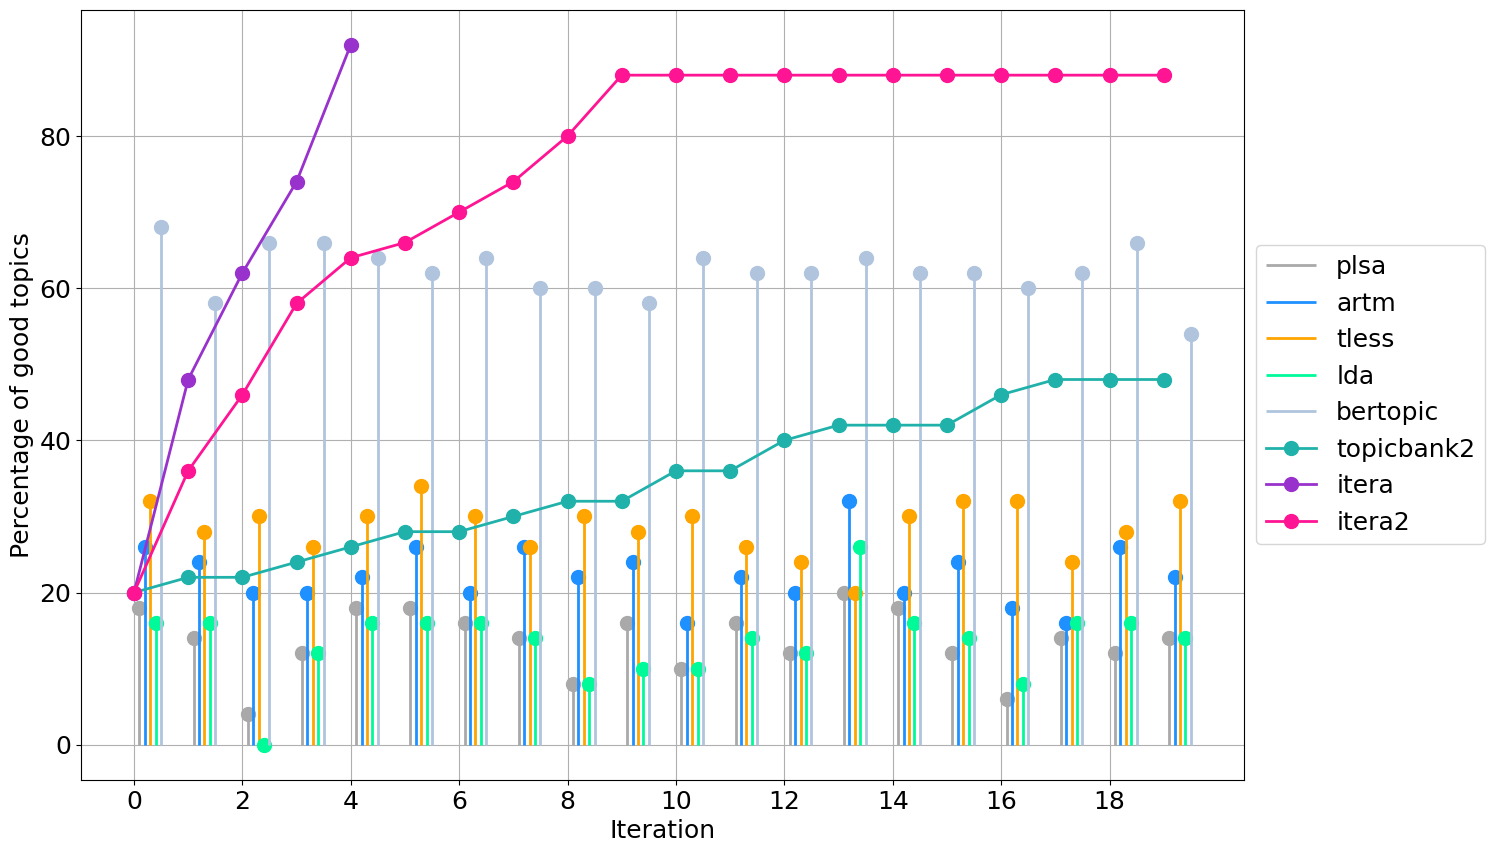

In [547]:
fig, ax = plt.subplots(figsize=FIGSIZE)

num_topics = 50
dataset = 'postnauka'

plot_many(num_topics, dataset, ax)

plt.show()

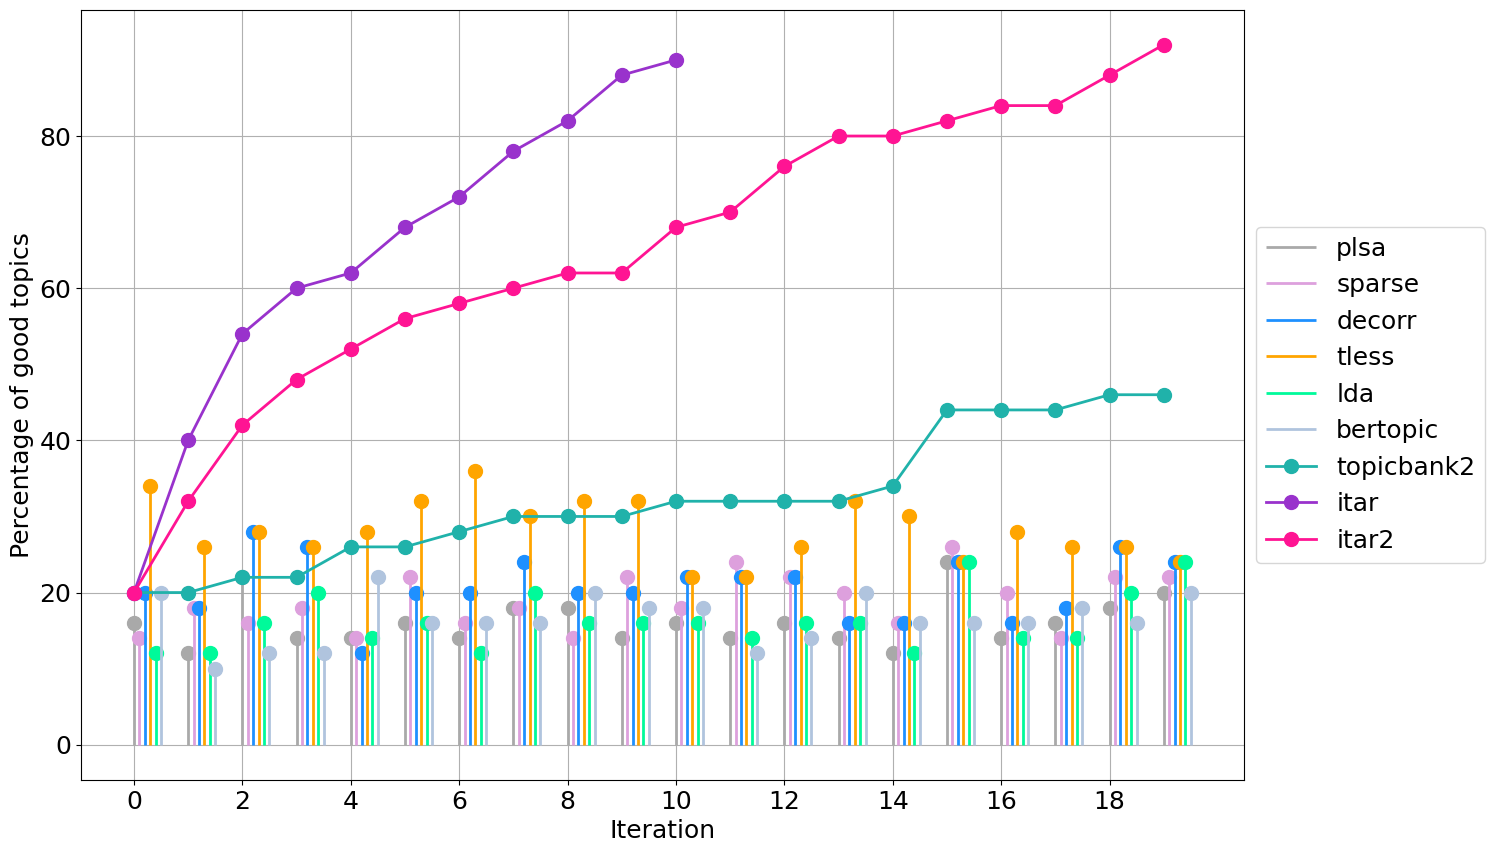

In [119]:
fig, ax = plt.subplots(figsize=FIGSIZE)

num_topics = 50
dataset = '20newsgroups'

plot_many(num_topics, dataset, ax)

plt.savefig('20newsgroups-tt-t50.svg', bbox_inches='tight', pad_inches=0)

plt.show()

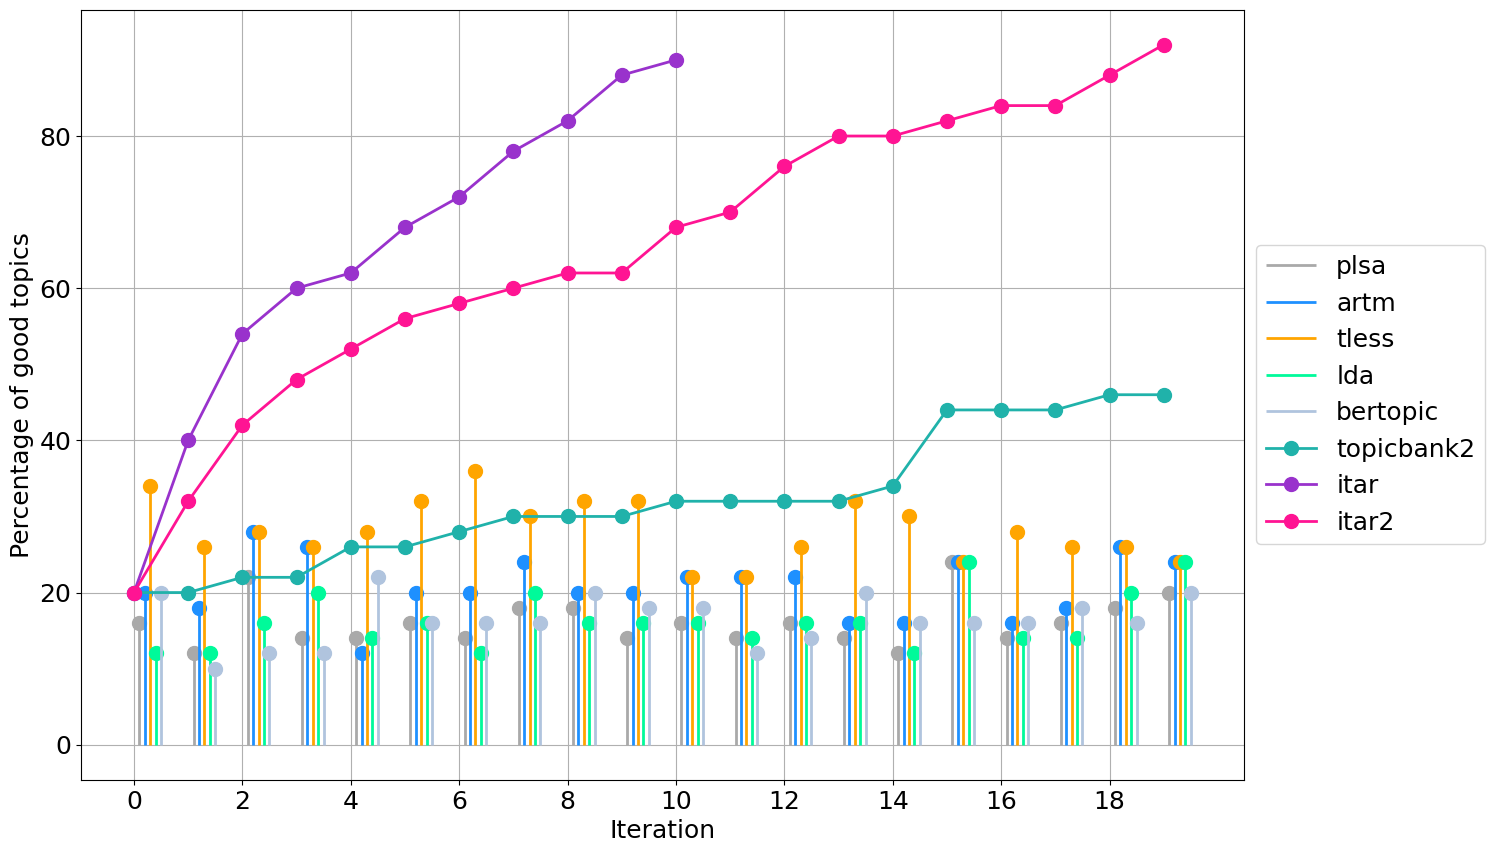

In [77]:
fig, ax = plt.subplots(figsize=FIGSIZE)

num_topics = 50
dataset = '20newsgroups'

plot_many(num_topics, dataset, ax)

plt.show()

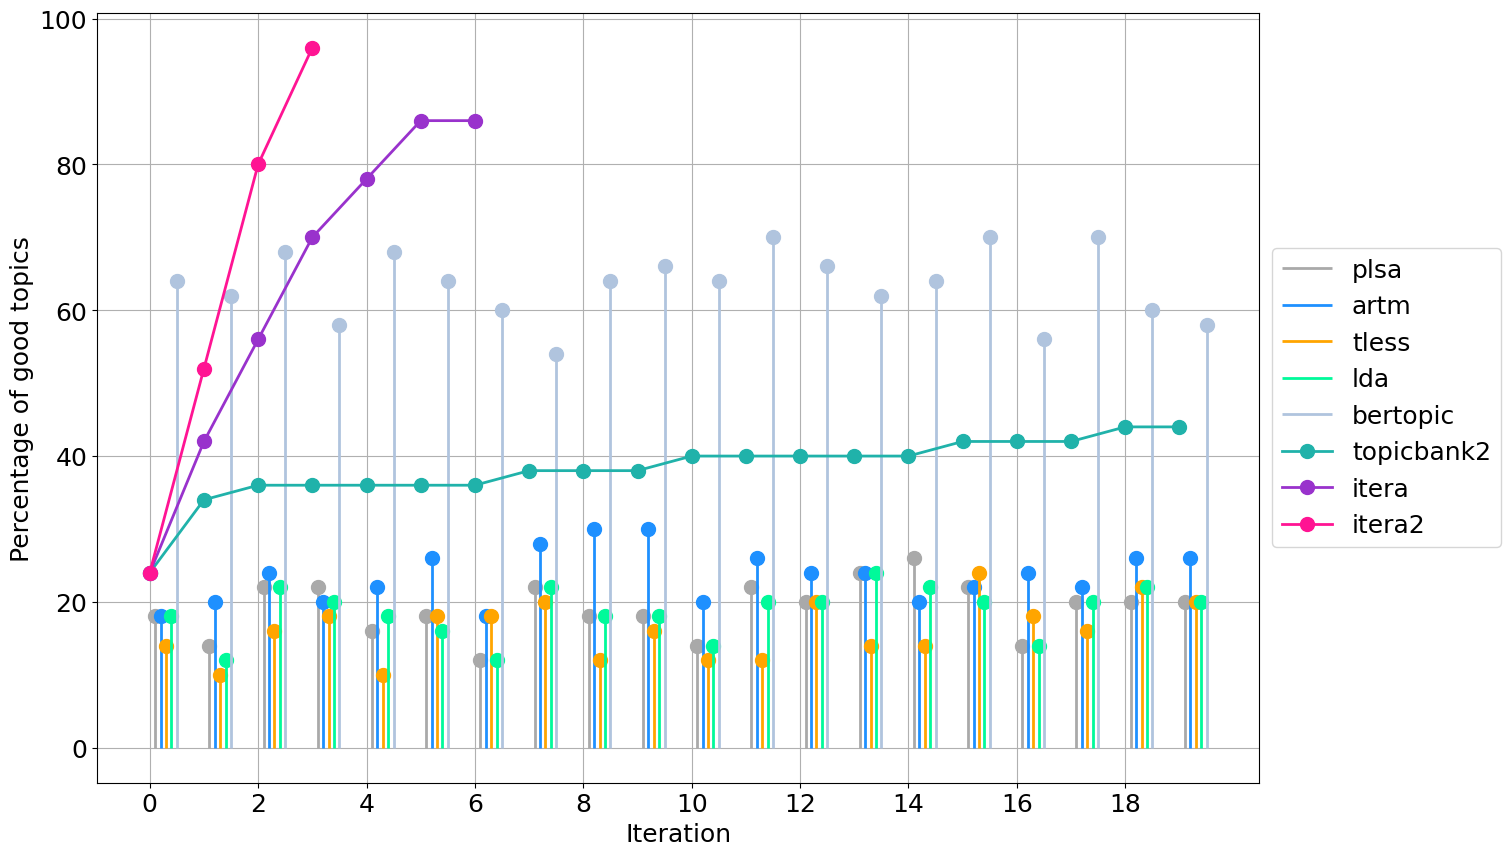

In [549]:
fig, ax = plt.subplots(figsize=FIGSIZE)

num_topics = 50
dataset = 'ruwikigood'

plot_many(num_topics, dataset, ax)

plt.show()

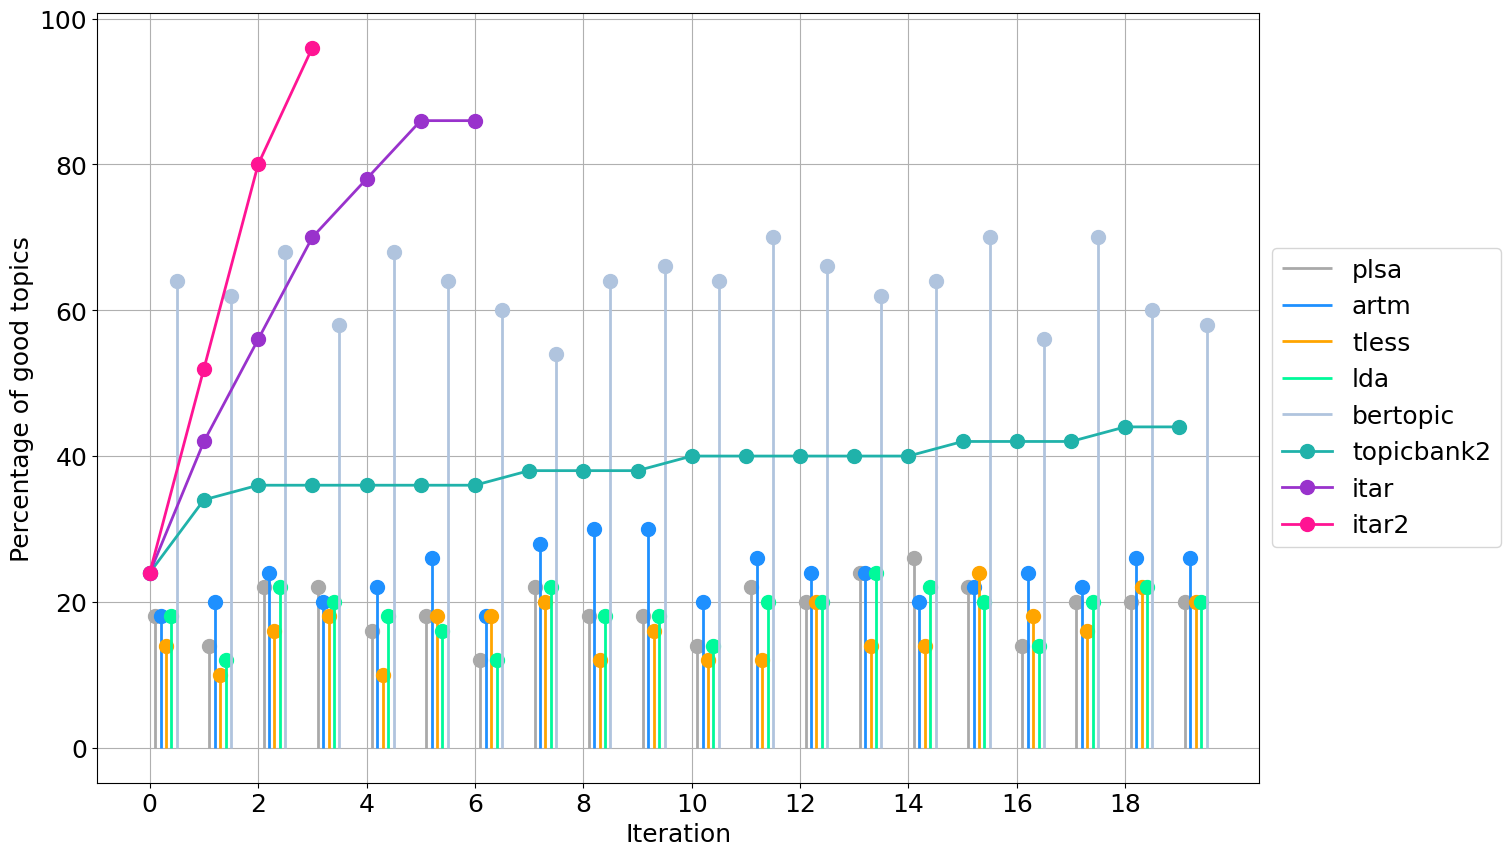

In [78]:
fig, ax = plt.subplots(figsize=FIGSIZE)

num_topics = 50
dataset = 'ruwikigood'

plot_many(num_topics, dataset, ax)

plt.show()

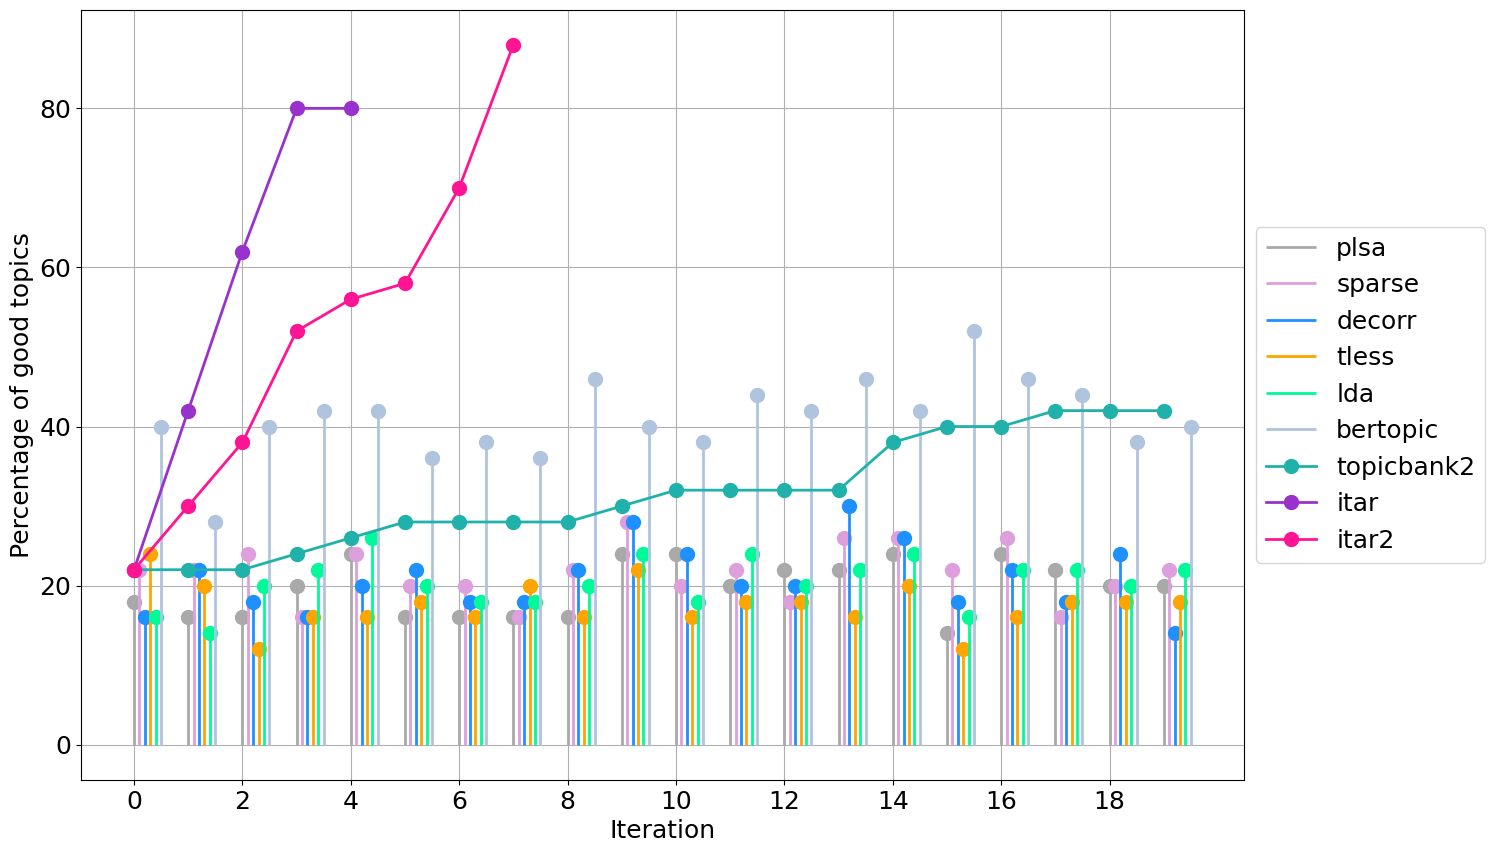

In [120]:
fig, ax = plt.subplots(figsize=FIGSIZE)

num_topics = 50
dataset = 'rtlwikiperson'

plot_many(num_topics, dataset, ax)

plt.savefig('rtlwikiperson-tt-t50.svg', bbox_inches='tight', pad_inches=0)

plt.show()

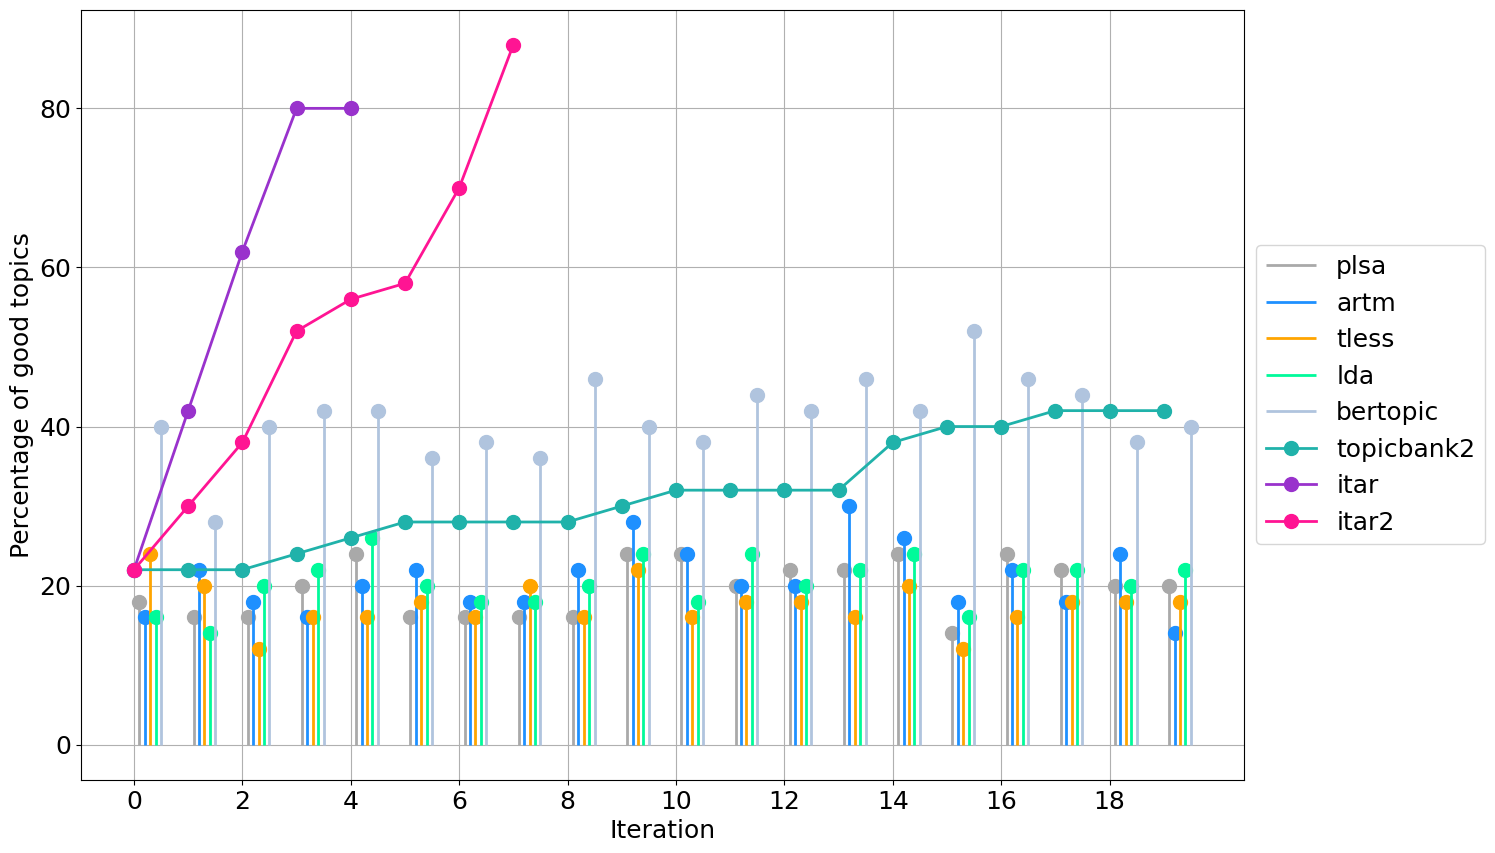

In [79]:
fig, ax = plt.subplots(figsize=FIGSIZE)

num_topics = 50
dataset = 'rtlwikiperson'

plot_many(num_topics, dataset, ax)

plt.show()

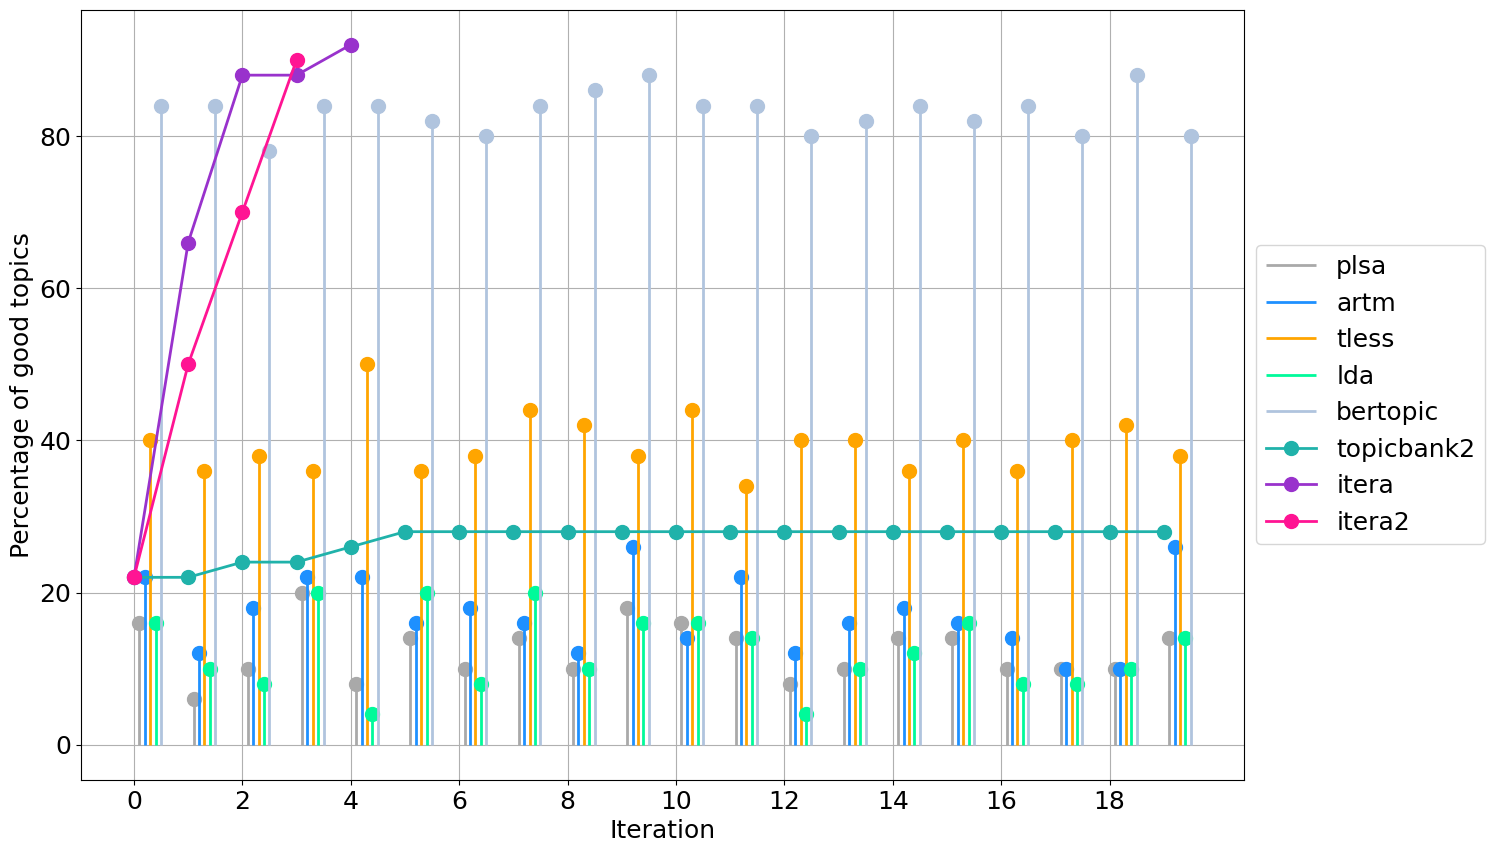

In [552]:
fig, ax = plt.subplots(figsize=FIGSIZE)

num_topics = 50
dataset = 'mkb10'

plot_many(num_topics, dataset, ax)

plt.show()

In [276]:
RESULTS[20]['postnauka']['bertopic']['iters'][0]  # fair_ppl_fix, fair_ppl_free

{'scores': {'perplexity': 5831.353515625,
  'coherence_20': 1.1895922630550457,
  'diversity_euclidean': 0.05643315561647891,
  'diversity_jensenshannon': 0.6586868390442192,
  'diversity_hellinger': 0.7723483311822211,
  'diversity_cosine': 0.7665362134060419,
  'fair_ppl_free': 4104.3720703125,
  'fair_ppl_fix': 5732.21533203125,
  'unfair_ppl_banklike': 5831.353515625},
 'topic_coherences': {'0': 0.2569302406409139,
  '1': 0.3773557156995919,
  '2': 0.4151826271267152,
  '3': 0.869048069861531,
  '4': 0.34707651257947725,
  '5': 1.1344835564004891,
  '6': 0.7381468059844702,
  '7': 1.868370712245547,
  '8': 2.2936935649937964,
  '9': 0.8091636348624217,
  '10': 2.7444844015225542,
  '11': 1.5617199764971843,
  '12': 1.7821392306432786,
  '13': 1.0615351667879558,
  '14': 0.9731558747867508,
  '15': 0.9624011546092153,
  '16': 1.27555822215827,
  '17': 1.7640648985938334,
  '18': 1.0001747009957196,
  '19': 1.5571601941111977},
 'stats': {'num_topics': 21,
  'num_common_words': 82061

In [277]:
RESULTS[20]['postnauka']['topic_bank']['iters'][0]  # ppl_fair, ppl_cheatty

{'scores': {'perplexity_score': 27600.54296875,
  'coherence_20': 1.1177666958123678,
  'diversity_euclidean': 0.04971374671297815,
  'diversity_jensenshannon': 0.5967539527734701,
  'diversity_hellinger': 0.6922578888429283,
  'diversity_cosine': 0.746649317119927,
  'perplexity': 27600.54296875,
  'ppl_fair': 27600.54296875,
  'ppl_cheatty': 4970.97119140625},
 'topic_coherences': {'0': 1.054240465084224, '1': 1.1812929265405114},
 'num_topics': 2}

In [285]:
def fix_comma(num):
    num = str(num)
    num = num.replace('.', ',')

    return num

In [553]:
# Print results

print(
    'num_topics', 'dataset', 'model',
    'best iter',
    'perplexity', 'coherence', 'good topics percent',
    'diversity (js)', 'diversity (cos)',
    sep=';'
)
print()

for num_topics in NUM_TOPICS:
    for dataset in DATASETS:
        for model in MODELS:
            # print(num_topics, dataset, model)
            args = (num_topics, dataset, model)
            best_iter = get_best_iter(*args)

            if 'topic_bank' in model:
                _, perplexities_fair = get_perplexities(*args, key='ppl_fair')
                _, perplexities_cheatty = get_perplexities(*args, key='ppl_cheatty')
            elif 'bertopic' in model:
                _, perplexities_fair = get_perplexities(*args, key='fair_ppl_fix')
                _, perplexities_cheatty = get_perplexities(*args, key='fair_ppl_free')
            else:
                _, perplexities_fair = get_perplexities(*args)
                perplexities_cheatty = None

            _, coherences = get_coherences(*args)
            _, num_good_topics_percents = get_num_good_topics_percents(*args)
            _, diversities1 = get_diversities_js(*args)
            _, diversities2 = get_diversities_cos(*args)

            fair_perplexity = perplexities_fair[best_iter]
            cheatty_perplexity = perplexities_cheatty[best_iter] if perplexities_cheatty is not None else None

            if cheatty_perplexity is not None:
                output_perplexity = f'{fix_comma(cheatty_perplexity)}/{fix_comma(fair_perplexity)}'
            else:
                output_perplexity = f'{fix_comma(fair_perplexity)}'
    
            print(
                num_topics, dataset, model,
                best_iter,
                output_perplexity,
                fix_comma(coherences[best_iter]),
                fix_comma(num_good_topics_percents[best_iter]),
                fix_comma(diversities1[best_iter]),
                fix_comma(diversities2[best_iter]),
                sep=';',
            )

        print()

    print()
    print()

num_topics;dataset;model;best iter;perplexity;coherence;good topics percent;diversity (js);diversity (cos)

20;postnauka;plsa;10;2988,05126953125;0,7408603471731607;20,0;0,5986744129431701;0,7105316333323761
20;postnauka;sparse;16;3331,627197265625;0,8373267207241961;40,0;0,6577500464333056;0,7851606474262377
20;postnauka;decorrelation;4;3145,260009765625;0,7947895337616694;40,0;0,6110164241510098;0,7471875697343083
20;postnauka;tless;11;3650,03955078125;0,7459731514128226;30,0;0,7480707735802806;0,9296706063716923
20;postnauka;lda;10;2993,387939453125;0,7306867394980877;25,0;0,5750718834429737;0,7014743414744589
20;postnauka;iterative;9;3768,777587890625;1,0343057880943956;90,0;0,7558091983433141;0,920824740453037
20;postnauka;iterative2;16;3744,9453125;1,031423194411716;90,0;0,747166463451224;0,9138393068609006
20;postnauka;topic_bank;16;4331,3974609375/6798,5283203125;0,9935164476710492;30,0;0,6040854257925821;0,745615640340426
20;postnauka;topic_bank2;17;4115,84912109375/8111,39111

In [563]:
# Print results 2

#        Dataset1                           Dataset2
# model1 best_iter ppl coh good_p div1 div2 ...
# model2 ...

# print(
#     'num_topics', 'dataset', 'model',
#     'best iter',
#     'perplexity', 'coherence', 'good topics percent',
#     'diversity (js)', 'diversity (cos)',
#     sep=';'
# )
# print()

for num_topics in NUM_TOPICS:
    title_row = ['Model']
    post_title_row = ['Model']
    model_rows = dict()
    
    for dataset in DATASETS:
        for i, model in enumerate(MODELS):

            if model not in model_rows:
                model_rows[model] = [model]

            # print(num_topics, dataset, model)
            args = (num_topics, dataset, model)
            best_iter = get_best_iter(*args)

            if 'topic_bank' in model:
                _, perplexities_fair = get_perplexities(*args, key='ppl_fair')
                _, perplexities_cheatty = get_perplexities(*args, key='ppl_cheatty')
            elif 'bertopic' in model:
                _, perplexities_fair = get_perplexities(*args, key='fair_ppl_fix')
                _, perplexities_cheatty = get_perplexities(*args, key='fair_ppl_free')
            else:
                _, perplexities_fair = get_perplexities(*args)
                perplexities_cheatty = None

            _, coherences = get_coherences(*args)
            _, num_good_topics_percents = get_num_good_topics_percents(*args)
            _, diversities1 = get_diversities_js(*args)
            _, diversities2 = get_diversities_cos(*args)

            fair_perplexity = perplexities_fair[best_iter]
            cheatty_perplexity = perplexities_cheatty[best_iter] if perplexities_cheatty is not None else None

            if cheatty_perplexity is not None:
                output_perplexity = f'{fix_comma(cheatty_perplexity)}/{fix_comma(fair_perplexity)}'
            else:
                output_perplexity = f'{fix_comma(fair_perplexity)}'

            new_model_data = [
                str(best_iter),
                output_perplexity,
                fix_comma(coherences[best_iter]),
                fix_comma(num_good_topics_percents[best_iter]),
                fix_comma(diversities1[best_iter]),
                fix_comma(diversities2[best_iter]),
            ]
            model_rows[model].extend(new_model_data)

            if i == 0:
                title_row.extend(
                    [dataset] * len(new_model_data)
                )
                post_title_row.extend(
                    ['Best iter', 'Ppl', 'Coh', 'Good %', 'Div js', 'Div cos']
                )

    print(';'.join(title_row))
    print(';'.join(post_title_row))

    for r in model_rows.values():
        print(';'.join(r))

    print()
    print()

Model;postnauka;postnauka;postnauka;postnauka;postnauka;postnauka;20newsgroups;20newsgroups;20newsgroups;20newsgroups;20newsgroups;20newsgroups;ruwikigood;ruwikigood;ruwikigood;ruwikigood;ruwikigood;ruwikigood;rtlwikiperson;rtlwikiperson;rtlwikiperson;rtlwikiperson;rtlwikiperson;rtlwikiperson;mkb10;mkb10;mkb10;mkb10;mkb10;mkb10
Model;Best iter;Ppl;Coh;Good %;Div js;Div cos;Best iter;Ppl;Coh;Good %;Div js;Div cos;Best iter;Ppl;Coh;Good %;Div js;Div cos;Best iter;Ppl;Coh;Good %;Div js;Div cos;Best iter;Ppl;Coh;Good %;Div js;Div cos
plsa;10;2988,05126953125;0,7408603471731607;20,0;0,5986744129431701;0,7105316333323761;16;2043,85400390625;1,2265302305378185;25,0;0,6638702126497449;0,75024556576849;13;4324,6826171875;0,7359962099875734;35,0;0,6285401481391092;0,8078584390812545;18;3486,576171875;0,638236477710352;35,0;0,5941606869437732;0,7492409721646852;3;2158,900390625;0,6188199121004773;25,0;0,6057370967628858;0,70239322133864
sparse;16;3331,627197265625;0,8373267207241961;40,0;0,657750

In [566]:
# Print results 3 (fixed for itar)

#        Dataset1                           Dataset2
# model1 best_iter ppl coh good_p div1 div2 ...
# model2 ...

# print(
#     'num_topics', 'dataset', 'model',
#     'best iter',
#     'perplexity', 'coherence', 'good topics percent',
#     'diversity (js)', 'diversity (cos)',
#     sep=';'
# )
# print()

for num_topics in NUM_TOPICS:
    title_row = ['Model']
    post_title_row = ['Model']
    model_rows = dict()
    
    for dataset in DATASETS:
        for i, model in enumerate(MODELS):

            if model not in model_rows:
                model_rows[model] = [model]

            # print(num_topics, dataset, model)
            args = (num_topics, dataset, model)
            best_iter = get_best_iter_fair_itar(*args)  # CHANGE HERE

            if 'topic_bank' in model:
                _, perplexities_fair = get_perplexities(*args, key='ppl_fair')
                _, perplexities_cheatty = get_perplexities(*args, key='ppl_cheatty')
            elif 'bertopic' in model:
                _, perplexities_fair = get_perplexities(*args, key='fair_ppl_fix')
                _, perplexities_cheatty = get_perplexities(*args, key='fair_ppl_free')
            else:
                _, perplexities_fair = get_perplexities(*args)
                perplexities_cheatty = None

            _, coherences = get_coherences(*args)
            _, num_good_topics_percents = get_num_good_topics_percents(*args)
            _, diversities1 = get_diversities_js(*args)
            _, diversities2 = get_diversities_cos(*args)

            fair_perplexity = perplexities_fair[best_iter]
            cheatty_perplexity = perplexities_cheatty[best_iter] if perplexities_cheatty is not None else None

            if cheatty_perplexity is not None:
                output_perplexity = f'{fix_comma(cheatty_perplexity)}/{fix_comma(fair_perplexity)}'
            else:
                output_perplexity = f'{fix_comma(fair_perplexity)}'

            new_model_data = [
                str(best_iter),
                output_perplexity,
                fix_comma(coherences[best_iter]),
                fix_comma(num_good_topics_percents[best_iter]),
                fix_comma(diversities1[best_iter]),
                fix_comma(diversities2[best_iter]),
            ]
            model_rows[model].extend(new_model_data)

            if i == 0:
                title_row.extend(
                    [dataset] * len(new_model_data)
                )
                post_title_row.extend(
                    ['Best iter', 'Ppl', 'Coh', 'Good %', 'Div js', 'Div cos']
                )

    print(';'.join(title_row))
    print(';'.join(post_title_row))

    for r in model_rows.values():
        print(';'.join(r))

    print()
    print()

Model;postnauka;postnauka;postnauka;postnauka;postnauka;postnauka;20newsgroups;20newsgroups;20newsgroups;20newsgroups;20newsgroups;20newsgroups;ruwikigood;ruwikigood;ruwikigood;ruwikigood;ruwikigood;ruwikigood;rtlwikiperson;rtlwikiperson;rtlwikiperson;rtlwikiperson;rtlwikiperson;rtlwikiperson;mkb10;mkb10;mkb10;mkb10;mkb10;mkb10
Model;Best iter;Ppl;Coh;Good %;Div js;Div cos;Best iter;Ppl;Coh;Good %;Div js;Div cos;Best iter;Ppl;Coh;Good %;Div js;Div cos;Best iter;Ppl;Coh;Good %;Div js;Div cos;Best iter;Ppl;Coh;Good %;Div js;Div cos
plsa;10;2988,05126953125;0,7408603471731607;20,0;0,5986744129431701;0,7105316333323761;16;2043,85400390625;1,2265302305378185;25,0;0,6638702126497449;0,75024556576849;13;4324,6826171875;0,7359962099875734;35,0;0,6285401481391092;0,8078584390812545;18;3486,576171875;0,638236477710352;35,0;0,5941606869437732;0,7492409721646852;3;2158,900390625;0,6188199121004773;25,0;0,6057370967628858;0,70239322133864
sparse;16;3331,627197265625;0,8373267207241961;40,0;0,657750

## Ablation Study

In [45]:
! ls results/postnauka/ablation_study

iterative_100000_0-0-1.json  iterative2_100000000_0-0-1.json
iterative_100000_0-1-0.json  iterative2_100000000_0-1-0.json
iterative_100000_0-1-1.json  iterative2_100000000_0-1-1.json
iterative_100000_1-0-0.json  iterative2_100000000_1-0-0.json
iterative_100000_1-0-1.json  iterative2_100000000_1-0-1.json
iterative_100000_1-1-0.json  iterative2_100000000_1-1-0.json


In [152]:
! ls results/ruwikigood/ablation_study

iterative_10000000_1-0-0.json	    iterative2_100000000000_1-1-0.json
iterative_10000000_1-0-1.json	    iterative2_10000000000_1-0-0.json
iterative_10000000_1-1-0.json	    iterative2_10000000000_1-0-1.json
iterative_1000000_1-0-0.json	    iterative2_10000000000_1-1-0.json
iterative_1000000_1-0-1.json	    iterative2_1000000000_1-0-0.json
iterative_1000000_1-1-0.json	    iterative2_1000000000_1-0-1.json
iterative2_100000000000_1-0-0.json  iterative2_1000000000_1-1-0.json
iterative2_100000000000_1-0-1.json


In [188]:
ABLATION_SUFFIXES = [
    '0-0-1',
    '0-1-0',
    '0-1-1',
    '1-0-0',
    '1-0-1',
    '1-1-0',
]

ABLATION_MODELS = [
    f'iterative_{s}' for s in ABLATION_SUFFIXES
] + [
    f'iterative2_{s}' for s in ABLATION_SUFFIXES
]

In [189]:
ABLATION_MODELS

['iterative_0-0-1',
 'iterative_0-1-0',
 'iterative_0-1-1',
 'iterative_1-0-0',
 'iterative_1-0-1',
 'iterative_1-1-0',
 'iterative2_0-0-1',
 'iterative2_0-1-0',
 'iterative2_0-1-1',
 'iterative2_1-0-0',
 'iterative2_1-0-1',
 'iterative2_1-1-0']

In [342]:
# Load

for num_topics in NUM_TOPICS:
    if num_topics == 20:
        results_folder = RESULTS_FOLDER_PREFIX
    else:
        results_folder = f'{RESULTS_FOLDER_PREFIX}{num_topics}'

    for dataset in DATASETS:
        dataset_folder = os.path.join(results_folder, dataset)

        for model in MODELS:
            if 'iterative' not in model:
                continue

            for ablation_suffix in ABLATION_SUFFIXES:
                ablation_model = f'{model}_{ablation_suffix}'
    
                if model == 'iterative':
                    tau = DATASET_BEST_ITER_TAUS[dataset]
                    model_file_name = f'{model}_{tau}_{ablation_suffix}.json'
                elif model == 'iterative2':
                    tau = DATASET_BEST_ITER2_TAUS[dataset]
                    model_file_name = f'{model}_{tau}_{ablation_suffix}.json'
                else:
                    assert False
    
                model_file_path = os.path.join(dataset_folder, 'ablation_study', model_file_name)
                
                # assert os.path.isfile(model_file_path), (model, model_file_path)

                if not os.path.isfile(model_file_path):
                    if not ablation_suffix.startswith('0'):
                        wow = '!!! '
                    else:
                        wow = ''

                    print(f'{wow}Ablation model file "{model_file_path}" not found.')

                    continue
    
                model_results = json.loads(
                    open(model_file_path).read()
                )

                RESULTS[num_topics][dataset][ablation_model] = dict()
                RESULTS[num_topics][dataset][ablation_model]['iters'] = model_results

Ablation model file "results/20newsgroups/ablation_study/iterative_100000_0-0-1.json" not found.
Ablation model file "results/20newsgroups/ablation_study/iterative_100000_0-1-0.json" not found.
Ablation model file "results/20newsgroups/ablation_study/iterative_100000_0-1-1.json" not found.
Ablation model file "results/20newsgroups/ablation_study/iterative2_100000000_0-0-1.json" not found.
Ablation model file "results/20newsgroups/ablation_study/iterative2_100000000_0-1-0.json" not found.
Ablation model file "results/20newsgroups/ablation_study/iterative2_100000000_0-1-1.json" not found.
Ablation model file "results/ruwikigood/ablation_study/iterative_1000000_0-0-1.json" not found.
Ablation model file "results/ruwikigood/ablation_study/iterative_1000000_0-1-0.json" not found.
Ablation model file "results/ruwikigood/ablation_study/iterative_1000000_0-1-1.json" not found.
Ablation model file "results/ruwikigood/ablation_study/iterative2_10000000000_0-0-1.json" not found.
Ablation model fi

In [158]:
! ls results/20newsgroups/

ablation_study		      iterative_100.json	  plsa.json
bertopic		      iterative2_1000000000.json  plsa_with_cohs.json
bertopic.json		      iterative2_100000000.json   sparse.json
decorrelation.json	      iterative2_10000000.json	  sparse_with_cohs.json
decorrelation_with_cohs.json  iterative2_1000000.json	  tless.json
iterative_1000000.json	      iterative2_100000.json	  tless_with_cohs.json
iterative_100000.json	      lda.json
iterative_1000.json	      lda_with_cohs.json


In [157]:
! ls results/20newsgroups/ablation_study iterative_100000_1-0-0.json

iterative_1000000_0-0-1.json  iterative2_1000000000_0-0-1.json
iterative_1000000_0-1-0.json  iterative2_1000000000_0-1-0.json
iterative_1000000_0-1-1.json  iterative2_1000000000_0-1-1.json
iterative_1000000_1-0-0.json  iterative2_1000000000_1-0-0.json
iterative_1000000_1-0-1.json  iterative2_1000000000_1-0-1.json
iterative_1000000_1-1-0.json  iterative2_1000000000_1-1-0.json
iterative_1000_0-0-1.json     iterative2_1000000_0-0-1.json
iterative_1000_0-1-0.json     iterative2_1000000_0-1-0.json
iterative_1000_0-1-1.json     iterative2_1000000_0-1-1.json
iterative_1000_1-0-0.json     iterative2_1000000_1-0-0.json
iterative_1000_1-0-1.json     iterative2_1000000_1-0-1.json
iterative_1000_1-1-0.json     iterative2_1000000_1-1-0.json


In [163]:
RESULTS[50]['postnauka'].keys()

dict_keys(['plsa', 'sparse', 'decorrelation', 'tless', 'lda', 'iterative', 'iterative2', 'topic_bank', 'topic_bank2', 'bertopic', 'iterative_1-0-0', 'iterative_1-0-1', 'iterative_1-1-0', 'iterative2_1-0-0', 'iterative2_1-0-1', 'iterative2_1-1-0'])

In [168]:
RESULTS[50]['ruwikigood'].keys()

dict_keys(['plsa', 'sparse', 'decorrelation', 'tless', 'lda', 'iterative', 'iterative2', 'topic_bank', 'topic_bank2', 'bertopic', 'iterative_1-0-0', 'iterative_1-0-1', 'iterative_1-1-0', 'iterative2_1-0-0', 'iterative2_1-0-1', 'iterative2_1-1-0'])

In [172]:
RESULTS[50]['ruwikigood']['iterative_1-0-0']

{'iters': [{'scores': {'perplexity': 3852.895751953125,
    'coherence_20': 0.8379379408786964,
    'diversity_euclidean': 0.06397843454152567,
    'diversity_jensenshannon': 0.6863121149167829,
    'diversity_hellinger': 0.7944175477024618,
    'diversity_cosine': 0.8779651667609615},
   'topic_coherences': {'0': 0.49276397315294374,
    '1': 0.5300724395909,
    '2': 0.5241179986693785,
    '3': 0.8172811429987601,
    '4': 0.944455245379202,
    '5': 0.7291560918642296,
    '6': 0.9719096514914711,
    '7': 0.8072878515248041,
    '8': 0.4721653029506616,
    '9': 0.9722573493118218,
    '10': 1.0241618350841246,
    '11': 0.7953704258557894,
    '12': 0.900454464447445,
    '13': 0.7858409597959674,
    '14': 0.8236123126853039,
    '15': 1.1346554409868477,
    '16': 1.19553789401,
    '17': 0.8144937994648158,
    '18': 1.0052884713379007,
    '19': 0.47640413492520245,
    '20': 1.1084635326719952,
    '21': 0.5292938165800074,
    '22': 0.7580281395587566,
    '23': 1.000234851

In [176]:
get_best_iter(50, 'ruwikigood', 'iterative_1-0-0')

18

In [177]:
get_perplexities(50, 'ruwikigood', 'iterative_1-0-0')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [3852.895751953125,
  3927.2236328125,
  4044.90234375,
  4022.001708984375,
  4094.404052734375,
  4104.34619140625,
  4185.1083984375,
  4159.10400390625,
  4197.8291015625,
  4232.60107421875,
  4193.1943359375,
  4223.93359375,
  4268.3974609375,
  4260.44677734375,
  4230.25732421875,
  4263.82177734375,
  4288.94677734375,
  4286.5634765625,
  4304.69091796875,
  4287.01953125])

In [178]:
get_nums_good_topics(50, 'ruwikigood', 'iterative_1-0-0')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [12,
  18,
  19,
  23,
  25,
  26,
  28,
  29,
  30,
  31,
  31,
  32,
  32,
  32,
  33,
  34,
  34,
  34,
  34,
  34])

In [164]:
! ls results50/ruwikigood/ablation_study

iterative_1000000_1-0-0       iterative2_10000000000_1-0-0
iterative_1000000_1-0-0.json  iterative2_10000000000_1-0-0.json
iterative_1000000_1-0-1       iterative2_10000000000_1-0-1
iterative_1000000_1-0-1.json  iterative2_10000000000_1-0-1.json
iterative_1000000_1-1-0       iterative2_10000000000_1-1-0
iterative_1000000_1-1-0.json  iterative2_10000000000_1-1-0.json


In [165]:
DATASET_BEST_ITER2_TAUS

{'postnauka': 100000000,
 '20newsgroups': 100000000,
 'ruwikigood': 10000000000,
 'rtlwikiperson': 1000000000,
 'mkb10': 100000000}

In [312]:
def get_total_num_bad_topics(num_topics, dataset, model):
    # TODO: DRY (get nums good)
    model_results = RESULTS[num_topics][dataset][model]
    model_iters = model_results['iters']
    bad_coherence_threshold = DATASET_BAD_COHERENCE_THRESHOLDS[num_topics][dataset]

    iters = []
    nums_bad_topics = []

    for i, iter in enumerate(model_iters):
        cur_num_bad_topics = sum([
            1 if c <= bad_coherence_threshold else 0
            for _, c in iter['topic_coherences'].items()
        ])

        if 'iterative' in model:
            assert cur_num_bad_topics == iter['num_topics']['bad'], (cur_num_good_topics, model_results['num_topics']['bad'])

        if len(nums_bad_topics) > 0:
            cur_total_num_bad_topics = cur_num_bad_topics + nums_bad_topics[-1]
        else:
            cur_total_num_bad_topics = cur_num_bad_topics

        if 'iterative' in model:
            assert cur_total_num_bad_topics == iter['num_topics']['total_bad'], (cur_total_num_bad_topics, iter['num_topics'], num_topics, dataset, model)

        nums_bad_topics.append(cur_total_num_bad_topics)
        iters.append(i)

    return iters, nums_bad_topics

# iter -- speed of convergence


def get_total_num_bad_topics_percents(num_topics, dataset, model):
    iters, nums_good_topics = get_total_num_bad_topics(num_topics, dataset, model)

    return iters, [
        n / num_topics * 100 for n in nums_good_topics
    ]

In [183]:
get_total_num_bad_topics(20, 'postnauka', 'iterative_1-0-0')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [2, 5, 8, 10, 13, 15, 17, 21, 24, 27, 30, 32, 32, 34, 36, 38, 40, 42, 44, 46])

In [184]:
get_total_num_bad_topics(20, 'postnauka', 'iterative_1-1-0')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [2, 4, 7, 8, 10, 11, 13, 14, 15, 16, 18, 19, 19, 19, 19, 19, 19, 19, 19, 19])

In [185]:
get_total_num_bad_topics(20, 'postnauka', 'iterative_1-0-1')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [2, 4, 7, 8, 11, 12, 14, 17, 19, 21, 24, 26, 26, 28, 30, 33, 35, 36, 38, 40])

In [558]:
# Print results

NUM_ITERS = 20

print(
    'num_topics', 'dataset', 'model',
    'best iter', 'speed',
    'perplexity', 'coherence', 'good topics percent', 'total bad topics percent',
    'diversity (js)', 'diversity (cos)',
    sep=';'
)
print()

for num_topics in NUM_TOPICS:
    for dataset in DATASETS:
        for model in ['iterative', 'iterative2'] + ABLATION_MODELS:
            if model not in RESULTS[num_topics][dataset]:
                continue

            # print(num_topics, dataset, model)
            args = (num_topics, dataset, model)
            best_iter = get_best_iter(*args)

            if 'iterative' not in model:
                continue

            _, perplexities_fair = get_perplexities(*args)
            _, coherences = get_coherences(*args)
            _, num_good_topics_percents = get_num_good_topics_percents(*args)

            try:
                _, total_num_bad_topics_percents = get_total_num_bad_topics_percents(*args)
            except AssertionError as e:
                # print('!!! Error:', model, e)
                raise e
                
                continue

            _, diversities1 = get_diversities_js(*args)
            _, diversities2 = get_diversities_cos(*args)

            speed = (best_iter + 1) / NUM_ITERS

            fair_perplexity = perplexities_fair[best_iter]
            output_perplexity = f'{fix_comma(fair_perplexity)}'

            output_bad_percent = fix_comma(total_num_bad_topics_percents[best_iter]) if total_num_bad_topics_percents is not None else ' '
    
            print(
                num_topics, dataset, model,
                best_iter,
                fix_comma(speed),
                output_perplexity,
                fix_comma(coherences[best_iter]),
                fix_comma(num_good_topics_percents[best_iter]),
                output_bad_percent,
                fix_comma(diversities1[best_iter]),
                fix_comma(diversities2[best_iter]),
                sep=';',
            )

        print()

    print()
    print()

num_topics;dataset;model;best iter;speed;perplexity;coherence;good topics percent;total bad topics percent;diversity (js);diversity (cos)

20;postnauka;iterative;9;0,5;3768,777587890625;1,0343057880943956;90,0;85,0;0,7558091983433141;0,920824740453037
20;postnauka;iterative2;16;0,85;3744,9453125;1,031423194411716;90,0;90,0;0,747166463451224;0,9138393068609006
20;postnauka;iterative_0-0-1;16;0,85;3290,923583984375;0,8364911061437105;40,0;235,0;0,6573779411073711;0,7872134101763645
20;postnauka;iterative_0-1-0;11;0,6;3299,12646484375;0,9094880157105966;65,0;190,0;0,679458552254437;0,8322656824743193
20;postnauka;iterative_0-1-1;16;0,85;3313,63525390625;0,9296006876876601;55,00000000000001;260,0;0,691050930528491;0,842213014528583
20;postnauka;iterative_1-0-0;13;0,7;3572,05859375;0,9089278384079863;60,0;170,0;0,6954299011408135;0,8455494627542739
20;postnauka;iterative_1-0-1;17;0,9;3659,9638671875;0,9537835473164884;75,0;180,0;0,717599273487288;0,876667231033221
20;postnauka;iterative_1-1

In [561]:
# Print results 2

#        Dataset1                           Dataset2
# model1 best_iter ppl coh good_p div1 div2 ...
# model2 ...

# print(
#     'num_topics', 'dataset', 'model',
#     'best iter',
#     'perplexity', 'coherence', 'good topics percent',
#     'diversity (js)', 'diversity (cos)',
#     sep=';'
# )
# print()

for num_topics in NUM_TOPICS:
    title_row = ['Model']
    post_title_row = ['Model']
    model_rows = dict()
    
    for dataset in DATASETS:
        for i, model in enumerate(['iterative', 'iterative2'] + ABLATION_MODELS):
            if 'iterative' not in model:
                continue

            if model not in model_rows:
                model_rows[model] = [model]
            
            if model not in RESULTS[num_topics][dataset]:
                model_rows[model].extend(['NA'] * len(new_model_data))  # TODO: dirty

                continue

            # print(num_topics, dataset, model)
            args = (num_topics, dataset, model)
            best_iter = get_best_iter(*args)

            _, perplexities_fair = get_perplexities(*args)
            _, coherences = get_coherences(*args)
            _, num_good_topics_percents = get_num_good_topics_percents(*args)

            try:
                _, total_num_bad_topics_percents = get_total_num_bad_topics_percents(*args)
            except AssertionError as e:
                # print('!!! Error:', model, e)
                raise e
                
                continue

            _, diversities1 = get_diversities_js(*args)
            _, diversities2 = get_diversities_cos(*args)

            speed = (best_iter + 1) / NUM_ITERS

            fair_perplexity = perplexities_fair[best_iter]
            output_perplexity = f'{fix_comma(fair_perplexity)}'

            output_bad_percent = fix_comma(total_num_bad_topics_percents[best_iter]) if total_num_bad_topics_percents is not None else ' '
    
            new_model_data = [
                str(best_iter),
                fix_comma(speed),
                output_perplexity,
                fix_comma(coherences[best_iter]),
                fix_comma(num_good_topics_percents[best_iter]),
                output_bad_percent,
                fix_comma(diversities1[best_iter]),
                fix_comma(diversities2[best_iter]),
            ]

            model_rows[model].extend(new_model_data)

            if i == 0:
                title_row.extend(
                    [dataset] * len(new_model_data)
                )
                post_title_row.extend(
                    ['Best iter', 'Speed', 'Ppl', 'Coh', 'Good %', 'Bad %', 'Div js', 'Div cos']
                )

    print(';'.join(title_row))
    print(';'.join(post_title_row))

    for r in model_rows.values():
        print(';'.join(r))

    print()
    print()

Model;postnauka;postnauka;postnauka;postnauka;postnauka;postnauka;postnauka;postnauka;20newsgroups;20newsgroups;20newsgroups;20newsgroups;20newsgroups;20newsgroups;20newsgroups;20newsgroups;ruwikigood;ruwikigood;ruwikigood;ruwikigood;ruwikigood;ruwikigood;ruwikigood;ruwikigood;rtlwikiperson;rtlwikiperson;rtlwikiperson;rtlwikiperson;rtlwikiperson;rtlwikiperson;rtlwikiperson;rtlwikiperson;mkb10;mkb10;mkb10;mkb10;mkb10;mkb10;mkb10;mkb10
Model;Best iter;Speed;Ppl;Coh;Good %;Bad %;Div js;Div cos;Best iter;Speed;Ppl;Coh;Good %;Bad %;Div js;Div cos;Best iter;Speed;Ppl;Coh;Good %;Bad %;Div js;Div cos;Best iter;Speed;Ppl;Coh;Good %;Bad %;Div js;Div cos;Best iter;Speed;Ppl;Coh;Good %;Bad %;Div js;Div cos
iterative;9;0,5;3768,777587890625;1,0343057880943956;90,0;85,0;0,7558091983433141;0,920824740453037;11;0,6;2545,637451171875;1,8334542328772045;95,0;80,0;0,7574768302507697;0,9234124662992339;18;0,95;5484,72119140625;1,0236179923056614;95,0;140,0;0,7376052118185588;0,9288833090486716;5;0,3;4639,

In [565]:
# Print results 3 (fixed for itar)

#        Dataset1                           Dataset2
# model1 best_iter ppl coh good_p div1 div2 ...
# model2 ...

# print(
#     'num_topics', 'dataset', 'model',
#     'best iter',
#     'perplexity', 'coherence', 'good topics percent',
#     'diversity (js)', 'diversity (cos)',
#     sep=';'
# )
# print()

for num_topics in NUM_TOPICS:
    title_row = ['Model']
    post_title_row = ['Model']
    model_rows = dict()
    
    for dataset in DATASETS:
        for i, model in enumerate(['iterative', 'iterative2'] + ABLATION_MODELS):
            if 'iterative' not in model:
                continue

            if model not in model_rows:
                model_rows[model] = [model]
            
            if model not in RESULTS[num_topics][dataset]:
                model_rows[model].extend(['NA'] * len(new_model_data))  # TODO: dirty

                continue

            # print(num_topics, dataset, model)
            args = (num_topics, dataset, model)
            best_iter = get_best_iter_fair_itar(*args)  # CHANGE HERE

            _, perplexities_fair = get_perplexities(*args)
            _, coherences = get_coherences(*args)
            _, num_good_topics_percents = get_num_good_topics_percents(*args)

            try:
                _, total_num_bad_topics_percents = get_total_num_bad_topics_percents(*args)
            except AssertionError as e:
                # print('!!! Error:', model, e)
                raise e
                
                continue

            _, diversities1 = get_diversities_js(*args)
            _, diversities2 = get_diversities_cos(*args)

            speed = (best_iter + 1) / NUM_ITERS

            fair_perplexity = perplexities_fair[best_iter]
            output_perplexity = f'{fix_comma(fair_perplexity)}'

            output_bad_percent = fix_comma(total_num_bad_topics_percents[best_iter]) if total_num_bad_topics_percents is not None else ' '
    
            new_model_data = [
                str(best_iter),
                fix_comma(speed),
                output_perplexity,
                fix_comma(coherences[best_iter]),
                fix_comma(num_good_topics_percents[best_iter]),
                output_bad_percent,
                fix_comma(diversities1[best_iter]),
                fix_comma(diversities2[best_iter]),
            ]

            model_rows[model].extend(new_model_data)

            if i == 0:
                title_row.extend(
                    [dataset] * len(new_model_data)
                )
                post_title_row.extend(
                    ['Best iter', 'Speed', 'Ppl', 'Coh', 'Good %', 'Bad %', 'Div js', 'Div cos']
                )

    print(';'.join(title_row))
    print(';'.join(post_title_row))

    for r in model_rows.values():
        print(';'.join(r))

    print()
    print()

Model;postnauka;postnauka;postnauka;postnauka;postnauka;postnauka;postnauka;postnauka;20newsgroups;20newsgroups;20newsgroups;20newsgroups;20newsgroups;20newsgroups;20newsgroups;20newsgroups;ruwikigood;ruwikigood;ruwikigood;ruwikigood;ruwikigood;ruwikigood;ruwikigood;ruwikigood;rtlwikiperson;rtlwikiperson;rtlwikiperson;rtlwikiperson;rtlwikiperson;rtlwikiperson;rtlwikiperson;rtlwikiperson;mkb10;mkb10;mkb10;mkb10;mkb10;mkb10;mkb10;mkb10
Model;Best iter;Speed;Ppl;Coh;Good %;Bad %;Div js;Div cos;Best iter;Speed;Ppl;Coh;Good %;Bad %;Div js;Div cos;Best iter;Speed;Ppl;Coh;Good %;Bad %;Div js;Div cos;Best iter;Speed;Ppl;Coh;Good %;Bad %;Div js;Div cos;Best iter;Speed;Ppl;Coh;Good %;Bad %;Div js;Div cos
iterative;15;0,8;3789,63671875;1,0192302655028405;90,0;100,0;0,7630736309319524;0,929081787382234;19;1,0;2524,498046875;1,8160830373355887;95,0;120,0;0,7519331493667284;0,91592813474032;18;0,95;5484,72119140625;1,0236179923056614;95,0;140,0;0,7376052118185588;0,9288833090486716;5;0,3;4639,038574

In [ ]:
RESULTS[50]['postnauka']['iterative_1-0-1']['iters']

In [321]:
! head -n 1 results50/postnauka/ablation_study/_iterative_100000_1-0-1/0/bad_phi.csv

,topic_11,topic_18,topic_22,topic_28,topic_30,topic_34,topic_48,topic_49


In [322]:
! head -n 1 results50/postnauka/ablation_study/_iterative_100000_1-0-1/1/bad_phi.csv

,topic_11,topic_18,topic_22,topic_28,topic_30,topic_34,topic_48,topic_49,topic_5,topic_18,topic_22,topic_35,topic_41,topic_43


In [323]:
! head -n 1 results50/postnauka/ablation_study/_iterative_100000_1-0-1/2/bad_phi.csv

,topic_5,topic_18,topic_22,topic_35,topic_41,topic_43,topic_32,topic_38,topic_41,topic_43


In [311]:
RESULTS[50]['postnauka']['iterative_1-0-1']['iters']

[{'scores': {'perplexity': 2734.291259765625,
   'coherence_20': 0.8857382699236708,
   'diversity_euclidean': 0.07294457186897935,
   'diversity_jensenshannon': 0.686638285574216,
   'diversity_hellinger': 0.8041930235536257,
   'diversity_cosine': 0.8546272677960246},
  'topic_coherences': {'0': 1.1009096854534886,
   '1': 0.841738661947743,
   '2': 1.0609399512231388,
   '3': 1.1579246220975674,
   '4': 1.252173499731989,
   '5': 1.0065504981528222,
   '6': 0.7979344145757231,
   '7': 0.642265826629241,
   '8': 1.2138650467715681,
   '9': 0.9531445204347976,
   '10': 1.2809597883297656,
   '11': 0.5745370479464954,
   '12': 0.978982771129228,
   '13': 0.8756547514790309,
   '14': 0.9417386909975013,
   '15': 0.9168161194848754,
   '16': 1.359075477074665,
   '17': 1.014005605384523,
   '18': 0.5943800844958416,
   '19': 0.7416464982353007,
   '20': 0.9579286810969107,
   '21': 0.9392017915737602,
   '22': 0.5788899148532934,
   '23': 0.7690797690748232,
   '24': 0.7793674448129873,


In [305]:
RESULTS[50]['20newsgroups']['iterative_1-0-1']['iters']

[{'scores': {'perplexity': 1668.879638671875,
   'coherence_20': 1.5598322495976218,
   'diversity_euclidean': 0.08664930655922314,
   'diversity_jensenshannon': 0.7250710198830975,
   'diversity_hellinger': 0.8517417976198479,
   'diversity_cosine': 0.8792383998416413},
  'topic_coherences': {'0': 0.6738094489502493,
   '1': 1.3237126969356967,
   '2': 1.793225032896778,
   '3': 1.476663925428531,
   '4': 0.8277952625379712,
   '5': 1.8169304829614645,
   '6': 1.306619212942475,
   '7': 1.145172385520291,
   '8': 0.6416356155717288,
   '9': 0.9876872769872544,
   '10': 1.3992553385403392,
   '11': 1.6903587989732853,
   '12': 0.9847785596385128,
   '13': 1.3919541464018084,
   '14': 1.0746612101074373,
   '15': 1.3932612513092222,
   '16': 2.5708207960893006,
   '17': 2.918218524637938,
   '18': 1.913195238414447,
   '19': 1.9107827573414131,
   '20': 1.3854373992490965,
   '21': 1.6242224148035191,
   '22': 1.416630252268252,
   '23': 1.2682870276411642,
   '24': 1.609464889728638,
 